# Emotion Classification on CREMA-D with Ensemble and Weighted Soft Voting

**Course:** Machine Learning · **Dataset:** CREMA-D (6 emotions: ANG, DIS, FEA, HAP, NEU, SAD)

Five models with different audio representations are trained **only once** on Train. Their Validation probabilities are combined with **Uniform** and **Weighted Soft Voting**, the contribution of each model is analyzed (Leave-One-Model-Out, the 26 combinations, correlation and error diversity), the ensemble is **frozen**, and only then is it evaluated **once** on Test.

```
TRAIN → 5 models → VALIDATION (analysis and decisions) → FREEZE → TEST (once)
```

## 1. Group information

| Member | Name | Model(s) |
|---|---|---|
| Person A | Steve Tene | M1 (MFCC + SVM), M2 (eGeMAPS + Random Forest) |
| Person B | Felipe Quilumbango | M3 (WavLM + logistic regression) |
| Person C | Jhony Peñaherrera | M4 (LogMel + CNN) |
| Person D | Kevin Sánchez | M5 (Whisper + MLP) |

## 2. Libraries and configuration

A single configuration for the whole notebook. It works both in **Colab** and **locally** (the notebook lives in `CREMA-D_Grupo/notebooks/`). Every path is built from `PROJECT` and `DATA_ROOT`; `utils.py` is the group's shared contract (class order, metrics, file validation).

In [111]:
import os, sys, json, itertools
from pathlib import Path

# Detect where the notebook is running, so the same code works locally and in Colab.
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/CREMA-D_Grupo')   # <- the only path that may need adjusting
    DATA_ROOT = Path('/content/data')                       # local Colab disk: much faster than reading from Drive
    if not (DATA_ROOT / 'AudioWAV').exists():
        !unzip -q "{PROJECT}/data/AudioWAV.zip" -d /content/data
    !pip install -q opensmile
else:
    PROJECT = Path.cwd().parent        # this notebook lives in CREMA-D_Grupo/notebooks/
    DATA_ROOT = PROJECT / 'data'       # contains the unzipped AudioWAV/ folder
AUDIO_ROOT = DATA_ROOT                 # name used from section 13 on

# utils.py reads the project root from this variable, so it must be set BEFORE the import.
os.environ['CREMAD_PROJECT'] = str(PROJECT)
sys.path.insert(0, str(PROJECT / 'common'))
import utils as U
U.set_seed()                           # SEED = 42 in random, numpy and torch
CLASSES = U.CLASSES                    # official class order: ANG, DIS, FEA, HAP, NEU, SAD
RESULTS_DIR = PROJECT / 'results'

# Libraries used across the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import soundfile as sf
import joblib, sklearn, opensmile, torch
from tqdm.auto import tqdm
from IPython.display import Audio, display
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import hashlib

print('Colab' if IN_COLAB else 'Local', '| proyecto:', PROJECT.name, '| splits MD5:', U.SPLITS_MD5)

Local | proyecto: CREMA-D_Grupo | splits MD5: 1dc42b05f19ea3059a3f9a4bf01ebc97


## 3. Loading CREMA-D

Build the relative path of each audio file and a dataframe with the audio metadata, which all members will later use to train their models.

In [112]:
rows = []
for p in sorted((DATA_ROOT / 'AudioWAV').glob('*.wav')):
    actor, sentence, emotion, level = p.stem.split('_')
    rows.append({'sample_id': p.stem, 'path': f'AudioWAV/{p.name}',
                 'actor_id': int(actor), 'sentence': sentence,
                 'emotion': emotion, 'level': level})
meta = pd.DataFrame(rows)

Add the actors' sex to the metadata in case a model needs it: it can be relevant because the voice differs between men and women.

In [113]:
demo = pd.read_csv(PROJECT / 'data' / 'VideoDemographics.csv')[['ActorID', 'Sex']]
meta = meta.merge(demo, left_on='actor_id', right_on='ActorID', how='left')
meta = meta.drop(columns='ActorID')

assert meta['Sex'].notna().all(), 'There are actors without the sex information.'
print(meta.groupby('Sex')['actor_id'].nunique())

Sex
Female    43
Male      48
Name: actor_id, dtype: int64


In [114]:
meta.head()

,sample_id,path,actor_id,sentence,emotion,level,Sex
0,1001_DFA_ANG_XX,AudioWAV/1001_DFA_ANG_XX.wav,1001,DFA,ANG,XX,Male
1,1001_DFA_DIS_XX,AudioWAV/1001_DFA_DIS_XX.wav,1001,DFA,DIS,XX,Male
2,1001_DFA_FEA_XX,AudioWAV/1001_DFA_FEA_XX.wav,1001,DFA,FEA,XX,Male
3,1001_DFA_HAP_XX,AudioWAV/1001_DFA_HAP_XX.wav,1001,DFA,HAP,XX,Male
4,1001_DFA_NEU_XX,AudioWAV/1001_DFA_NEU_XX.wav,1001,DFA,NEU,XX,Male


Get the sample rate, duration and number of channels of each audio file and add them to the metadata.

In [115]:
info = []
for rel in meta['path']:
    try:
        i = sf.info(DATA_ROOT / rel)
        info.append((i.samplerate, i.channels, i.frames / i.samplerate))
    except Exception:
        info.append((None, None, None))
meta[['sr', 'channels', 'duration']] = pd.DataFrame(info, index=meta.index)

## 4. Dataset exploration

Compute duration statistics, since some models need audio of the same length to be trained and we must decide how audio will be trimmed or padded.

In [116]:
print(meta['sr'].value_counts(dropna=False))
print(meta['channels'].value_counts(dropna=False))
print(meta['duration'].describe(percentiles=[.5, .9, .95, .99]))

bad_mask = meta['duration'].isna() | (meta['duration'] < 0.5)
print(meta.loc[bad_mask, ['sample_id', 'duration']])

sr
16000    7442
Name: count, dtype: int64
channels
1    7442
Name: count, dtype: int64
count    7442.000000
mean        2.542884
std         0.505979
min         1.267937
50%         2.502500
90%         3.169812
95%         3.470125
99%         4.037375
max         5.005000
Name: duration, dtype: float64
Empty DataFrame
Columns: [sample_id, duration]
Index: []


Plot the audio duration per emotion, since it could be an informative feature. The distributions overlap heavily, so duration is not a good feature on its own, although it may help in combination with others.

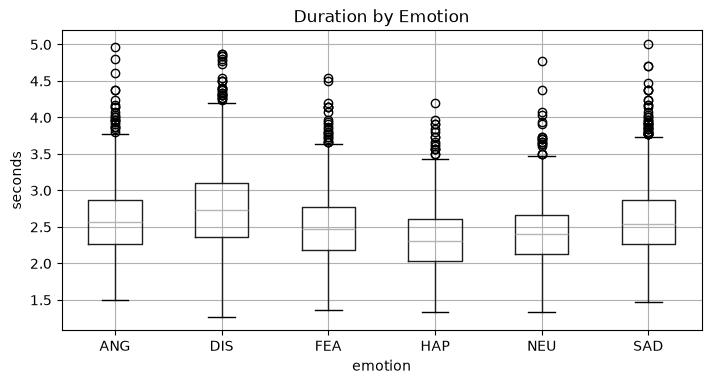

In [117]:
meta.boxplot(column='duration', by='emotion', figsize=(8, 4))
plt.suptitle('')
plt.title('Duration by Emotion')
plt.ylabel('seconds')
plt.show()

Count the audio files per emotion. There are fewer NEUTRAL files: every other emotion was recorded at several intensities, while neutral, for obvious reasons, has only one. A typo was also detected: one SAD file has an intensity `X` that does not exist in the dataset description.

In [118]:
print(meta['emotion'].value_counts().reindex(CLASSES))

emotion
ANG    1271
DIS    1271
FEA    1271
HAP    1271
NEU    1087
SAD    1271
Name: count, dtype: int64


In [119]:
print(pd.crosstab(meta['emotion'], meta['level']).reindex(CLASSES))

level    HI  LO  MD  X    XX
emotion                     
ANG      91  91  91  0   998
DIS      91  91  91  0   998
FEA      91  91  91  0   998
HAP      91  91  91  0   998
NEU       0   0   0  0  1087
SAD      91  91  91  1   997


In [120]:
print(meta.groupby('actor_id').size().describe())

count    91.000000
mean     81.780220
std       1.083228
min      76.000000
25%      82.000000
50%      82.000000
75%      82.000000
max      82.000000
dtype: float64


Defective audio files detected above are excluded. Since none were found, no file is excluded.

In [121]:
excluded = meta[bad_mask]
# excluded_files.csv was written once by A (it is not overwritten here).

meta = meta[~bad_mask].reset_index(drop=True)
print('Excluded:', len(excluded), '| Final Audios:', len(meta))

Excluded: 0 | Final Audios: 7442


## 5. Label construction

The emotion comes from each file name (section 3): `1001_DFA_ANG_XX.wav` → actor `1001`, sentence `DFA`, emotion **`ANG`**, intensity `XX`. Here the labels are validated and the intensity typo found during exploration is fixed. The class order used across the whole project is `U.CLASSES = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']`.

Check that no audio file was loaded twice, that there are no emotions outside the 6 classes, and the number of actors.

In [122]:
CLASSES = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]

assert meta['sample_id'].is_unique, 'Sample_id duplicated.'
assert meta['emotion'].isin(CLASSES).all(), 'Emotions out of the 6 classes.'
print('Audios:', len(meta), '| Actors:', meta['actor_id'].nunique())  # esperado: 91 actores

Audios: 7442 | Actors: 91


The file with the typo is identified and `X` is replaced by `XX` in the metadata; the file name itself is not changed.

In [123]:
print(meta.loc[meta['level'] == 'X', ['sample_id', 'path']])   # identifica el archivo

meta['level'] = meta['level'].replace({'X': 'XX'})
assert set(meta['level']) == {'LO', 'MD', 'HI', 'XX'}
# metadata.csv was written once by A; the final notebook does not overwrite shared files.

           sample_id                         path
3212  1040_ITH_SAD_X  AudioWAV/1040_ITH_SAD_X.wav


## 6. Train / Validation / Test

The split is done **by actor** (speaker-disjoint), ~70/15/15, stratified by sex, with seed 42.

First, the actors are assigned to each subset.

In [124]:
SEED = 42
actors = meta[['actor_id', 'Sex']].drop_duplicates().reset_index(drop=True)

train_act, temp_act = train_test_split(
    actors, test_size=0.30, stratify=actors['Sex'], random_state=SEED)
val_act, test_act = train_test_split(
    temp_act, test_size=0.50, stratify=temp_act['Sex'], random_state=SEED)

Then each audio file inherits the partition of its actor.

In [125]:
split_map = {**{a: 'train' for a in train_act['actor_id']},
             **{a: 'val'   for a in val_act['actor_id']},
             **{a: 'test'  for a in test_act['actor_id']}}
meta['split'] = meta['actor_id'].map(split_map)

assert meta['split'].notna().all(), 'There are audios without partition'
print(meta.groupby('split').agg(audios=('sample_id', 'size'),
                                actors=('actor_id', 'nunique')))

       audios  actors
split                
test     1142      14
train    5152      63
val      1148      14


Check the number of actors in each subset and that the percentages are close to the 70/15/15 required by the assignment. They are not exact because 91 actors cannot be divided exactly.

In [126]:
summary = meta.groupby('split').agg(audios=('sample_id', 'size'),
                                    actors=('actor_id', 'nunique'))
summary = summary.reindex(['train', 'val', 'test'])
summary['% audios'] = (100 * summary['audios'] / summary['audios'].sum()).round(2)
summary

,audios,actors,% audios
split,,,
train,5152,63,69.23
val,1148,14,15.43
test,1142,14,15.35


The emotion percentages are almost identical in every subset: the five non-neutral emotions have exactly the same count within each partition, so the missing files seem to be whole sentences missing across all emotions, not isolated emotions. Therefore they do not unbalance the classes.

In [127]:
SPLITS = ['train', 'val', 'test']
emo = pd.crosstab(meta['emotion'], meta['split']).reindex(index=CLASSES, columns=SPLITS)
emo_pct = (100 * emo / emo.sum()).round(2)
display(emo)

split,train,val,test
emotion,,,
ANG,880,196,195
DIS,880,196,195
FEA,880,196,195
HAP,880,196,195
NEU,752,168,167
SAD,880,196,195


In [128]:
display(emo_pct)

split,train,val,test
emotion,,,
ANG,17.08,17.07,17.08
DIS,17.08,17.07,17.08
FEA,17.08,17.07,17.08
HAP,17.08,17.07,17.08
NEU,14.60,14.63,14.62
SAD,17.08,17.07,17.08


In [129]:
actor_tab = meta.drop_duplicates('actor_id')
display(pd.crosstab(actor_tab['Sex'], actor_tab['split'])[SPLITS])

split,train,val,test
Sex,,,
Female,30,6,7
Male,33,8,7


The plot shows that the split is stratified: every subset has the same proportion of audio files per emotion.

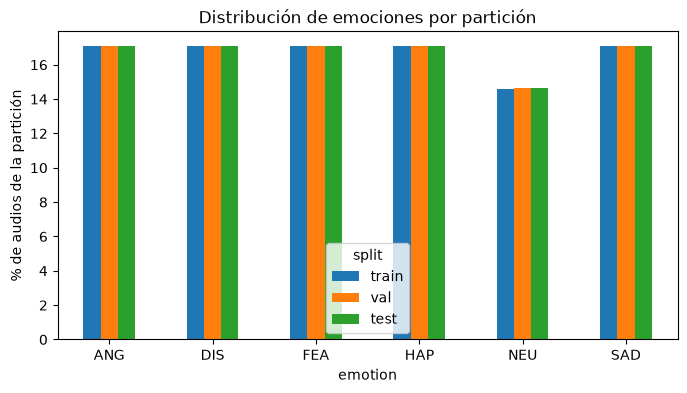

In [130]:
ax = emo_pct.plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_ylabel('% de audios de la partición')
ax.set_title('Distribución de emociones por partición')
plt.show()

The official split (`splits/splits.csv`) was written by Steve **only once**, and every model uses it. Here it is **regenerated** with the same code and the same seed and **compared** with the official file, without overwriting it: this shows that the partition is reproducible and avoids altering the file the whole group depends on.

In [131]:
cols = ['sample_id', 'path', 'actor_id', 'emotion', 'split']

# The official split is never overwritten: it is regenerated above and compared here.
official_split = pd.read_csv(PROJECT / 'splits' / 'splits.csv')
assert official_split.equals(meta[cols].reset_index(drop=True)), 'El split regenerado no coincide con el oficial'
print('El split regenerado coincide exactamente con splits/splits.csv:', official_split.shape)

El split regenerado coincide exactamente con splits/splits.csv: (7442, 5)


This hash only changes if `splits.csv` is modified. It guarantees that nobody changes the partition of any audio file, which would cause data leakage.

In [132]:
print(hashlib.md5((PROJECT / 'splits' / 'splits.csv').read_bytes()).hexdigest())

1dc42b05f19ea3059a3f9a4bf01ebc97


## 7. Speaker-disjoint verification

Check that no actor appears in more than one subset.

In [133]:
act = {s: set(meta.loc[meta['split'] == s, 'actor_id']) for s in ['train', 'val', 'test']}

print('Actors(train) ∩ Actors(val)  =', act['train'] & act['val'])
print('Actors(train) ∩ Actors(test) =', act['train'] & act['test'])
print('Actors(val)   ∩ Actors(test) =', act['val'] & act['test'])

assert not (act['train'] & act['val'] or act['train'] & act['test'] or act['val'] & act['test'])
assert len(act['train'] | act['val'] | act['test']) == 91, 'Some actor missing'

Actors(train) ∩ Actors(val)  = set()
Actors(train) ∩ Actors(test) = set()
Actors(val)   ∩ Actors(test) = set()


Check that `splits.csv` has not been altered.

In [134]:
print('Set Hash:', U.SPLITS_MD5)
print('File Hash', U.file_md5(U.SPLITS_PATH))

Set Hash: 1dc42b05f19ea3059a3f9a4bf01ebc97
File Hash 1dc42b05f19ea3059a3f9a4bf01ebc97


## 8. Audio preprocessing and representations
### Part A: MFCCs, eGeMAPS, and silence trimming

This section explains how the audio signal is transformed into the representations used by models M1 (MFCC) and M2 (eGeMAPS), and documents the **common preprocessing** step for both: silence trimming.

The visualizations always use the **same actor (1001) and the same sentence (DFA)**, so the only thing that changes between examples is the emotion.

In [135]:
# From here on every model uses the official split (its MD5 hash is checked on load).
sp = splits = U.load_splits()
sp.groupby('split').size()

split
test     1142
train    5152
val      1148
dtype: int64

### What information does the voice contains?

The emotion is reflected in the voic through three types of cues:

- **Prosody:** pitch (fundamental frequency, F0), energy or volume, and speech rate.
- **Voice quality:** whether the voice sounds tense, breathy, or shaky.
- **Spectral distribution:** how energy is distributed between low and high frequencies.




### 8.2 Spectograms

The spectogram is a frequency-by-time matrix. Energy is expressed in decibels because the ear perceives volume logarithmically, and voice energy spans a vast range.

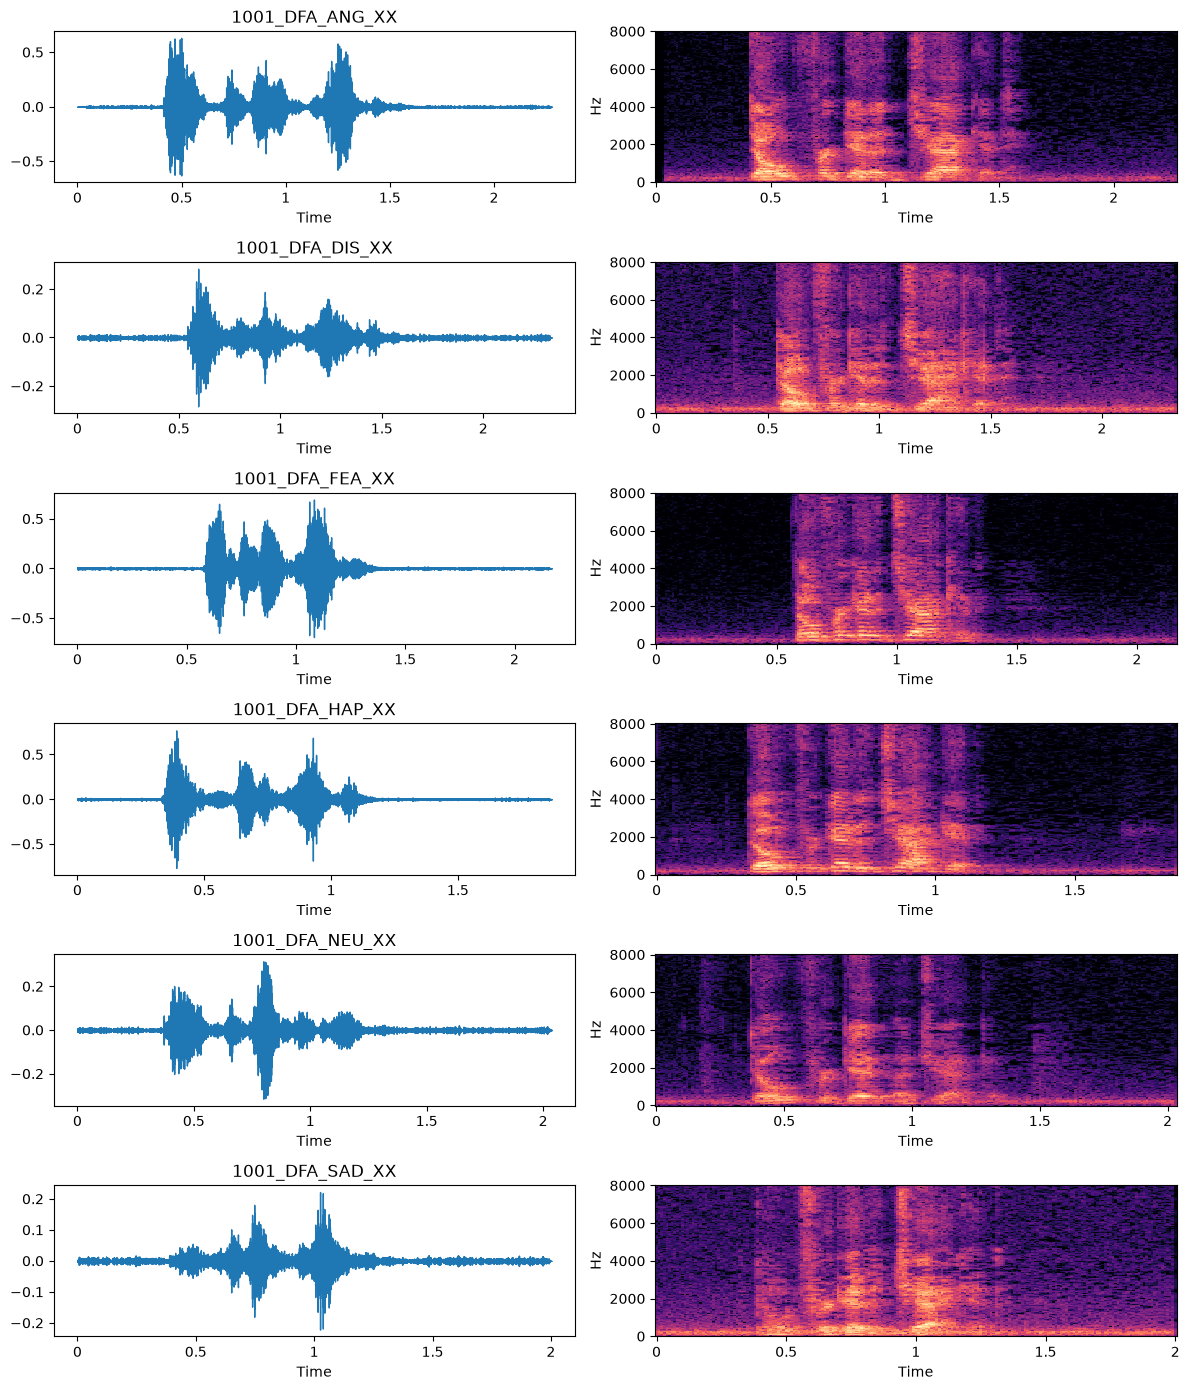

In [136]:
ids = [f'1001_DFA_{e}_XX' for e in U.CLASSES]
fig, axes = plt.subplots(6, 2, figsize=(12, 14))
for row, sid in enumerate(ids):
    y, sr = librosa.load(DATA_ROOT / 'AudioWAV' / f'{sid}.wav', sr=U.SR)
    librosa.display.waveshow(y, sr=sr, ax=axes[row, 0]); axes[row, 0].set_title(sid)
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=512, hop_length=160, win_length=400)), ref=np.max)
    librosa.display.specshow(S, sr=sr, hop_length=160, x_axis='time', y_axis='hz', ax=axes[row, 1])
plt.tight_layout(); plt.show()

In the zones with voice, we can see horizontal parallel horizontal bands: the distance among them is the fundamental frecuency (pitch tone). High-arousal emotions show greater wave amplitude and energy that reaches higher frequencies with greater intensity.

### 8.3 Mel scale and Log-Mel

As humans, we easily distinguish a 100 Hz sound from a 200 Hz one, yet we can barely tell the difference between a 5,000 Hz sound and a 5,100 Hz one, even though the difference is the same. This is because our perception of pitch is nearly linear below 1,000 Hz and logarithmic above it. The Mel scale models this perception:

$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

In practice, the conversion is performed using a bank of triangular filters. The result compresses the information (reducing 257 bands to 64) and makes it perceptually relevant by preserving detail where the ear actually perceives it.
A logarithm is applied to the energy of each filter (Log-Mel) for two reasons: perceptual, because the ear perceives volume logarithmically; and mathematical, because the logarithm converts multiplication into addition.

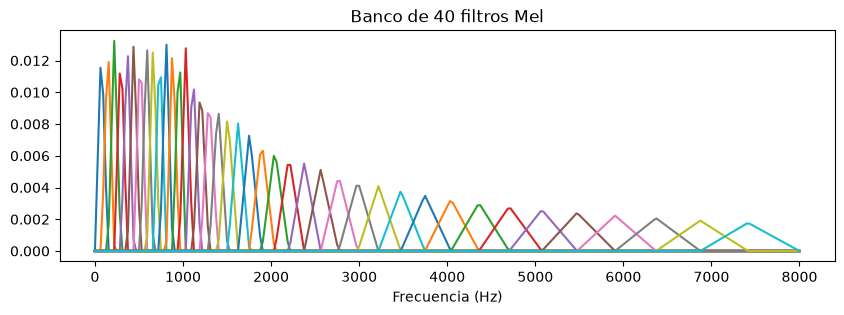

In [137]:
fb = librosa.filters.mel(sr=U.SR, n_fft=512, n_mels=40)
freqs = np.linspace(0, U.SR / 2, fb.shape[1])

plt.figure(figsize=(10, 3))
plt.plot(freqs, fb.T)
plt.xlabel('Frecuencia (Hz)')
plt.title('Banco de 40 filtros Mel')
plt.show()

The triangles widen as the frequency increases. A significant side effect is that wide filters average several harmonics together, so the Mel spectrogram begins to lose pitch information. Log-Mel preserves locality.

# MFFC and its deltas

Voice production involves two stages: the source (whose vibration frequency corresponds to the pitch) and the filter, which shapes the sound and determines much of the voice's timbre. MFCCs are obtained by applying the Discrete Cosine Transform.

Low-order coefficients represent slow variations, while high-order coefficients represent rapid variations. Δ (delta) represents the rate of change of each coefficient, and ΔΔ (delta-delta) represents the acceleration.

With 20 MFCCs per window, adding Δ and ΔΔ results in 60 values ​​per window.

The following figure compares the three representations for ANG and SAD. In the MFCC row, c0 is excluded and each coefficient is standardized solely for visualization purposes: c0 has values ​​much higher than the rest, and without removing it, it would dominate the entire color scale.

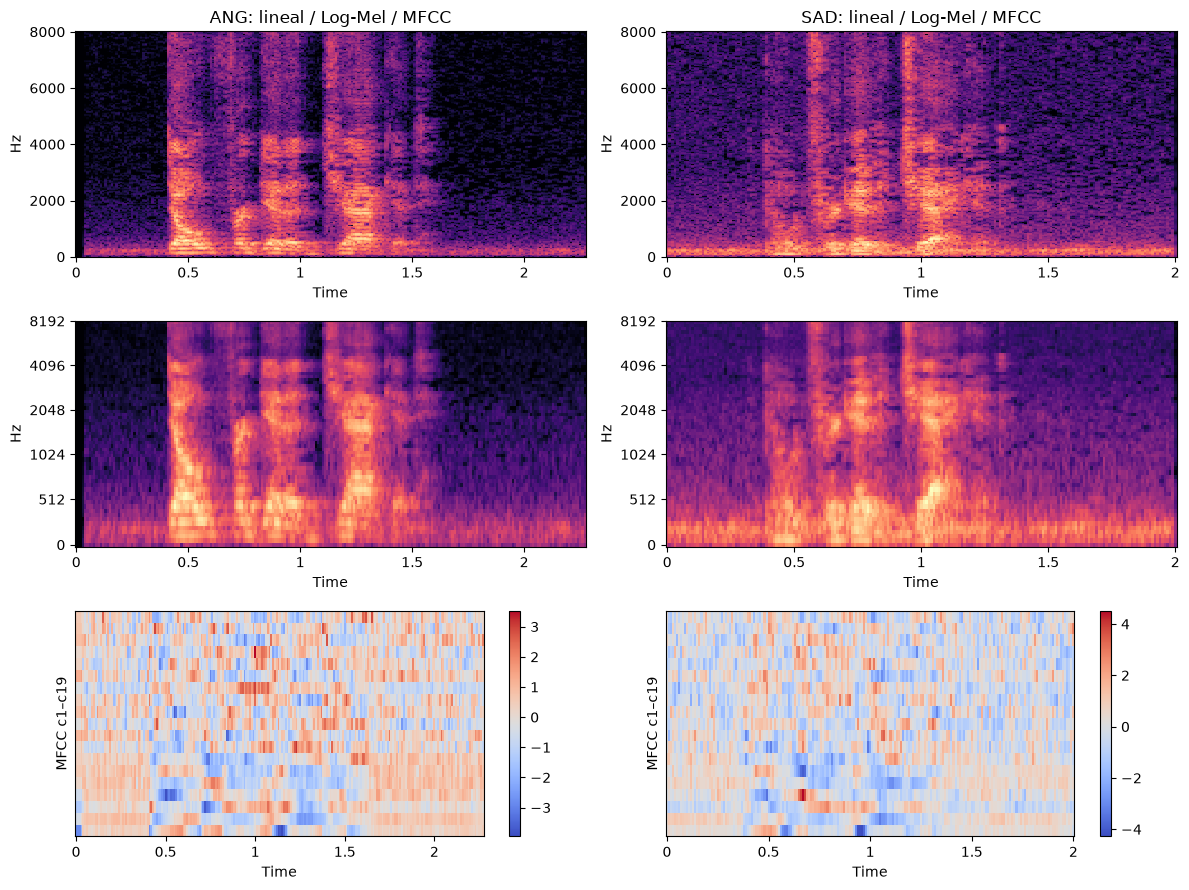

In [138]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for col, emo in enumerate(['ANG', 'SAD']):
    y, sr = librosa.load(DATA_ROOT / 'AudioWAV' / f'1001_DFA_{emo}_XX.wav', sr=U.SR)
    S = np.abs(librosa.stft(y, n_fft=512, hop_length=160, win_length=400)) ** 2
    mel = librosa.feature.melspectrogram(S=S, sr=sr, n_mels=64)
    mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=20)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=160, y_axis='hz', x_axis='time', ax=axes[0, col]); axes[0, col].set_title(f'{emo}: lineal / Log-Mel / MFCC')
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), sr=sr, hop_length=160, y_axis='mel', x_axis='time', ax=axes[1, col])
    vis = mfcc[1:]                                           # sin c0
    vis = (vis - vis.mean(axis=1, keepdims=True)) / (vis.std(axis=1, keepdims=True) + 1e-8)
    img = librosa.display.specshow(vis, sr=sr, hop_length=160, x_axis='time', ax=axes[2, col], cmap='coolwarm'); axes[2, col].set_ylabel('MFCC c1–c19'); fig.colorbar(img, ax=axes[2, col])
plt.tight_layout(); plt.show()

Since c0 was left out of the previous figure, it is graphed separately. Unlike spectrograms, it is not normalized, so it allows the real volume of both audios to be compared.

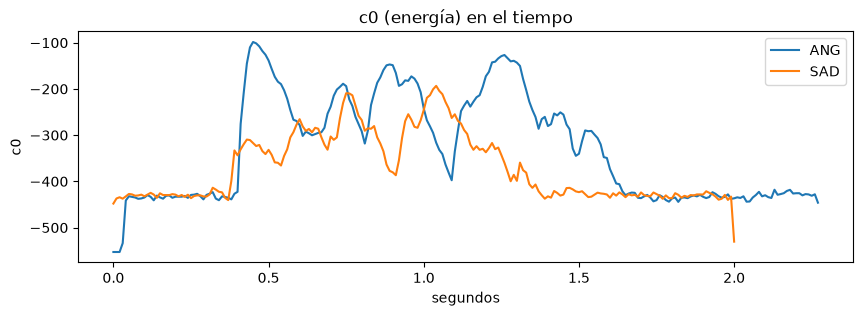

In [139]:
plt.figure(figsize=(10, 3))
for emo in ['ANG', 'SAD']:
    y, sr = librosa.load(DATA_ROOT / 'AudioWAV' / f'1001_DFA_{emo}_XX.wav', sr=U.SR)
    c0 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=512, hop_length=160, win_length=400, n_mels=64)[0]
    plt.plot(librosa.times_like(c0, sr=sr, hop_length=160), c0, label=emo)
plt.xlabel('segundos'); plt.ylabel('c0'); plt.legend(); plt.title('c0 (energía) en el tiempo')
plt.show()

In [140]:
d1 = librosa.feature.delta(mfcc)
d2 = librosa.feature.delta(mfcc, order=2)
print('Media de MFCC c0–c2:', mfcc.mean(axis=1)[:3].round(2))
print('Media de Δ    c0–c2:', d1.mean(axis=1)[:3].round(2))
print('Desv. de Δ    c0–c2:', d1.std(axis=1)[:3].round(2))

Media de MFCC c0–c2: [-369.87   71.55   13.74]
Media de Δ    c0–c2: [-0.15 -0.04 -0.05]
Desv. de Δ    c0–c2: [6.65 4.58 2.14]


**Observations and decision for M1:**

Upon reviewing the AND and SAD spectrograms, we can see that SAD appears to have more background noise than ANG,since ANG displays darker areas—though this may be due to spectrogram normalization.

In ANG, the harmonic bands are sharper, and the energy is more pronounced in both Mel and Log-Mel representations.
Plotting C0 separately reveals numerous silent segments across the audio samples that drop to a value of -430, regardless of the emotion; consequently, it is advisable to trim these silent periods.

Regarding the delta values, the mean is close to zero. This occurs because the delta represents a derivative, and the sum of all derivatives along a signal equals the final value minus the initial value. Since all signals begin and end near zero, the difference is negligible. For this reason, the standard deviation is the feature that provides the most useful information.

Based on these factors, the following feature vector is selected for the initial model:

MFCC: mean and standard deviation of the 20 coefficients → 40 features

Δ: standard deviation only → 20 features

ΔΔ: standard deviation only → 20 features

Summarizing each audio clip using statistics produces a fixed-size vector regardless of duration, so **M1 requires neither padding nor truncation**. The trade-off is the loss of temporal order.

### 8.5 eGeMAPS
eGeMAPS (extended Geneva Minimalistic Acoustic Parameter Set) is a set of 88 descriptors proposed by voice and emotion researchers, selected for their documented relationship with emotions:

- Frequency: F0 pitch in semitones, jitter (cycle-to-cycle pitch irregularity), and F1–F3 formants.
- Energy and amplitude: perceived loudness, shimmer (cycle-to-cycle amplitude irregularity), and harmonics-to-noise ratio (HNR).
- Spectrum: low-to-high frequency balance, spectral slopes, and MFCCs 1–4.
- Temporal: voiced segments per second, duration of voiced and unvoiced segments, and loudness peaks per second.

Each descriptor is summarized using statistics (mean, coefficient of variation, percentiles), thereby producing a fixed-size vector. Descriptors with the suffix "nz" are calculated only on voiced windows.


In [141]:
smile = opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02,
                        feature_level=opensmile.FeatureLevel.Functionals)
feats = pd.concat([smile.process_file(str(DATA_ROOT / 'AudioWAV' / f'1001_DFA_{e}_XX.wav'))
                   for e in ['ANG', 'SAD']])
feats.index = ['ANG', 'SAD']
cols = ['F0semitoneFrom27.5Hz_sma3nz_amean', 'loudness_sma3_amean', 'jitterLocal_sma3nz_amean',
        'shimmerLocaldB_sma3nz_amean', 'HNRdBACF_sma3nz_amean', 'VoicedSegmentsPerSec']
display(feats[cols].T)

,ANG,SAD
F0semitoneFrom27.5Hz_sma3nz_amean,30.205763,22.105423
loudness_sma3_amean,0.583977,0.268916
jitterLocal_sma3nz_amean,0.019515,0.000000
shimmerLocaldB_sma3nz_amean,1.528747,0.000000
HNRdBACF_sma3nz_amean,2.835425,1.564889
VoicedSegmentsPerSec,2.262443,0.515464


**Interpretation:**

There is a clear difference at F0 pitch, where there are semitors away. The volume (loudness) of ANG is more than double that of SAD.
Jitter and simmer in SAD are exactly 0, this means that openSMILE could not calculate them, possibly because SAD has only 0.52 speech segments per second, the low energy speech made it difficult to detect cycles, so 0 is reported.

### 8.6 Trimming silences
#### 8.6.1 The issue with `librosa.effects.trim`

`librosa.effects.trim(y, top_db)` treats any signal level more than `top_db` decibels **below the audio's peak** as silence. To select the threshold, five values ​​are evaluated using a sample of **50 audio clips per emotion from the training set** (preprocessing decisions are based on the training set, not the validation set) according to three metrics:

- `sin_recorte` (no trimming): the proportion of audio clips where almost no trimming occurred. Since virtually all CREMA-D audio clips contain silence at the beginning, a high value indicates that **trimming failed**.
- `muy_corto` (too short): the proportion of audio clips reduced to less than 0.8 seconds. A high value indicates that **speech was trimmed away**.
- `mediana_conservada` (median preserved): the typical fraction of the audio that is retained.

In [142]:
muestra = sp[sp['split'] == 'train'].groupby('emotion').sample(50, random_state=U.SEED)

def cut_summary(tr):
    res = tr.groupby(['param', 'emotion']).agg(
        sin_recorte=('kept', lambda k: (k > 0.98).mean()),
        muy_corto=('kept_s', lambda s: (s < 0.8).mean()),
        mediana_conservada=('kept', 'median'))
    for col in res.columns:
        print(col)
        display(res[col].unstack('emotion').reindex(columns=U.CLASSES).round(2))

rows = []
for _, r in tqdm(muestra.iterrows(), total=len(muestra)):
    y, _ = librosa.load(DATA_ROOT / r['path'], sr=U.SR)
    for db in [15, 18, 20, 25, 30]:
        _, (a, b) = librosa.effects.trim(y, top_db=db)
        rows.append({'emotion': r['emotion'], 'param': db,
                     'kept': (b - a) / len(y), 'kept_s': (b - a) / U.SR})
cut_summary(pd.DataFrame(rows))

100%|██████████| 300/300 [00:00<00:00, 329.62it/s]

sin_recorte


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
15,0.02,0.12,0.16,0.02,0.10,0.44
18,0.02,0.30,0.30,0.10,0.28,0.72
20,0.02,0.46,0.36,0.14,0.58,0.84
25,0.18,0.60,0.54,0.36,0.82,0.98
30,0.36,0.82,0.72,0.72,0.96,1.00


muy_corto


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
15,0.02,0.0,0.04,0.06,0.0,0.02
18,0.00,0.0,0.04,0.04,0.0,0.00
20,0.00,0.0,0.02,0.02,0.0,0.00
25,0.00,0.0,0.00,0.00,0.0,0.00
30,0.00,0.0,0.00,0.00,0.0,0.00


mediana_conservada


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
15,0.56,0.63,0.55,0.55,0.64,0.97
18,0.61,0.70,0.63,0.58,0.94,1.00
20,0.61,0.94,0.67,0.61,0.99,1.00
25,0.69,1.00,0.99,0.95,1.00,1.00
30,0.84,1.00,1.00,1.00,1.00,1.00


The trimming fails in a distinct way depending on the emotion. With `top_db=20`, it does not trim anything in 84% of the SAD audios and in 58% of NEY, but only 2% of ANG. With 15 keeps failing en 44% of SAD and starts trimming in HAP (6%) and FEA (4%). The median preserved with 15 is 0.56 for ANG and 0.97 for SAD. No top_db value treats all emotions equally.

This is caused because the threshold is measured from the peak: for a loud voice, it sits well above the background noise, whereas for a quiet voice, it lies almost right against it. In the SAD audio for actor 1001, the gap between the loudest voice and silence is about 29 dB, so nothing is clipped when using `top_db = 30`.

This failure is more serious than not performing the cropping: if ANG remains "clean" while SAD retains its silence, SAD's averages drop due to a class-dependent preprocessing artifact, and the model could learn this artificial difference. A preprocessing step that fails selectively based on the class is worse than not applying it at all.

#### 8.6.2 Noise floor clipping

What separates speech from silence is not the distance to the peak, but the distance to the noise floor which, in the c0 plot, was the same for both ANG and SAD. The `trim_noise_floor` function estimates the noise floor for each audio clip as the 10th percentile of the window energy (RMS); it classifies any signal exceeding this floor by `margin_db` decibels as speech and retains a buffer of `pad_s` seconds before and after the detected segment.

The method assumes that the audio clips contain some silence at the edges, as is the case with CREMA-D. If no window exceeds the threshold, the function returns the entire audio clip as a safeguard.

In [143]:
MARGIN_DB, PAD_S = 4, 0.15          # parámetros elegidos (ver 8.6.3)

def trim_noise_floor(y, margin_db=MARGIN_DB, pad_s=PAD_S, frame=512, hop=160, sr=U.SR):
    rms = librosa.feature.rms(y=y, frame_length=frame, hop_length=hop)[0]
    db = librosa.amplitude_to_db(rms, ref=1.0, amin=1e-10)
    floor = np.percentile(db, 10)                       # piso de ruido del propio audio
    active = np.flatnonzero(db > floor + margin_db)
    if len(active) == 0:                                # por seguridad: no recortar
        return y, (0, len(y))
    pad = int(pad_s * sr)
    a = max(0, active[0] * hop - frame // 2 - pad)
    b = min(len(y), active[-1] * hop + frame // 2 + pad)
    return y[a:b], (a, b)

In [144]:
rows = []
for _, r in tqdm(muestra.iterrows(), total=len(muestra)):
    y, _ = librosa.load(DATA_ROOT / r['path'], sr=U.SR)
    for m in [4, 6, 10, 15]:
        _, (a, b) = trim_noise_floor(y, margin_db=m)
        rows.append({'emotion': r['emotion'], 'param': m,
                     'kept': (b - a) / len(y), 'kept_s': (b - a) / U.SR})
cut_summary(pd.DataFrame(rows))

100%|██████████| 300/300 [00:00<00:00, 356.64it/s]

sin_recorte


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
4,0.06,0.12,0.1,0.08,0.04,0.08
6,0.00,0.00,0.0,0.00,0.00,0.00
10,0.00,0.00,0.0,0.00,0.00,0.00
15,0.00,0.06,0.1,0.00,0.04,0.28


muy_corto


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
4,0.00,0.00,0.00,0.00,0.00,0.00
6,0.00,0.00,0.02,0.00,0.00,0.02
10,0.00,0.08,0.12,0.00,0.06,0.18
15,0.02,0.14,0.14,0.08,0.16,0.30


mediana_conservada


emotion,ANG,DIS,FEA,HAP,NEU,SAD
param,,,,,,
4,0.86,0.85,0.85,0.83,0.81,0.84
6,0.75,0.69,0.62,0.69,0.72,0.60
10,0.72,0.64,0.59,0.65,0.63,0.47
15,0.67,0.61,0.57,0.61,0.51,0.40


**Noise floor trimming results** (where `param` is the margin in dB).

In the first evaluation, using a 0.05 s time margin, the following results were obtained:

| Margin | `no_trim` | `very_short` | `median_preserved` |
|---|---|---|---|
| 6 dB | 0 for all emotions | 0–6% (max. for FEA and SAD) | 0.53–0.67 |
| 10 dB | 0 for all emotions | up to 30% (SAD) | 0.39–0.64 |
| 15 dB | up to 28% (SAD) | up to 42% (SAD) | 0.32–0.59 |

- **Class-dependent failure disappears:** at 6 and 10 dB, trimming works for all audio samples, including SAD and NEU.
- **The preserved median is consistent across emotions** (0.53–0.67 at 6 dB), unlike with `trim(top_db)` (0.56 for ANG vs. 0.97 for SAD). This is the strongest evidence that the trimming process treats all emotions equally.
- **High margins trim actual speech:** weak syllables in soft speech sit only a few dB above the noise floor and are mistaken for silence.
- **At 15 dB, the `no_trim` rate rises again** because, in very soft voices, no window exceeds the threshold, causing the function to trigger its safety mechanism.

The table in the previous cell corresponds to the final configuration (0.15 s time margin). Since this margin preserves up to 0.3 s of additional audio, the preserved median increases across all emotions, and some audio samples with little silence may be classified as `no_trim`; the key point is that the behavior remains consistent across emotions.

#### Auditory verification and final choice

The metrics detect obvious errors but fail to identify instances where the beginning or end of a word is cut off. In the initial evaluation (using a 6 dB margin and a 0.05 s time margin), seven audio clips shorter than 0.8 s were detected. Upon listening, all of them contained the phrase "It's eleven o'clock"—four at low intensity (LO) and three at medium intensity (MD)—and in each case, either "It's" or "o'clock" had been cut off.


The two possible errors do not carry the same cost: retaining an extra 0.1–0.2 seconds of silence slightly dilutes the averages of all audio clips equally, whereas cutting off speech results in a concentrated loss of information in specific clips. Due to this cost asymmetry, the method was adjusted to favor the "cheaper" error: a 4 dB margin and a 0.15-second temporal margin. With these parameters, all 7 audio clips are heard in their entirety:

In [145]:
CASOS_IEO = ['1066_IEO_DIS_LO', '1006_IEO_FEA_LO', '1061_IEO_FEA_MD', '1024_IEO_FEA_LO',
             '1055_IEO_SAD_LO', '1033_IEO_SAD_MD', '1065_IEO_SAD_MD']
for sid in CASOS_IEO:
    y, _ = librosa.load(DATA_ROOT / 'AudioWAV' / f'{sid}.wav', sr=U.SR)
    y_t, (a, b) = trim_noise_floor(y)
    print(f'{sid}: {len(y) / U.SR:.2f} s → {(b - a) / U.SR:.2f} s')
    display(Audio(y_t, rate=U.SR))

1066_IEO_DIS_LO: 1.90 s → 1.50 s


1006_IEO_FEA_LO: 2.17 s → 2.17 s


1061_IEO_FEA_MD: 2.37 s → 1.55 s


1024_IEO_FEA_LO: 2.27 s → 1.80 s


1055_IEO_SAD_LO: 1.84 s → 1.66 s


1033_IEO_SAD_MD: 2.40 s → 1.49 s


1065_IEO_SAD_MD: 2.20 s → 2.19 s


### 8.7 Summary of M1 and M2 preprocessing

| Decision | M1: MFCC | M2: eGeMAPS |
|---|---|---|
| Sampling rate | 16 kHz, mono | 16 kHz, mono |
| Silence trimming | `trim_noise_floor`: noise floor (10th percentile) + 4 dB, 0.15 s margin | Same |
| Max duration / padding | N/A: fixed-size vector | N/A: fixed-size vector |
| STFT parameters | 25 ms window, 10 ms hop, `n_fft = 512`, 64 Mel filters | openSMILE defaults |
| Features | 80: mean and std dev of 20 MFCCs, std dev of Δ and ΔΔ | 88 eGeMAPSv02 descriptors |
| Normalization | `StandardScaler` fitted only on Train (Section 9) | None: Random Forest does not require it |

Both models use **exactly the same trimming**, so they see the same segment of each audio file. This makes the comparison between them cleaner and ensures that new audio from Section 25 undergoes the same preprocessing as the training data.

### Part B: representations of M3, M4 and M5

The WavLM representation of M3 is documented in section 11, the Log-Mel representation of M4 in section 12.3, and the Whisper representation of M5 in section 13. The representation of M5 (frozen Whisper-small embeddings, averaged over its 13 layers) is documented in section 13.

## 9. Model 1: MFCC + SVM (RBF kernel)

| | |
|---|---|
| **Representation** | 80 MFCC statistics (Section 8.4) |
| **Classifier** | SVM with RBF kernel, within a pipeline using `StandardScaler` |
| **Contribution to the ensemble** | Spectral envelope (timbre) and its dynamics, without explicit pitch information |
| **Cost** | Low; CPU-only |

### 9.1 Feature extraction

The function applies the standard cropping and then calculates the 80 statistics. It is **the same function** that `predict_proba_M1` will use with new audio; if the new audio were processed differently, the model would receive features with a different distribution.

### Common preprocessing: silence trimming


In [146]:
MARGIN_DB, PAD_S = 4, 0.15          # parámetros elegidos en la sección 8.6.3

def trim_noise_floor(y, margin_db=MARGIN_DB, pad_s=PAD_S, frame=512, hop=160, sr=U.SR):
    rms = librosa.feature.rms(y=y, frame_length=frame, hop_length=hop)[0]
    db = librosa.amplitude_to_db(rms, ref=1.0, amin=1e-10)
    floor = np.percentile(db, 10)                       # piso de ruido del propio audio
    active = np.flatnonzero(db > floor + margin_db)
    if len(active) == 0:                                # por seguridad: no recortar
        return y, (0, len(y))
    pad = int(pad_s * sr)
    a = max(0, active[0] * hop - frame // 2 - pad)
    b = min(len(y), active[-1] * hop + frame // 2 + pad)
    return y[a:b], (a, b)

m_tr, m_va = (sp['split'] == 'train').values, (sp['split'] == 'val').values
y_tr, y_va = sp.loc[m_tr, 'emotion'].values, sp.loc[m_va, 'emotion'].values

In [147]:
def extract_mfcc_features(wav_path, margin_db=MARGIN_DB, pad_s=PAD_S):
    y, _ = librosa.load(wav_path, sr=U.SR)
    y, _ = trim_noise_floor(y, margin_db=margin_db, pad_s=pad_s)
    mfcc = librosa.feature.mfcc(y=y, sr=U.SR, n_mfcc=20, n_fft=512,
                                hop_length=160, win_length=400, n_mels=64)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1),
                           d1.std(axis=1), d2.std(axis=1)])

The extraction of the 7,442 audio files is performed **only once** and saved to Drive alongside the `sample_id`s, in the same order as the matrix rows. Extracting features from the test set is permitted because the extraction is a fixed transformation that neither uses labels nor learns anything from the data. What is never done with the test set is **fitting** anything (such as the scaler or the model) or **evaluating**.

In [148]:
FEAT_DIR = U.PROJECT / 'features' / 'M1'
FEAT_DIR.mkdir(parents=True, exist_ok=True)

if not (FEAT_DIR / 'X_mfcc.npy').exists():
    X_all = np.stack([extract_mfcc_features(DATA_ROOT / p) for p in tqdm(sp['path'])])
    np.save(FEAT_DIR / 'X_mfcc.npy', X_all)
    sp[['sample_id']].to_csv(FEAT_DIR / 'sample_ids.csv', index=False)

X_all = np.load(FEAT_DIR / 'X_mfcc.npy')
assert pd.read_csv(FEAT_DIR / 'sample_ids.csv')['sample_id'].equals(sp['sample_id'])
print('Forma:', X_all.shape, '| NaN o infinitos:', (~np.isfinite(X_all)).sum())   # (7442, 80) y 0

config_M1 = {'sr': U.SR, 'trim': 'noise_floor', 'margin_db': MARGIN_DB, 'pad_s': PAD_S,
             'n_mfcc': 20, 'n_mels': 64, 'n_fft': 512, 'win_length': 400, 'hop_length': 160,
             'features': 'media+desv. de 20 MFCC, desv. de delta y delta2 (80)'}
(FEAT_DIR / 'config.json').write_text(json.dumps(config_M1, indent=2))

Forma: (7442, 80) | NaN o infinitos: 0


237

**Consistency check.** The features for five audio samples are recalculated using the current parameters and compared against the cache. If they do not match, it indicates the cache was generated with different parameters and the trained model would not correspond to the inference function. In that case, you must delete `features/M1/`, `models/M1/`, and `results/M1_svm_hyperparams.csv`, re-run this section, and notify the group that `probs_val_M1.csv` has changed.

In [149]:
idx = np.random.default_rng(U.SEED).choice(len(sp), 5, replace=False)
recalc = np.stack([extract_mfcc_features(DATA_ROOT / sp.loc[i, 'path']) for i in idx])
assert np.allclose(recalc, X_all[idx], atol=1e-4), 'La caché no corresponde a los parámetros actuales'
print('Caché de M1 consistente con margin_db =', MARGIN_DB, 'y pad_s =', PAD_S)

Caché de M1 consistente con margin_db = 4 y pad_s = 0.15


### 9.2 Partitions

Only Train and Validation sets are created.

In [150]:
X_tr, X_va = X_all[m_tr], X_all[m_va]
print('Train:', X_tr.shape, '| Validation:', X_va.shape)

Train: (5152, 80) | Validation: (1148, 80)


### 9.3 Hyperparameter search

An SVM seeks the boundary that separates classes with the widest possible margin—that is, the boundary furthest from the examples of each class. The RBF kernel allows the boundary to be curved.

If two audio samples have similar features, their similarity score is close to 1; if they are dissimilar, it is close to 0.

These are the hyperparameters that control the model's behavior:

- GAMMA: With a high gamma value, similarity drops off rapidly with distance, meaning each audio sample influences only its immediate neighborhood.

- C: This represents error tolerance. A high C value drives the model to correctly classify every training example. A low C value accepts some errors in exchange for a simpler boundary.

Scaling is necessary because the RBF kernel relies on Euclidean distances. `StandardScaler()` adjusts each feature to have a mean of 0 and a standard deviation of 1, ensuring they all carry equal weight.

Four values ​​for C, four for GAMMA, and two `class_weight` options will be tested, resulting in a total of 32 combinations.

In [151]:
RES_SVM = U.PROJECT / 'results' / 'M1_svm_hyperparams.csv'

if RES_SVM.exists():
    res_svm = pd.read_csv(RES_SVM, keep_default_na=False)      # resultado ya calculado
else:
    results = []
    for C, gamma, cw in tqdm(list(itertools.product([0.1, 1, 10, 100],['scale',0.001, 0.01, 0.1],[None, 'balanced']))):
      model = make_pipeline(StandardScaler(), SVC(kernel='rbf',C=C, gamma=gamma, class_weight=cw))
      model.fit(X_tr, y_tr)
      val = U.compute_metrics(y_va,model.predict(X_va))
      train_f1 = U.compute_metrics(y_tr, model.predict(X_tr))['macro_f1']
      results.append({'C': C, 'gamma': str(gamma),'class_weight':str(cw),'train_macro_f1':train_f1,'macro_f1':val['macro_f1'], **val})

    res_svm = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(res_svm.head(8).round(4))

,C,gamma,class_weight,train_macro_f1,macro_f1,accuracy,macro_precision,macro_recall,weighted_f1
0,10.0,0.001,None,0.5922,0.5480,0.5540,0.5541,0.5553,0.5481
1,1.0,0.01,None,0.6736,0.5479,0.5549,0.5568,0.5558,0.5487
2,1.0,scale,None,0.7051,0.5473,0.5540,0.5554,0.5547,0.5481
3,1.0,0.01,balanced,0.6709,0.5460,0.5523,0.5578,0.5541,0.5468
4,10.0,0.001,balanced,0.5891,0.5432,0.5488,0.5534,0.5505,0.5439
5,1.0,scale,balanced,0.7049,0.5413,0.5479,0.5530,0.5497,0.5420
6,100.0,0.001,None,0.7258,0.5389,0.5418,0.5430,0.5410,0.5398
7,100.0,0.001,balanced,0.7232,0.5362,0.5392,0.5406,0.5393,0.5370


The first three configurations are tied. Their Macro F1 scores are 0.5480, 0.5479, and 0.5473; the differences amount to mere thousandths. Given that there are only 14 actors in the validation set, this difference represents noise rather than a genuine improvement. Therefore, we must analyze the gap between the training and validation F1 scores:
|Configuration|Train|Val|Gap|
|----|-----|-----|------|
|C=10, γ=0.001|0.592|0.548|0.044|
|C=1, γ=0.01|0.674| 0.548|0.126|
|C=1, γ=scale|0.705|0.547|0.158|

Despite showing the same validation performance, the configuration with C=10 and γ=0.001 is the one that least overfits the training actors. It is the most robust choice: it yields the best Macro F1 score and the smallest gap.

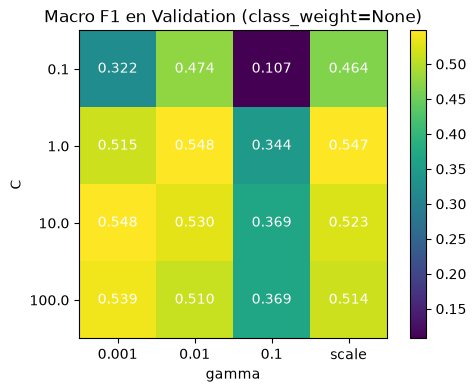

In [152]:
piv = res_svm[res_svm['class_weight'] == 'None'].pivot(index='C', columns='gamma', values='macro_f1')
plt.figure(figsize=(6, 4))
plt.imshow(piv.values, cmap='viridis')
plt.xticks(range(len(piv.columns)), piv.columns); plt.yticks(range(len(piv.index)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        plt.text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center', color='white')
plt.xlabel('gamma'); plt.ylabel('C'); plt.title('Macro F1 en Validation (class_weight=None)'); plt.colorbar(); plt.show()

The heatmap illustrates the two extremes of overfitting.

The row for C=0.1 shows that the model is so constrained that it fails to learn the classes effectively.

The column for GAMMA=0.1 shows that each example influences only its immediate neighborhood; consequently, the model memorizes the training data and generalizes poorly.

There is a stable region with C between 1 and 10 and GAMMA between 0.001 and 0.01, where the Macro F1 score ranges from 0.52 to 0.55.

### 9.4 Final model and validation probabilities

The final model is trained with `probability=True`. SVMs do not natively produce probabilities; scikit-learn estimates them using Platt scaling, fitted via internal cross-validation (which is why `random_state` is set). If the model is already saved, it is loaded and verified to ensure it matches the chosen configuration.

In [153]:
best_svm = {'C': 10, 'gamma': 0.001}
MODEL_DIR = U.PROJECT / 'models' / 'M1'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / 'svm_pipeline.joblib'

if MODEL_PATH.exists():
    model_M1 = joblib.load(MODEL_PATH)
else:
    model_M1 = make_pipeline(StandardScaler(),
                             SVC(kernel='rbf', probability=True, random_state=U.SEED, **best_svm))
    model_M1.fit(X_tr, y_tr)
    joblib.dump(model_M1, MODEL_PATH)

svc = model_M1.named_steps['svc']
assert (svc.C, svc.gamma, svc.probability) == (best_svm['C'], best_svm['gamma'], True)
print('Class Ordering of the model:', model_M1.classes_)

Class Ordering of the model: ['ANG' 'DIS' 'FEA' 'HAP' 'NEU' 'SAD']


Match between predict() and argmax(proba): 0.9469
Mean confidence: 0.521 | Accuracy: 0.562
{'accuracy': 0.5618, 'macro_precision': 0.5609, 'macro_recall': 0.5624, 'macro_f1': 0.5577, 'weighted_f1': 0.5581}


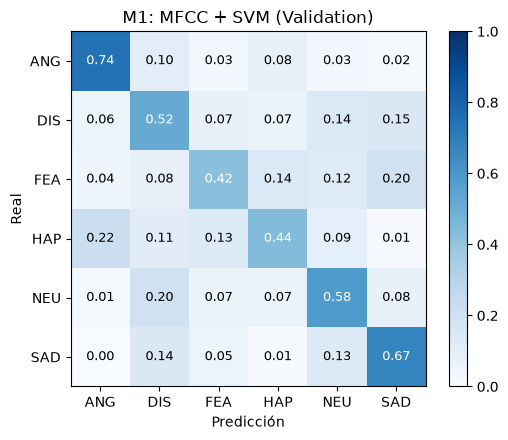

In [154]:
P_va = U.reorder_proba(model_M1.predict_proba(X_va), model_M1.classes_)
pred_va = U.idx_to_labels(P_va.argmax(axis=1))

print('Match between predict() and argmax(proba):', (pred_va == model_M1.predict(X_va)).mean().round(4))
print('Mean confidence:', P_va.max(axis=1).mean().round(3), '| Accuracy:', (pred_va == y_va).mean().round(3))

m1_metrics = U.metrics_from_probs(y_va, P_va)
print({k: round(v, 4) for k, v in m1_metrics.items()})
U.plot_confusion_matrix(y_va, pred_va, 'M1: MFCC + SVM (Validation)'); plt.show()

**M1 Validation Results: Macro F1 = 0.558, accuracy = 0.562**, clearly exceeding the human baseline of around 41% when listening to audio alone.

**Probabilities vs. `predict()`.** They match for 94.7% of the audio samples. The discrepancy arises because `predict()` votes between class pairs based on distances to decision boundaries, whereas `predict_proba()` employs Platt scaling. Since the ensemble operates on probabilities, **all M1 metrics are calculated using `argmax(proba)`**.

**Calibration.** Mean confidence (0.521) is slightly **lower** than accuracy (0.562), meaning M1 is slightly **under-confident**. That effect is significant only when the model memorizes specific speakers, and the chosen configuration is precisely the one with the smallest gap. For the ensemble, this implies that M1 will not dominate uniform Soft Voting.

**Confusion matrix:**

- **Arousal is well-separated:** ANG is rarely confused with SAD (0.02 and 0.00). MFCCs effectively capture energy (c0) and spectral tilt (c1), which serve as cues for arousal.
- **High arousal (ANG, HAP, and—to some extent—FEA):** the primary error is HAP → ANG (0.22). M1 struggles to distinguish valence between two intense emotions. The reverse confusion is much lower (ANG → HAP, 0.08), indicating that anger has a more recognizable spectral profile. - **Low-activation states (NEU, SAD, and DIS):** These are confused with one another in both directions (NEU → DIS 0.20, DIS → SAD 0.15, SAD → DIS 0.14, SAD → NEU 0.13).
- **FEA is the most difficult class (0.42)**, with errors distributed across SAD, HAP, and NEU: fear can be expressed through tension and high pitch, or through a restrained, trembling voice.

### 9.5 Saving

In [155]:
U.save_probs(sp.loc[m_va, 'sample_id'], y_va, P_va, 'M1', 'val')

MODEL_DIR = U.PROJECT / 'models' / 'M1'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
# (the model is saved once in 9.4; re-dumping it here could rewrite it with another sklearn version)
(MODEL_DIR / 'val_metrics.json').write_text(json.dumps(m1_metrics, indent=2))
(MODEL_DIR / 'info.json').write_text(json.dumps({**best_svm, 'sklearn': sklearn.__version__}, indent=2))
res_svm.to_csv(U.PROJECT / 'results' / 'M1_svm_hyperparams.csv', index=False)

Guardado c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\probs\val\probs_val_M1.csv  (1148 filas)  acc=0.5618  macro_f1=0.5577


### 9.6 Inference on new audio

In [156]:
_M1_MODEL = None

def predict_proba_M1(wav_path):
    global _M1_MODEL
    if _M1_MODEL is None:                                   # carga el modelo una sola vez
        _M1_MODEL = joblib.load(U.PROJECT / 'models' / 'M1' / 'svm_pipeline.joblib')
    x = extract_mfcc_features(wav_path).reshape(1, -1)      # misma extracción que en Train
    return U.reorder_proba(_M1_MODEL.predict_proba(x), _M1_MODEL.classes_)[0]

The function must reproduce **exactly** the row of `P_va` corresponding to a validation audio. If it did not match, the new audio would be processed differently than the training data.

In [157]:
sid = sp.loc[m_va, 'sample_id'].iloc[0]
p = U.validate_predict_fn(predict_proba_M1, DATA_ROOT / 'AudioWAV' / f'{sid}.wav', 'M1')
print('Coincide con P_va:', np.allclose(p, P_va[0]))

M1 OK -> HAP  ANG=0.30  DIS=0.02  FEA=0.25  HAP=0.42  NEU=0.00  SAD=0.00
Coincide con P_va: True


In [158]:
def generar_probs_test_M1():
    sp_ = U.load_splits()
    m_te = (sp_['split'] == 'test').values
    X_te = np.load(U.PROJECT / 'features' / 'M1' / 'X_mfcc.npy')[m_te]
    model = joblib.load(U.PROJECT / 'models' / 'M1' / 'svm_pipeline.joblib')
    P_te = U.reorder_proba(model.predict_proba(X_te), model.classes_)
    return U.save_probs(sp_.loc[m_te, 'sample_id'], sp_.loc[m_te, 'emotion'], P_te, 'M1', 'test')

## 10. Model 2: eGeMAPS + Random Forest

More than a third of the descriptors are diluted by silence. Furthermore, temporal descriptors are sensitive; for instance, `VoicedSegmentsPerSec` is divided by the total duration, including silence. For these reasons, the most consistent approach is to apply the same cropping used for Model 1; this way, both models process exactly the same segment of each audio file, making the comparison cleaner.

In [159]:
smile = opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02,
                        feature_level=opensmile.FeatureLevel.Functionals)
EGEMAPS_NAMES = smile.feature_names

def extract_egemaps_features(wav_path, margin_db=4, pad_s=0.15):
    y, _ = librosa.load(wav_path, sr=U.SR)
    y, _ = trim_noise_floor(y, margin_db=margin_db, pad_s=pad_s)   # mismo recorte que M1
    return smile.process_signal(y, U.SR).values[0]                 # vector de 88

In [160]:
wav = DATA_ROOT / 'AudioWAV' / '1001_DFA_SAD_XX.wav'
y, _ = librosa.load(wav, sr=U.SR)
comp = pd.DataFrame({'sin_recorte': smile.process_signal(y, U.SR).values[0],
                     'con_recorte': extract_egemaps_features(wav)}, index=EGEMAPS_NAMES)
cols = ['F0semitoneFrom27.5Hz_sma3nz_amean', 'jitterLocal_sma3nz_amean', 'loudness_sma3_amean',
        'VoicedSegmentsPerSec', 'MeanUnvoicedSegmentLength']
display(comp.loc[cols].round(4))

,sin_recorte,con_recorte
F0semitoneFrom27.5Hz_sma3nz_amean,22.1054,22.1054
jitterLocal_sma3nz_amean,0.0000,0.0000
loudness_sma3_amean,0.2689,0.2886
VoicedSegmentsPerSec,0.5155,0.5780
MeanUnvoicedSegmentLength,0.9450,0.8400


The effect of the trimming is as expected: **F0 remains unchanged** because it is calculated only on voiced windows; **average volume increases** because it is no longer averaged with silence; `VoicedSegmentsPerSec` **increases** because the same segments are divided by a shorter duration; and `MeanUnvoicedSegmentLength` **decreases** because the silent sections at the ends are removed.

Even after trimming, the "unvoiced" segments in this audio are very long relative to the total duration. This confirms that, with this sad, soft voice, openSMILE fails to detect voicing in many parts that are actually voiced—a limitation that trimming cannot correct.


The extracted data is saved to a **CSV containing the descriptor names** and the `sample_id` column. The names are necessary to interpret variable importance (10.6), and including the `sample_id` in the same file prevents the rows from becoming misaligned.

In [161]:
FEAT_DIR2 = U.PROJECT / 'features' / 'M2'
FEAT_DIR2.mkdir(parents=True, exist_ok=True)

if not (FEAT_DIR2 / 'egemaps.csv').exists():
    X2 = np.stack([extract_egemaps_features(DATA_ROOT / p) for p in tqdm(sp['path'])])
    df2 = pd.DataFrame(X2, columns=EGEMAPS_NAMES)
    df2.insert(0, 'sample_id', sp['sample_id'].values)
    df2.to_csv(FEAT_DIR2 / 'egemaps.csv', index=False)

df2 = pd.read_csv(FEAT_DIR2 / 'egemaps.csv')
assert df2['sample_id'].equals(sp['sample_id']), 'Filas desalineadas con splits.csv'
feat_cols = list(df2.columns[1:])
assert feat_cols == EGEMAPS_NAMES, 'El orden de los descriptores no coincide con openSMILE'
print('Forma:', df2.shape, '| NaN:', df2.isna().sum().sum())

Forma: (7442, 89) | NaN: 0


In [162]:
config_M2 = {'sr': U.SR, 'trim': 'noise_floor', 'margin_db': 4, 'pad_s': 0.15,
             'feature_set': 'eGeMAPSv02', 'level': 'Functionals', 'n_features': 88,
             'opensmile': opensmile.__version__}
(FEAT_DIR2 / 'config.json').write_text(json.dumps(config_M2, indent=2))

178

**Consistency check**, same as in M1. If it fails, delete features/M2/, models/M2/, and the M2 results, then re-run this section.

In [163]:
recalc2 = np.stack([extract_egemaps_features(DATA_ROOT / sp.loc[i, 'path']) for i in idx])
assert np.allclose(recalc2, df2.loc[idx, feat_cols].values, rtol=1e-4, atol=1e-6), \
    'La caché no corresponde a los parámetros actuales'
print('Caché de M2 consistente con margin_db =', MARGIN_DB, 'y pad_s =', PAD_S)

Caché de M2 consistente con margin_db = 4 y pad_s = 0.15


### 10.2 How often are jitter and shimmer equal to zero?

In section 8.5, the SAD audio from actor 1001 had jitter and shimmer values ​​of exactly 0 because openSMILE failed to measure them. We examine the frequency of this occurrence for each emotion, **using only the Train set**.

In [164]:
zero_cols = ['jitterLocal_sma3nz_amean', 'shimmerLocaldB_sma3nz_amean']
zeros = df2[zero_cols].eq(0).assign(emotion=sp['emotion'].values, split=sp['split'].values)
display(zeros[zeros['split'] == 'train'].groupby('emotion')[zero_cols].mean()
        .reindex(U.CLASSES).round(3))

,jitterLocal_sma3nz_amean,shimmerLocaldB_sma3nz_amean
emotion,,
ANG,0.001,0.000
DIS,0.011,0.008
FEA,0.007,0.007
HAP,0.001,0.001
NEU,0.000,0.000
SAD,0.022,0.018


**The hypothesis is only partially confirmed.** Zero values ​​are **rare**: at most 2.2% in SAD (about 19 out of 880 audio samples in the Train set), 1.1% in DIS, and 0.1% or less in ANG and HAP. The case of actor 1001 was an exception. A pattern does exist, as SAD accounts for the highest proportion; however, **NEU shows 0%**, contradicting the notion that the failure depends on general arousal levels. It appears specific to the vocal characteristics of sadness (soft, breathy, or quavering voice) rather than just any quiet voice. Given the small number of cases, the impact on M2 will be minimal.

### 10.3 Partitions

In [165]:
X2_tr = df2.loc[m_tr, feat_cols].values
X2_va = df2.loc[m_va, feat_cols].values
print('Train:', X2_tr.shape, '| Validation:', X2_va.shape)

Train: (5152, 88) | Validation: (1148, 88)


### 10.4 Hyperparameters search

A Random Forest trains hundreds of distinct trees and averages their probabilities. To ensure the trees are distinct, it introduces randomness in two ways: each tree is trained on a bootstrap sample, and at each split, the tree can only choose from a random subset of features.

Hyperparameters explored: `min_samples_leaf` (minimum number of audio samples per leaf, the primary complexity control), `max_features` (proportion of available features at each split), and `class_weight`. 300 trees are used for the search and 500 for the final model; adding more trees never degrades model performance, it only increases computation time.

There is a key difference in interpretation here. With SVMs, the gap between training and validation performance indicated overfitting. In a Random Forest, this does not imply the same thing: with small leaves, each individual tree classifies its own sample almost perfectly, driving the training Macro F1 close to 1.0, even though the forest generalizes well thanks to averaging. The decisive metric is the validation Macro F1. For the same reason, the OOB score is not used: it is calculated using audio samples that a given tree did not see, but which came from the same actors it *did* see, leading to an overly optimistic estimate.

In [166]:
RES_RF = U.PROJECT / 'results' / 'M2_rf_hyperparams.csv'

if RES_RF.exists():
    res_rf = pd.read_csv(RES_RF, keep_default_na=False)        # resultado ya calculado
else:
    results = []
    grid = list(itertools.product([1, 3, 5, 10], ['sqrt', 0.3, 0.5], [None, 'balanced']))
    for leaf, mf, cw in tqdm(grid):
        rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, max_features=mf,
                                    class_weight=cw, n_jobs=-1, random_state=U.SEED)
        rf.fit(X2_tr, y_tr)
        val = U.compute_metrics(y_va, rf.predict(X2_va))
        train_f1 = U.compute_metrics(y_tr, rf.predict(X2_tr))['macro_f1']
        results.append({'min_samples_leaf': leaf, 'max_features': str(mf), 'class_weight': str(cw),
                        'train_macro_f1': train_f1, **val})
    res_rf = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    res_rf.to_csv(RES_RF, index=False)

display(res_rf.head(8).round(4))

,min_samples_leaf,max_features,class_weight,train_macro_f1,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,0.5,None,0.9996,0.5523,0.5630,0.5550,0.5446,0.5449
1,3,0.5,None,0.9895,0.5514,0.5592,0.5544,0.5431,0.5431
2,10,0.5,None,0.8221,0.5514,0.5626,0.5548,0.5426,0.5427
3,5,0.5,balanced,0.9489,0.5505,0.5662,0.5546,0.5425,0.5426
4,1,0.3,balanced,0.9996,0.5479,0.5558,0.5509,0.5403,0.5403
5,5,0.3,balanced,0.9416,0.5488,0.5715,0.5524,0.5388,0.5392
6,1,0.5,balanced,0.9996,0.5444,0.5545,0.5473,0.5361,0.5363
7,5,0.5,None,0.9514,0.5453,0.5615,0.5490,0.5360,0.5357


**Configuration selection.** The top eight configurations yield Macro F1 scores between 0.536 and 0.545; the differences between them are merely noise. There is clear evidence of this: with `max_features = 0.5` and no `class_weight`, the configuration using a leaf size of 5 audio samples performs **worse** than those using sizes of 1 and 10. If `min_samples_leaf` had a genuine effect, the results would shift in a consistent pattern rather than fluctuating up and down.

The top three configurations illustrate the contrast with SVM: the training Macro F1 drops from 0.9996 to 0.8221 when moving from leaf sizes of 1 to 10, yet the validation score remains virtually unchanged (0.5446, 0.5431, 0.5426).

We select **`min_samples_leaf = 10`, `max_features = 0.5`, and no `class_weight`**—the most regularized option among the top-performing configurations. There is also a practical consideration: with single-audio leaves, each tree grows to thousands of nodes, and a forest of 500 such trees consumes a significant amount of Drive storage. With leaf sizes of 10, the model is several times smaller and loads much faster when processing new audio.

**`max_features = 0.5` outperforms the others, while `'sqrt'` does not appear among the top configurations.** With `'sqrt'`, each split is limited to choosing from only about 9 of the 88 features, often excluding the most informative ones. This suggests that the relevant information is concentrated within a small subset of descriptors.

### 10.5 Final model and validation probabilities

In [167]:
best_rf = {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 0.5, 'class_weight': None}
MODEL_DIR2 = U.PROJECT / 'models' / 'M2'
MODEL_DIR2.mkdir(parents=True, exist_ok=True)
MODEL_PATH2 = MODEL_DIR2 / 'rf.joblib'

if MODEL_PATH2.exists():
    model_M2 = joblib.load(MODEL_PATH2)
else:
    model_M2 = RandomForestClassifier(**best_rf, n_jobs=-1, random_state=U.SEED).fit(X2_tr, y_tr)
    joblib.dump(model_M2, MODEL_PATH2, compress=3)

assert all(model_M2.get_params()[k] == v for k, v in best_rf.items())
print('Tamaño del modelo:', round(MODEL_PATH2.stat().st_size / 1e6, 1), 'MB')

Tamaño del modelo: 8.8 MB


Mean Confidence: 0.442 | Accuracy: 0.55


,M2 (Validation)
accuracy,0.5497
macro_precision,0.5642
macro_recall,0.5533
macro_f1,0.5395
weighted_f1,0.5395


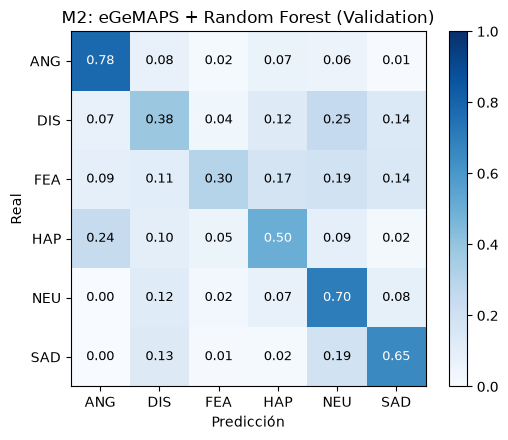

In [168]:
P2_va = U.reorder_proba(model_M2.predict_proba(X2_va), model_M2.classes_)
pred2_va = U.idx_to_labels(P2_va.argmax(axis=1))
print('Mean Confidence:', P2_va.max(axis=1).mean().round(3), '| Accuracy:', (pred2_va == y_va).mean().round(3))

m2_metrics = U.metrics_from_probs(y_va, P2_va)
display(pd.Series(m2_metrics, name='M2 (Validation)').round(4).to_frame())
U.plot_confusion_matrix(y_va, pred2_va, 'M2: eGeMAPS + Random Forest (Validation)')
plt.show()

**M2 Validation results: Macro F1 = 0.540, accuracy = 0.550**, practically on par with M1.

**Calibration.** The average confidence (0.442) is 11 points below the accuracy (0.550): M2 is clearly **under-confident**, almost three times more so than M1. This was to be expected: with leaf nodes containing at least 10 audio samples and an average of 500 trees that do not always agree, the probabilities end up being widely distributed. This does not affect its accuracy, but it does impact Soft Voting: when M1 and M2 disagree, M1’s more pronounced probabilities will tend to prevail. Weighted Soft Voting could compensate for this by assigning more weight to M2.

**Class-by-class comparison with M1 (recall):**

| Emotion | M1 (MFCC + SVM) | M2 (eGeMAPS + RF) |
|---|---|---|
| ANG | 0.74 | **0.78** |
| DIS | **0.52** | 0.38 |
| FEA | **0.42** | 0.30 |
| HAP | 0.44 | **0.50** |
| NEU | 0.58 | **0.70** |
| SAD | 0.67 | 0.65 |

- **Unconfirmed hypotheses:** Pitch was expected to help distinguish HAP from ANG, but M2 confuses them just as M1 does (HAP → ANG: 0.24 vs. 0.22); valence remains difficult to determine with both representations. It was also expected that jitter and pitch would capture the tremor associated with fear, yet M2 performs worse on FEA (0.30), with errors distributed across all classes. - **M2 recognizes NEU much better** (0.70 vs. 0.58): neutral speech is defined by the *absence* of prosodic variation (flat pitch, stable volume), and eGeMAPS measures precisely that variation.
- **M1 recognizes DIS much better** (0.52 vs. 0.38): M2 confuses DIS with NEU in 25% of cases. Disgust appears to be expressed less through prosody and more through articulation, which the spectral envelope of MFCCs captures better.

Each model is strong where the other is weak: there is **complementarity by class**, which is analyzed on an audio-by-audio basis at the end of the notebook.

### 10.6 Saving


In [169]:
U.save_probs(sp.loc[m_va, 'sample_id'], y_va, P2_va, 'M2', 'val')     # valida formato y orden

(MODEL_DIR2 / 'val_metrics.json').write_text(json.dumps(m2_metrics, indent=2))
(MODEL_DIR2 / 'info.json').write_text(json.dumps({**best_rf, 'sklearn': sklearn.__version__,
                                                  'feature_names': feat_cols}, indent=2))

Guardado c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\probs\val\probs_val_M2.csv  (1148 filas)  acc=0.5497  macro_f1=0.5395


3301

### 10.7 What descriptors does the model use?

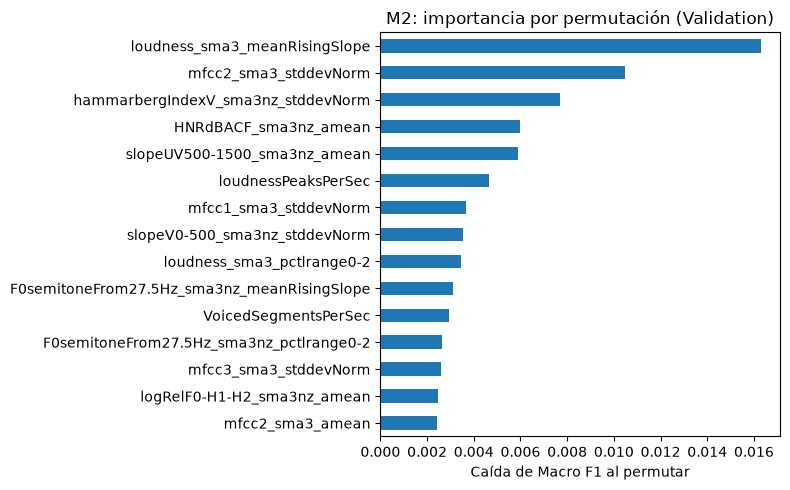

In [170]:
IMP_PATH = U.PROJECT / 'results' / 'M2_permutation_importance.csv'

if IMP_PATH.exists():
    imp = pd.read_csv(IMP_PATH, index_col=0).iloc[:, 0]
else:
    pi = permutation_importance(model_M2, X2_va, y_va, scoring='f1_macro',
                                n_repeats=5, random_state=U.SEED, n_jobs=1)
    imp = pd.Series(pi.importances_mean, index=feat_cols, name='importancia').sort_values(ascending=False)
    imp.to_csv(IMP_PATH)

imp.head(15)[::-1].plot(kind='barh', figsize=(8, 5))
plt.xlabel('Caída de Macro F1 al permutar')
plt.title('M2: importancia por permutación (Validation)')
plt.tight_layout(); plt.show()

In [171]:
def grupo_egemaps(n):
    if n.startswith(('F1', 'F2', 'F3')): return 'Formantes'
    if n.startswith('F0'): return 'Tono (F0)'
    if n.startswith(('jitter', 'shimmer', 'HNR', 'logRelF0')): return 'Calidad de voz'
    if 'Segment' in n or n.endswith('PerSec'): return 'Temporales'
    if n.startswith(('loudness', 'equivalentSoundLevel')): return 'Energía'
    return 'Espectrales'

display(imp.groupby(imp.index.map(grupo_egemaps)).agg(['sum', 'count'])
        .sort_values('sum', ascending=False).round(4))

,sum,count
Tono (F0),0.0060,10
Energía,0.0037,11
Temporales,0.0034,6
Espectrales,0.0024,33
Calidad de voz,-0.0004,10
Formantes,-0.0177,18


**Interpretation.**

Individual importance values ​​are low because many descriptors are correlated and the forest can substitute one for another; therefore, patterns are interpreted rather than exact rankings.

**M2 relies on how the voice changes**, not on absolute levels. Almost all the most important features measure variation: volume and pitch rise slopes, coefficients of variation for spectral descriptors, and volume and pitch ranges. Mean F0 does not appear in the top 15, even though the pitch group is the most important. Absolute levels depend on the speaker (anatomy, sex) and the recording, whereas variations are relative to the individual and serve as the only cues that generalize to the new actors in the Validation set. This also explains why M2 recognizes NEU so well: neutral speech is defined by a lack of variation.

**Rhythm provides information:** temporal descriptors (volume peaks and voiced segments per second) constitute the third most important group, despite comprising only six features.

**Formants hinder generalization:** their total importance is negative (−0.018)—meaning that permuting them actually improves the Macro F1 score. Formants depend on each speaker's vocal tract anatomy; thus, while they aid in recognizing actors from the Train set, they do not transfer to new actors. This is an example of "shortcut learning" revealed by the speaker-disjoint split.

### 10.8 Inference on new audio

The Random Forest was trained using a matrix without column names, so it **cannot detect** if it receives the descriptors in a different order; it would treat volume as pitch without raising an error. Therefore, it is verified that openSMILE produces the 88 descriptors in the same order as the training CSV (as already confirmed in 10.1).

In [172]:
assert EGEMAPS_NAMES == feat_cols, 'El orden de los descriptores no coincide con el entrenamiento'
_M2_MODEL = None

def predict_proba_M2(wav_path):
    global _M2_MODEL
    if _M2_MODEL is None:
        _M2_MODEL = joblib.load(U.PROJECT / 'models' / 'M2' / 'rf.joblib')
    x = extract_egemaps_features(wav_path).reshape(1, -1)
    return U.reorder_proba(_M2_MODEL.predict_proba(x), _M2_MODEL.classes_)[0]

In [173]:
sid = sp.loc[m_va, 'sample_id'].iloc[0]
p = U.validate_predict_fn(predict_proba_M2, DATA_ROOT / 'AudioWAV' / f'{sid}.wav', 'M2')
print('Coincide con P2_va:', np.allclose(p, P2_va[0]))

M2 OK -> ANG  ANG=0.63  DIS=0.07  FEA=0.15  HAP=0.14  NEU=0.00  SAD=0.00
Coincide con P2_va: True


In [174]:
def generar_probs_test_M2():
    sp_ = U.load_splits()
    df_ = pd.read_csv(U.PROJECT / 'features' / 'M2' / 'egemaps.csv')
    assert df_['sample_id'].equals(sp_['sample_id'])
    m_te = (sp_['split'] == 'test').values
    X_te = df_.loc[m_te, df_.columns[1:]].values
    model = joblib.load(U.PROJECT / 'models' / 'M2' / 'rf.joblib')
    P_te = U.reorder_proba(model.predict_proba(X_te), model.classes_)
    return U.save_probs(sp_.loc[m_te, 'sample_id'], sp_.loc[m_te, 'emotion'], P_te, 'M2', 'test')

# NO EJECUTAR hasta la Fase 3:  generar_probs_test_M2()

## 11. Model 3 — WavLM embeddings + Logistic Regression

**Representation.** We use WavLM base-plus, a model pre-trained on about 94,000 hours of speech. We do not train it (it stays frozen): with only about 5,000 training audios, adjusting its ~94 million parameters would make it memorize the training audios instead of learning the emotion. We only train a Logistic Regression on top.

**Preprocessing.**
- Sample rate: 16 kHz (the original rate of CREMA-D).
- Silence trimming with `librosa.effects.trim` (`top_db=18`), so the silence does not dilute the average.
- No padding or truncation: each audio is processed alone, and WavLM accepts any length.
- WavLM produces one vector of 768 values every ~20 ms. We average these vectors over time, so each audio becomes one vector of 768 values per layer.
- Normalization: `StandardScaler`, fitted only on Train (inside a `Pipeline`).

**Choosing the layer.** WavLM has 13 layers (the input plus 12 transformer layers). We trained a Logistic Regression for each layer on Train and measured it on Validation. The lower layers capture raw sound, and the higher layers get closer to the words. The middle layers (5–7) worked best, because they combine the sound into longer patterns, like the melody and energy of the voice, which is where the emotion is. Since all the actors say the same 12 sentences, knowing which words were said does not help. We chose **layer 5** (Macro F1 0.663), although layers 6 and 7 are so close that the difference could be due to chance.

**How the two parts work together.** M3 combines two parts with different roles. WavLM works as a frozen feature extractor: it describes each audio with a vector of 768 values, and it is never trained in this project. The Logistic Regression works as the classifier: it learns one weight for each of the 768 values and each emotion, adds them up into a score per emotion, and converts the six scores into probabilities that sum to 1. Only the scaler and the Logistic Regression are trained (768 × 6 + 6 = 4,614 parameters), while WavLM keeps its ~94 million parameters frozen. This setup (frozen extractor + linear classifier) uses everything WavLM learned about the voice while training only a small part, which is fast and hard to overfit with only about 5,000 training audios.

In [175]:
# Shared configuration comes from section 2; M3 adds WavLM and its classifier.
from math import comb
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from transformers import AutoFeatureExtractor, WavLMModel

DATA_DIR = DATA_ROOT        # folder that contains AudioWAV/ (section 2)

### 11.1 WavLM embeddings (extracted once, cached in `features/M3/`)

In [176]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

extractor = AutoFeatureExtractor.from_pretrained('microsoft/wavlm-base-plus')
wavlm = WavLMModel.from_pretrained('microsoft/wavlm-base-plus').to(device).eval()

row = splits.iloc[0]
y, _ = librosa.load(DATA_DIR / row['path'], sr=U.SR)
inputs = extractor(y, sampling_rate=U.SR, return_tensors='pt').to(device)

with torch.no_grad():                          # we only read the model, we don't train it
    out = wavlm(**inputs, output_hidden_states=True)

print("Number of layers:", len(out.hidden_states))
print("Shape of the last layer:", out.hidden_states[-1].shape)

Device: cuda


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 11260.12it/s]


Number of layers: 13
Shape of the last layer: torch.Size([1, 113, 768])


In [177]:
FEAT_DIR = U.PROJECT / 'features' / 'M3'
FEAT_DIR.mkdir(parents=True, exist_ok=True)

def load_audio_m3(path):
    y, _ = librosa.load(path, sr=U.SR)
    y, _ = librosa.effects.trim(y, top_db=18)
    return y

def wavlm_embedding(y):
    inputs = extractor(y, sampling_rate=U.SR, return_tensors='pt').to(device)
    with torch.no_grad():
        out = wavlm(**inputs, output_hidden_states=True)
    layers = torch.stack(out.hidden_states)[:, 0]        # (13, time, 768)
    return layers.mean(dim=1).cpu().numpy()             # average over time -> (13, 768)

EMB_PATH = FEAT_DIR / 'wavlm_embeddings.npy'

if not EMB_PATH.exists():
    emb = np.zeros((len(splits), 13, 768), dtype=np.float32)
    for i, p in enumerate(tqdm(splits['path'], desc='WavLM embeddings')):
        emb[i] = wavlm_embedding(load_audio_m3(DATA_DIR / p))
    np.save(EMB_PATH, emb)
    splits[['sample_id']].to_csv(FEAT_DIR / 'wavlm_order.csv', index=False)
else:
    print("Embeddings already exist, skipping extraction.")

Embeddings already exist, skipping extraction.


In [178]:
emb = np.load(FEAT_DIR / 'wavlm_embeddings.npy')
order = pd.read_csv(FEAT_DIR / 'wavlm_order.csv')['sample_id']
assert (order.values == splits['sample_id'].values).all(), "Embeddings and splits are not in the same order"

train_mask = (splits['split'] == 'train').values
val_mask = (splits['split'] == 'val').values
y_train = splits.loc[train_mask, 'emotion'].values
y_val = splits.loc[val_mask, 'emotion'].values

### 11.2 Layer and regularization search (Validation only)

Layers: 100%|██████████| 13/13 [01:46<00:00,  8.16s/it]


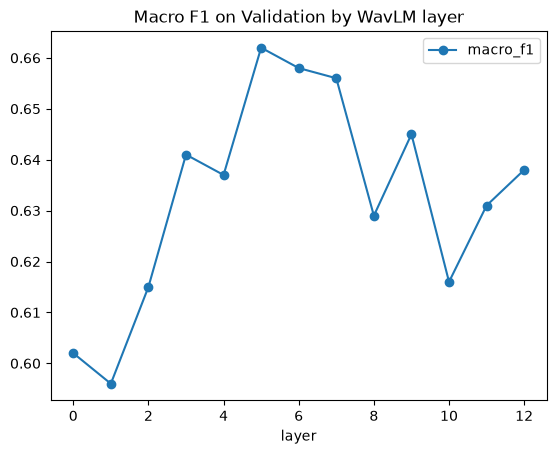

,layer,accuracy,macro_f1
0,0,0.603,0.602
1,1,0.598,0.596
2,2,0.615,0.615
3,3,0.640,0.641
4,4,0.634,0.637
5,5,0.659,0.662
6,6,0.657,0.658
7,7,0.652,0.656
8,8,0.626,0.629
9,9,0.642,0.645


In [179]:
layer_scores = []
for layer in tqdm(range(13), desc='Layers'):
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000)),
    ])
    clf.fit(emb[train_mask, layer], y_train)
    y_pred = clf.predict(emb[val_mask, layer])
    layer_scores.append({'layer': layer, **U.compute_metrics(y_val, y_pred)})

layer_df = pd.DataFrame(layer_scores).round(3)
layer_df.plot(x='layer', y='macro_f1', marker='o', title='Macro F1 on Validation by WavLM layer')
plt.show()
layer_df[['layer', 'accuracy', 'macro_f1']]

In [180]:
LAYER = 5
X_train, X_val = emb[train_mask, LAYER], emb[val_mask, LAYER]

c_scores = []
for C in tqdm([0.001, 0.01, 0.1, 1, 10], desc='C values'):
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=C, max_iter=2000)),
    ])
    clf.fit(X_train, y_train)
    c_scores.append({'C': C, **U.compute_metrics(y_val, clf.predict(X_val))})

pd.DataFrame(c_scores)[['C', 'accuracy', 'macro_f1']].round(3)

C values: 100%|██████████| 5/5 [00:12<00:00,  2.58s/it]


,C,accuracy,macro_f1
0,0.001,0.728,0.728
1,0.010,0.723,0.723
2,0.100,0.700,0.702
3,1.000,0.659,0.662
4,10.000,0.632,0.635


In [181]:
grid_rows = []
for layer in tqdm(range(13), desc='Layers'):
    for C in [0.0001, 0.0003, 0.001, 0.003]:
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(C=C, max_iter=2000)),
        ])
        clf.fit(emb[train_mask, layer], y_train)
        f1 = U.compute_metrics(y_val, clf.predict(emb[val_mask, layer]))['macro_f1']
        grid_rows.append({'layer': layer, 'C': C, 'macro_f1': f1})

grid_df = pd.DataFrame(grid_rows)
grid_df.pivot(index='layer', columns='C', values='macro_f1').round(3)

Layers: 100%|██████████| 13/13 [01:33<00:00,  7.17s/it]


C,0.0001,0.0003,0.0010,0.0030
layer,,,,
0,0.521,0.572,0.603,0.620
1,0.557,0.595,0.617,0.640
2,0.569,0.630,0.659,0.670
3,0.608,0.662,0.692,0.700
4,0.631,0.696,0.738,0.740
5,0.653,0.720,0.728,0.733
6,0.664,0.717,0.741,0.742
7,0.617,0.693,0.721,0.735
8,0.595,0.657,0.710,0.720


In [182]:
extra_rows = []
for layer in tqdm(range(3, 9), desc='Layers'):
    for C in [0.01, 0.03]:
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(C=C, max_iter=2000)),
        ])
        clf.fit(emb[train_mask, layer], y_train)
        f1 = U.compute_metrics(y_val, clf.predict(emb[val_mask, layer]))['macro_f1']
        extra_rows.append({'layer': layer, 'C': C, 'macro_f1': f1})

grid_df = pd.concat([grid_df, pd.DataFrame(extra_rows)])
grid_df[grid_df['layer'].between(3, 8)].pivot(index='layer', columns='C', values='macro_f1').round(3)

Layers: 100%|██████████| 6/6 [01:10<00:00, 11.74s/it]


C,0.0001,0.0003,0.0010,0.0030,0.0100,0.0300
layer,,,,,,
3,0.608,0.662,0.692,0.700,0.694,0.686
4,0.631,0.696,0.738,0.740,0.727,0.709
5,0.653,0.720,0.728,0.733,0.723,0.723
6,0.664,0.717,0.741,0.742,0.735,0.727
7,0.617,0.693,0.721,0.735,0.730,0.721
8,0.595,0.657,0.710,0.720,0.720,0.707


**Regularization (C).** With the default `C=1`, the model was memorizing the training audios: 768 features for only 63 actors is a lot of freedom. A smaller `C` makes the model simpler. We searched layers and `C` together, because the best layer can change with a different `C`. Each time the best value was at the edge of the values tested, we extended the search, until the best value had lower scores on both sides.

We chose **layer 6 with C = 0.003** (Macro F1 0.742 on Validation), the highest score. Layer 4 with `C=0.003` and layer 6 with `C=0.001` got 0.740, practically a tie. Since we tested about 64 combinations on the same 14 validation actors, the selected one may be slightly favored by chance, and we expect a somewhat lower result on Test.

### 11.3 Final model and Validation probabilities

Guardado c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\probs\val\probs_val_M3.csv  (1148 filas)  acc=0.7413  macro_f1=0.7423


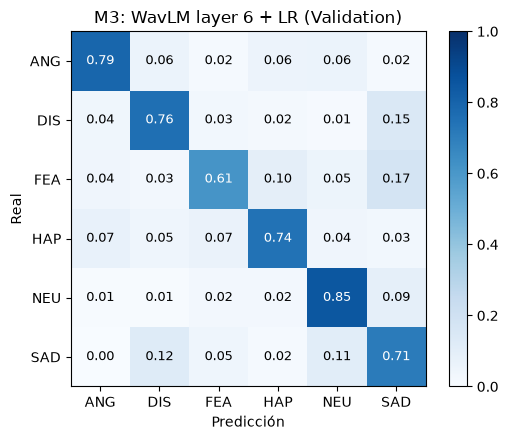

In [183]:
LAYER, BEST_C = 6, 0.003

M3_MODEL_PATH = U.PROJECT / 'models' / 'M3' / 'm3.joblib'
if M3_MODEL_PATH.exists():
    # Trained once already: reuse it, so re-running the notebook never changes M3.
    m3 = joblib.load(M3_MODEL_PATH)['pipeline']
    assert m3.named_steps['model'].C == BEST_C, 'Saved M3 does not match the chosen C'
else:
    m3 = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=BEST_C, max_iter=2000)),
    ])
    m3.fit(emb[train_mask, LAYER], y_train)

X_val = emb[val_mask, LAYER]
probs_val = U.reorder_proba(m3.predict_proba(X_val), m3.classes_)
U.save_probs(splits.loc[val_mask, 'sample_id'].values, y_val, probs_val,
             'M3', 'val', splits_df=splits)

U.plot_confusion_matrix(y_val, m3.predict(X_val), title='M3: WavLM layer 6 + LR (Validation)')
plt.show()

In [184]:
MODEL_DIR = U.PROJECT / 'models' / 'M3'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not M3_MODEL_PATH.exists():          # saved only the first time
    joblib.dump({
        'pipeline': m3,
        'layer': LAYER,
        'top_db': 18,
        'sr': U.SR,
        'wavlm_name': 'microsoft/wavlm-base-plus',
    }, MODEL_DIR / 'm3.joblib')

### 11.4 Inference on a single audio: `predict_proba_M3`

In [185]:
_m3 = None   # cache: load the models only the first time

def predict_proba_M3(wav_path):
    global _m3
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    if _m3 is None:
        art = joblib.load(U.PROJECT / 'models' / 'M3' / 'm3.joblib')
        art['extractor'] = AutoFeatureExtractor.from_pretrained(art['wavlm_name'])
        art['wavlm'] = WavLMModel.from_pretrained(art['wavlm_name']).to(dev).eval()
        _m3 = art

    y, _ = librosa.load(wav_path, sr=_m3['sr'])               # any sample rate, stereo -> mono
    y, _ = librosa.effects.trim(y, top_db=_m3['top_db'])
    inputs = _m3['extractor'](y, sampling_rate=_m3['sr'], return_tensors='pt').to(dev)
    with torch.no_grad():
        out = _m3['wavlm'](**inputs, output_hidden_states=True)
    x = out.hidden_states[_m3['layer']][0].mean(dim=0).cpu().numpy().reshape(1, -1)
    proba = _m3['pipeline'].predict_proba(x)
    return U.reorder_proba(proba, _m3['pipeline'].classes_)[0]

In [186]:
row = splits[val_mask].iloc[0]
p_fn = U.validate_predict_fn(predict_proba_M3, DATA_DIR / row['path'], 'M3')
p_csv = U.load_probs('M3', 'val').set_index('sample_id').loc[row['sample_id'], U.PROB_COLS].values
print("Max difference:", np.abs(p_fn - p_csv).max())

Loading weights: 100%|██████████| 248/248 [00:00<?, ?it/s]


M3 OK -> ANG  ANG=0.89  DIS=0.01  FEA=0.05  HAP=0.05  NEU=0.00  SAD=0.00
Max difference: 6.923115433710159e-05


### 11.5 Test probabilities: `generar_probs_test_M3()` — **DO NOT RUN YET**

In [187]:
def generar_probs_test_M3():
    splits_df = U.load_splits()
    test_mask = (splits_df['split'] == 'test').values
    emb = np.load(U.PROJECT / 'features' / 'M3' / 'wavlm_embeddings.npy')
    order = pd.read_csv(U.PROJECT / 'features' / 'M3' / 'wavlm_order.csv')['sample_id']
    assert (order.values == splits_df['sample_id'].values).all()

    art = joblib.load(U.PROJECT / 'models' / 'M3' / 'm3.joblib')
    X_test = emb[test_mask, art['layer']]
    probs = U.reorder_proba(art['pipeline'].predict_proba(X_test), art['pipeline'].classes_)
    return U.save_probs(splits_df.loc[test_mask, 'sample_id'].values,
                        splits_df.loc[test_mask, 'emotion'].values,
                        probs, 'M3', 'test', splits_df=splits_df)

# DO NOT RUN until results/frozen_config.json exists (Phase 3)

### 11.6 Discussion of M3

**Results on Validation:** accuracy 0.741, Macro F1 0.742.

**Strengths.** M3 recognizes *neutral* very well (recall 0.85), together with *angry* (0.79) and *disgust* (0.76). *Angry* is usually louder and higher-pitched, which is easy to detect. A possible explanation for *neutral* is that a neutral voice is stable, without sudden changes, and this absence of change is also a pattern that WavLM can recognize. In general, the model does not perform badly in any emotion.

**Weaknesses.** The hardest emotion is *fear* (recall 0.61), which is often confused with *sad* (0.17), possibly because both can have a soft and trembling voice. The same confusion appeared in a previous project with MFCC features, which suggests these audios are difficult in general and not only for this model. There is also confusion among the low-energy emotions: *disgust* → *sad* (0.15), *sad* → *disgust* (0.12) and *sad* → *neutral* (0.11).

**Practical advantage.** WavLM already learned from about 94,000 hours of speech, so its layers give useful information about the voice even with few training audios.

**Practical disadvantage.** WavLM has about 94 million parameters (~378 MB). It needs a GPU or it is slow on CPU, and every new audio must pass through the whole model before the Logistic Regression can predict.

## 12. Model 4 — CNN on Log-Mel spectrograms
**Author:** Person C · **Group task:** Ensemble + Weighted Soft Voting

Summary of model M4:

| Item | Choice |
|---|---|
| Representation | Log-Mel spectrogram (16 kHz, 3 s fixed, 64 mel bands) |
| Model | 2-D CNN trained **from scratch** (4 conv blocks, SpecAugment) |
| Family | 2-D spectrograms (the only family not covered by M1, M2, M3, M5) |
| Hardware | Colab GPU (T4) |

**Deliverables (group contract):**
1. `probs/val/probs_val_M4.csv` — probabilities on Validation, columns in the order `ANG, DIS, FEA, HAP, NEU, SAD`.
2. `predict_proba_M4(wav_path)` — returns a `(6,)` array for any `.wav`.
3. `generar_probs_test_M4()` — written but **NOT executed** until the ensemble is frozen.
4. Documentation: representation, preprocessing, training, validation metrics and confusion matrix.

**Methodological rules followed here**
- Only the official `splits.csv` is used (checked by MD5 inside `utils.load_splits`).
- The model is trained **only on Train**. Normalization statistics are computed **only on Train**.
- Validation is used only for early stopping / best checkpoint / temperature scaling.
- **Test is never touched** in this section.

### 12.1 Configuration

In [188]:
import os, sys, json, time, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from joblib import Parallel, delayed
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore", category=UserWarning)

In [189]:
# Shared configuration (paths, utils, seed) comes from section 2; M4 only needs its device.
# M4 uses its own names (M4_DEVICE, M4_MODEL_DIR, M4_FEAT_DIR, M4_NAME) so that later sections,
# which redefine DEVICE / MODEL_DIR / FEAT_DIR, cannot change what predict_proba_M4 loads.
M4_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", M4_DEVICE, "| torch", torch.__version__)

Device: cuda | torch 2.11.0+cu128


In [190]:
M4_NAME = "M4"

# ---- Audio / representation parameters (documented in 12.3) ----
SR          = U.SR                   # 16 kHz (group contract)
DURATION    = 3.0                    # seconds, fixed length
N_SAMPLES   = int(SR * DURATION)     # 48 000 samples
N_FFT       = 512                    # 32 ms window
HOP         = 160                    # 10 ms hop
N_MELS      = 64
FMIN, FMAX  = 20, 8000
TOP_DB      = 80                     # dynamic range kept in the log-Mel
N_FRAMES    = N_SAMPLES // HOP + 1   # 301 frames (librosa center=True)

# ---- Training hyper-parameters ----
BATCH_SIZE      = 64
MAX_EPOCHS      = 80
PATIENCE        = 12        # early stopping (epochs without improvement in val macro-F1)
LR              = 1e-3
WEIGHT_DECAY    = 1e-2
LABEL_SMOOTHING = 0.1
DROPOUT         = 0.3
CHANNELS        = (16, 32, 64, 128)

# Temperature scaling fitted on Validation (see 12.9). Tell the group if you change it.
USE_TEMPERATURE_SCALING = True

# ---- Folders ----
M4_FEAT_DIR    = PROJECT / "features" / M4_NAME
M4_MODEL_DIR   = PROJECT / "models" / M4_NAME
RESULTS_DIR = PROJECT / "results"
for d in (M4_FEAT_DIR, M4_MODEL_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

FEATURE_CFG = dict(sr=SR, duration=DURATION, n_fft=N_FFT, hop=HOP, n_mels=N_MELS,
                   fmin=FMIN, fmax=FMAX, top_db=TOP_DB)
print("Feature config:", FEATURE_CFG)

Feature config: {'sr': 16000, 'duration': 3.0, 'n_fft': 512, 'hop': 160, 'n_mels': 64, 'fmin': 20, 'fmax': 8000, 'top_db': 80}


### 12.2 Audio paths

The `path` column of `splits.csv` is **relative** (`AudioWAV/xxx.wav`); it is resolved against `DATA_ROOT` from section 2, which is the local disk in Colab and `CREMA-D_Grupo/data` when running locally. The split itself was already loaded and checked (MD5 and speaker-disjoint) in sections 6–8.

In [191]:
WAV_ROOT = DATA_ROOT            # folder that contains AudioWAV/ (section 2)

splits["abs_path"] = splits["path"].apply(lambda p: str(WAV_ROOT / p))
missing = [p for p in splits["abs_path"] if not os.path.exists(p)]
assert not missing, f"{len(missing)} audio files not found, e.g. {missing[:3]}"
print(f"All {len(splits)} audio files found under {WAV_ROOT}")

All 7442 audio files found under c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\data


### 12.3 Audio representation: Log-Mel spectrogram

**Why a spectrogram?** A spectrogram shows how the energy of the signal is distributed over *frequency* (vertical axis)
and *time* (horizontal axis). Emotions change pitch, energy and spectral shape over time, so a 2-D CNN can learn local
time-frequency patterns the same way it learns edges in images. This is a **different view** from M1/M2
(hand-crafted statistics per clip) and M3/M5 (pretrained embeddings), which should make M4's errors different.

| Item | Value |
|---|---|
| Sampling rate | 16 000 Hz (resampled if needed), mono |
| Fixed duration | 3 s = 48 000 samples (CREMA-D: median ≈ 2.5 s, max ≈ 5 s) |
| Padding / truncation | Shorter clips: zero-padding at the end. Longer clips: **centered crop** |
| Amplitude normalization | Peak normalization per clip (removes volume differences) |
| STFT | `n_fft=512` (32 ms), `hop=160` (10 ms) |
| Mel filterbank | 64 bands, 20–8000 Hz |
| Log scale | `10·log10(power)` in dB, dynamic range limited to 80 dB |
| Feature normalization | Per-mel-band mean/std **computed on Train only** |
| Final shape per clip | `(1, 64, 301)` = (channel, mel bands, time frames) |
| Augmentation (Train only) | SpecAugment (2 frequency masks, 2 time masks), random time shift, light Gaussian noise |

> Important: **the same function** builds the features for training, for Validation/Test and for a new audio,
> so there is no train/inference mismatch.

In [192]:
def fix_length(y: np.ndarray) -> np.ndarray:
    # Peak-normalize, then crop (centered) or zero-pad to exactly N_SAMPLES samples.
    peak = float(np.max(np.abs(y))) if y.size else 0.0
    if peak > 1e-6:                      # avoid dividing by ~0 for silent files
        y = y / peak
    if len(y) >= N_SAMPLES:
        start = (len(y) - N_SAMPLES) // 2
        y = y[start:start + N_SAMPLES]
    else:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    return y.astype(np.float32)


def waveform_to_logmel(y: np.ndarray) -> np.ndarray:
    # Fixed-length waveform -> log-Mel spectrogram of shape (N_MELS, N_FRAMES), in dB.
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
    return librosa.power_to_db(S, ref=1.0, top_db=TOP_DB).astype(np.float32)


def wav_to_logmel(path) -> np.ndarray:
    # Full pipeline for one file: load (mono, 16 kHz) -> fix length -> log-Mel.
    y, _ = librosa.load(str(path), sr=SR, mono=True)
    return waveform_to_logmel(fix_length(y))


# Sanity check on one real file
_x = wav_to_logmel(splits.loc[0, "abs_path"])
print("Log-Mel shape:", _x.shape, "(expected", (N_MELS, N_FRAMES), ")")
assert _x.shape == (N_MELS, N_FRAMES)

Log-Mel shape: (64, 301) (expected (64, 301) )


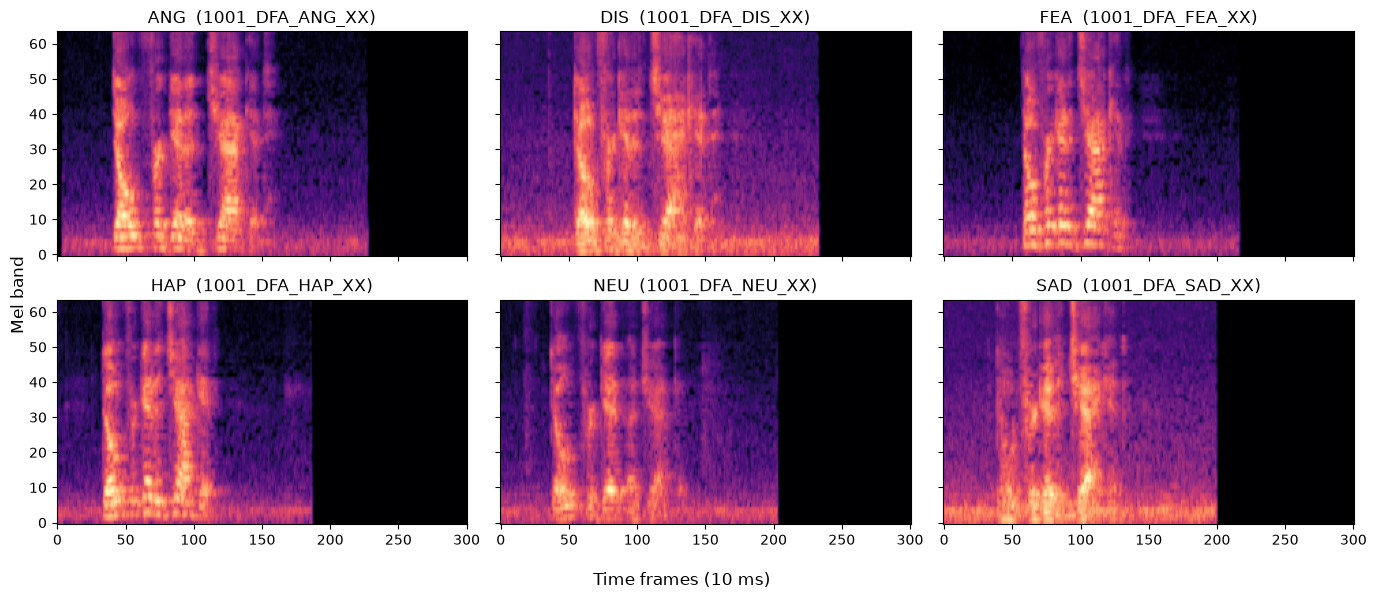

In [193]:
# Visual example: one Train clip per emotion
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)
train_df_vis = splits[splits["split"] == "train"]
for ax, emo in zip(axes.ravel(), U.CLASSES):
    row = train_df_vis[train_df_vis["emotion"] == emo].iloc[0]
    spec = wav_to_logmel(row["abs_path"])
    im = ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{emo}  ({row['sample_id']})")
fig.supxlabel("Time frames (10 ms)"); fig.supylabel("Mel band")
plt.tight_layout(); plt.show()

### 12.4 Feature extraction (cached)
Computing ~7 400 spectrograms takes a few minutes, so we cache them as `.npy` files in `features/M4/`.
The cache stores the feature configuration; if it changes, the features are recomputed automatically.
Extracting features does **not** use labels or evaluate anything; Test features are only computed inside
`generar_probs_test_M4()` (12.11), after the ensemble is frozen.

In [194]:
def extract_split(df: pd.DataFrame, split_name: str) -> np.ndarray:
    # Return the (N, 64, 301) log-Mel array for a split, using the cache when valid.
    npy_path = M4_FEAT_DIR / f"logmel_{split_name}.npy"
    meta_path = M4_FEAT_DIR / f"logmel_{split_name}.json"
    ids = df["sample_id"].tolist()
    if npy_path.exists() and meta_path.exists():
        meta = json.load(open(meta_path))
        if meta["cfg"] == FEATURE_CFG and meta["sample_ids"] == ids:
            print(f"[{split_name}] loaded from cache")
            return np.load(npy_path)
    t0 = time.time()
    feats = Parallel(n_jobs=-1)(delayed(wav_to_logmel)(p) for p in df["abs_path"])
    X = np.stack(feats).astype(np.float32)
    np.save(npy_path, X)
    json.dump({"cfg": FEATURE_CFG, "sample_ids": ids}, open(meta_path, "w"))
    print(f"[{split_name}] computed {X.shape} in {time.time() - t0:.0f} s")
    return X


df_train = U.get_split(splits, "train")
df_val   = U.get_split(splits, "val")
X_train = extract_split(df_train, "train")
X_val   = extract_split(df_val,   "val")
y_train = U.labels_to_idx(df_train["emotion"])     # indices following U.CLASSES
y_val   = U.labels_to_idx(df_val["emotion"])
print("Train:", X_train.shape, "| Val:", X_val.shape)

[train] loaded from cache
[val] loaded from cache
Train: (5152, 64, 301) | Val: (1148, 64, 301)


### 12.5 Normalization statistics (Train only)
Each mel band gets its own mean and standard deviation, computed **only from the Train set**.
The same numbers are then applied to Validation, Test and any new audio. They are saved to `models/M4/norm_stats.npz`
because `predict_proba_M4` needs them later.

In [195]:
mel_mean = X_train.mean(axis=(0, 2)).astype(np.float32)          # (64,)
mel_std  = (X_train.std(axis=(0, 2)) + 1e-6).astype(np.float32)  # (64,)
np.savez(M4_MODEL_DIR / "norm_stats.npz", mean=mel_mean, std=mel_std)

def normalize(X: np.ndarray) -> np.ndarray:
    # Works for (N, 64, T) and for a single (64, T) spectrogram.
    if X.ndim == 3:
        return (X - mel_mean[None, :, None]) / mel_std[None, :, None]
    return (X - mel_mean[:, None]) / mel_std[:, None]

Xn_train, Xn_val = normalize(X_train), normalize(X_val)
print(f"Normalized Train: mean={Xn_train.mean():.3f}  std={Xn_train.std():.3f}")

Normalized Train: mean=-0.000  std=1.000


### 12.6 Dataset, SpecAugment and DataLoaders
**SpecAugment** randomly hides a few frequency bands and time segments of the spectrogram. This forces the CNN not to
depend on one specific region, which is our main protection against overfitting to the 63 training actors.
Augmentation is applied **only to Train**.

In [196]:
def spec_augment(x: np.ndarray) -> np.ndarray:
    # x: normalized spectrogram (64, T). Masked areas are set to 0 (= the mean after normalization).
    x = x.copy()
    n_mels, n_t = x.shape
    if np.random.rand() < 0.5:                       # random time shift (circular)
        x = np.roll(x, np.random.randint(-30, 31), axis=1)
    for _ in range(2):                               # 2 frequency masks (up to 8 bands)
        f = np.random.randint(0, 9); f0 = np.random.randint(0, n_mels - f + 1)
        x[f0:f0 + f, :] = 0.0
    for _ in range(2):                               # 2 time masks (up to 30 frames = 0.3 s)
        t = np.random.randint(0, 31); t0 = np.random.randint(0, n_t - t + 1)
        x[:, t0:t0 + t] = 0.0
    if np.random.rand() < 0.5:                       # light Gaussian noise
        x = x + np.random.normal(0, 0.05, size=x.shape).astype(np.float32)
    return x


class LogMelDataset(Dataset):
    def __init__(self, X_norm, y, augment=False):
        self.X, self.y, self.augment = X_norm, y, augment
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x = spec_augment(self.X[i]) if self.augment else self.X[i]
        return torch.from_numpy(np.ascontiguousarray(x, dtype=np.float32))[None], int(self.y[i])


# num_workers=0 keeps NumPy-based augmentation reproducible with the global seed
train_loader = DataLoader(LogMelDataset(Xn_train, y_train, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader   = DataLoader(LogMelDataset(Xn_val, y_val, augment=False),
                          batch_size=128, shuffle=False, num_workers=0)
print("Batches per epoch:", len(train_loader))

Batches per epoch: 80


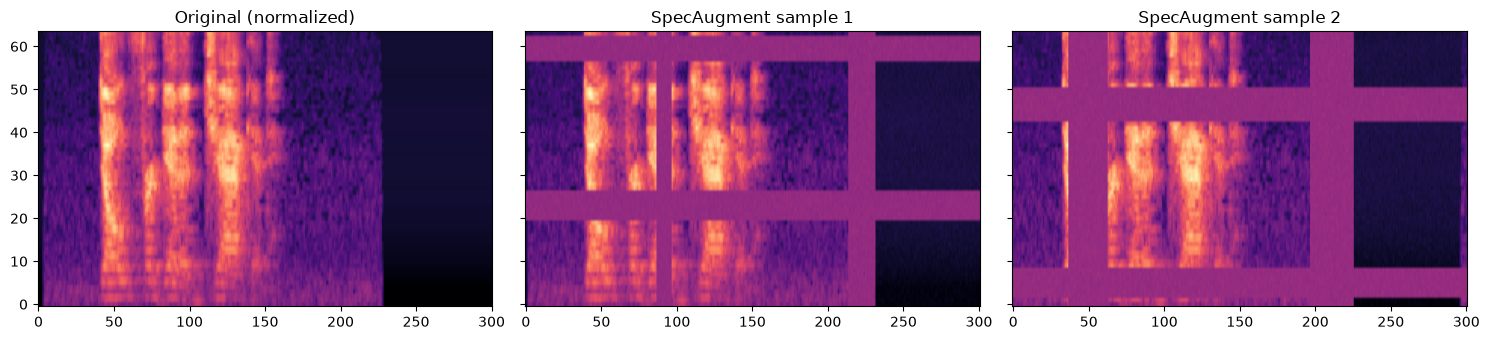

In [197]:
# Quick look at what augmentation does to a spectrogram
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
orig = Xn_train[0]
axes[0].imshow(orig, origin="lower", aspect="auto", cmap="magma"); axes[0].set_title("Original (normalized)")
for ax, k in zip(axes[1:], (1, 2)):
    ax.imshow(spec_augment(orig), origin="lower", aspect="auto", cmap="magma"); ax.set_title(f"SpecAugment sample {k}")
plt.tight_layout(); plt.show()

### 12.7 Model: 2-D CNN from scratch
Four convolutional blocks (16 → 32 → 64 → 128 channels). Each block has two `Conv3×3 → BatchNorm → ReLU` layers
followed by 2×2 max-pooling. At the end, **global average + max pooling** collapse the time-frequency map into a
vector, followed by Dropout and a linear layer with 6 outputs (softmax is applied at prediction time).
The network is deliberately small (~0.3 M parameters) because we only have ~5 000 training clips.

In [198]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
    def forward(self, x):
        return self.net(x)


class EmotionCNN(nn.Module):
    def __init__(self, n_classes=6, channels=CHANNELS, dropout=DROPOUT):
        super().__init__()
        chans = (1,) + tuple(channels)
        self.features = nn.Sequential(*[ConvBlock(chans[i], chans[i + 1]) for i in range(len(channels))])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * channels[-1], n_classes)      # avg-pool + max-pool concatenated
    def forward(self, x):                                      # x: (B, 1, 64, T) -> logits (B, 6)
        h = self.features(x)
        h = torch.cat([h.mean(dim=(2, 3)), h.amax(dim=(2, 3))], dim=1)
        return self.fc(self.dropout(h))


model = EmotionCNN().to(M4_DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_params:,}")
print("Output shape for a dummy batch:", tuple(model(torch.zeros(2, 1, N_MELS, N_FRAMES, device=M4_DEVICE)).shape))

Trainable parameters: 295,254
Output shape for a dummy batch: (2, 6)


### 12.8 Training
- Loss: cross-entropy with **label smoothing** (0.1) to avoid over-confident outputs.
- Optimizer: AdamW (weight decay), learning rate halved when Validation loss plateaus.
- **Early stopping and best checkpoint use Validation macro-F1** (allowed by the assignment).
- Train only sees the Train set; Test is not used anywhere.
- **Trained only once:** if `models/M4/best.pt` and the training history already exist, they are loaded instead of retraining, so re-running the notebook never changes M4 (GPU training is not bit-for-bit reproducible).

In [199]:
@torch.no_grad()
def predict_logits(model, loader):
    # Run the model in fp32 (no autocast) and return logits as a NumPy array.
    model.eval()
    out = []
    for xb, _ in loader:
        out.append(model(xb.to(M4_DEVICE)).float().cpu().numpy())
    return np.concatenate(out)


def train_model():
    U.set_seed(U.SEED)
    model = EmotionCNN().to(M4_DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)
    use_amp = M4_DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history, best_f1, best_epoch, bad = [], -1.0, 0, 0
    ckpt_path = M4_MODEL_DIR / "best.pt"
    for epoch in range(1, MAX_EPOCHS + 1):
        t0 = time.time()
        model.train()
        run_loss, n_seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(M4_DEVICE), yb.to(M4_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=M4_DEVICE.type, enabled=use_amp):
                loss = criterion(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            run_loss += loss.item() * len(yb); n_seen += len(yb)
        train_loss = run_loss / n_seen

        val_logits = predict_logits(model, val_loader)
        val_loss = F.cross_entropy(torch.from_numpy(val_logits), torch.from_numpy(y_val)).item()
        m = U.compute_metrics(y_val, val_logits.argmax(1))
        scheduler.step(val_loss)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                            val_acc=m["accuracy"], val_macro_f1=m["macro_f1"],
                            lr=optimizer.param_groups[0]["lr"]))

        improved = m["macro_f1"] > best_f1
        if improved:
            best_f1, best_epoch, bad = m["macro_f1"], epoch, 0
            torch.save({"state_dict": model.state_dict(),
                        "model_cfg": {"channels": list(CHANNELS), "dropout": DROPOUT},
                        "feature_cfg": FEATURE_CFG, "epoch": epoch, "val_macro_f1": best_f1}, ckpt_path)
        else:
            bad += 1
        print(f"Epoch {epoch:3d} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f} | "
              f"val_acc {m['accuracy']:.3f} | val_macro_F1 {m['macro_f1']:.3f} | "
              f"{time.time() - t0:.0f}s {'<- best' if improved else ''}")
        if bad >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, val macro-F1 {best_f1:.4f})")
            break
    return pd.DataFrame(history), best_epoch, best_f1


CHECKPOINT_PATH = M4_MODEL_DIR / "best.pt"
HISTORY_PATH = RESULTS_DIR / "M4_training_history.csv"

if CHECKPOINT_PATH.exists() and HISTORY_PATH.exists():
    # Already trained once: reuse it, so re-running the notebook never retrains (or changes) M4.
    history = pd.read_csv(HISTORY_PATH)
    best_epoch = int(torch.load(CHECKPOINT_PATH, map_location="cpu")["epoch"])
    best_f1 = float(history.loc[history["epoch"] == best_epoch, "val_macro_f1"].iloc[0])
    print("Existing checkpoint found -> training skipped")
else:
    history, best_epoch, best_f1 = train_model()
    history.to_csv(HISTORY_PATH, index=False)
print(f"\nBest epoch: {best_epoch} | best val macro-F1: {best_f1:.4f}")

Existing checkpoint found -> training skipped

Best epoch: 61 | best val macro-F1: 0.6998


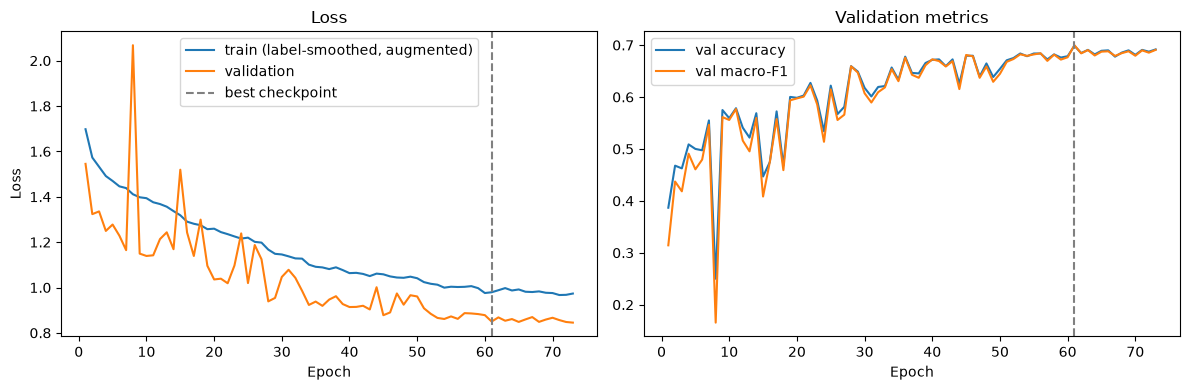

In [200]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["epoch"], history["train_loss"], label="train (label-smoothed, augmented)")
ax[0].plot(history["epoch"], history["val_loss"], label="validation")
ax[0].axvline(best_epoch, color="gray", ls="--", label="best checkpoint")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].set_title("Loss")
ax[1].plot(history["epoch"], history["val_acc"], label="val accuracy")
ax[1].plot(history["epoch"], history["val_macro_f1"], label="val macro-F1")
ax[1].axvline(best_epoch, color="gray", ls="--")
ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].set_title("Validation metrics")
plt.tight_layout(); plt.show()

### 12.9 Validation results, calibration and probabilities
We reload the **best checkpoint** and compute Validation logits.

**Temperature scaling.** Neural networks are often over-confident (probabilities close to 0 or 1). In Soft Voting
this makes M4 "shout louder" than the other models. Temperature scaling divides the logits by a single number `T`
(fitted on Validation by minimizing the negative log-likelihood) before the softmax. It does **not** change the
predicted class (argmax is unchanged), only how confident the probabilities are. Set
`USE_TEMPERATURE_SCALING = False` in 12.1 if the group decides not to use it.

In [201]:
ckpt = torch.load(M4_MODEL_DIR / "best.pt", map_location=M4_DEVICE)
model = EmotionCNN(channels=tuple(ckpt["model_cfg"]["channels"]), dropout=ckpt["model_cfg"]["dropout"]).to(M4_DEVICE)
model.load_state_dict(ckpt["state_dict"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

val_logits = predict_logits(model, val_loader)


def fit_temperature(logits, y):
    # Find T > 0 minimizing the cross-entropy of softmax(logits / T) on the given data.
    lg = torch.tensor(logits, dtype=torch.float64)
    yy = torch.tensor(y, dtype=torch.long)
    log_t = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=100)
    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(lg / log_t.exp(), yy)
        loss.backward()
        return loss
    opt.step(closure)
    return float(log_t.exp().clamp(0.5, 5.0))


def softmax_np(logits, T=1.0):
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def expected_calibration_error(probs, y, n_bins=10):
    conf, pred = probs.max(1), probs.argmax(1)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            ece += mask.mean() * abs((pred[mask] == y[mask]).mean() - conf[mask].mean())
    return ece


T = fit_temperature(val_logits, y_val) if USE_TEMPERATURE_SCALING else 1.0
nll = lambda p: -np.log(p[np.arange(len(y_val)), y_val] + 1e-12).mean()
p_raw, p_cal = softmax_np(val_logits, 1.0), softmax_np(val_logits, T)
print(f"Temperature T = {T:.3f}  (use_temperature_scaling={USE_TEMPERATURE_SCALING})")
print(f"NLL : raw {nll(p_raw):.4f} -> final {nll(p_cal):.4f}")
print(f"ECE : raw {expected_calibration_error(p_raw, y_val):.4f} -> final {expected_calibration_error(p_cal, y_val):.4f}")
assert (p_raw.argmax(1) == p_cal.argmax(1)).all()   # predicted classes are unchanged

json.dump({"temperature": T, "use_temperature_scaling": USE_TEMPERATURE_SCALING},
          open(M4_MODEL_DIR / "temperature.json", "w"))
val_probs = p_cal      # final probabilities that go to the ensemble (order = U.CLASSES)

Loaded best checkpoint from epoch 61
Temperature T = 0.852  (use_temperature_scaling=True)
NLL : raw 0.8500 -> final 0.8407
ECE : raw 0.0571 -> final 0.0284


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
M4 — CNN Log-Mel (Validation),0.6986,0.7005,0.7003,0.6998,0.6988


              precision    recall  f1-score   support

         ANG      0.788     0.740     0.763       196
         DIS      0.673     0.694     0.683       196
         FEA      0.639     0.622     0.630       196
         HAP      0.736     0.684     0.709       196
         NEU      0.713     0.768     0.739       168
         SAD      0.654     0.694     0.673       196

    accuracy                          0.699      1148
   macro avg      0.700     0.700     0.700      1148
weighted avg      0.700     0.699     0.699      1148



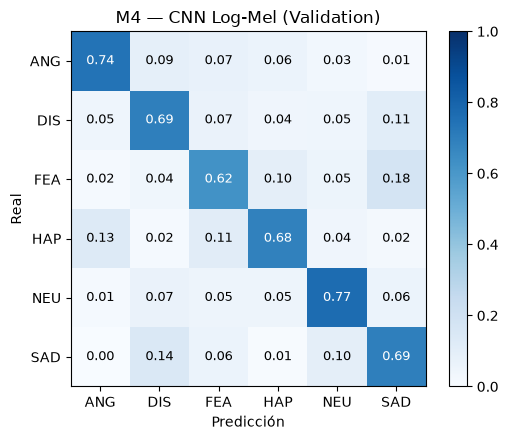

In [202]:
# Validation metrics (the 5 metrics required by the assignment) + confusion matrix + per-class report
y_pred_val = val_probs.argmax(1)
val_metrics = U.compute_metrics(y_val, y_pred_val)
display(pd.DataFrame([val_metrics], index=["M4 — CNN Log-Mel (Validation)"]).round(4))

print(classification_report(U.idx_to_labels(y_val), U.idx_to_labels(y_pred_val),
                            labels=U.CLASSES, digits=3, zero_division=0))
U.plot_confusion_matrix(y_val, y_pred_val, title="M4 — CNN Log-Mel (Validation)")
plt.savefig(RESULTS_DIR / "M4_confusion_val.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary row for the group's comparison table (model_results.csv is assembled by Person D)
pd.DataFrame([{"model": "M4", "classifier": "CNN 2D (from scratch)",
               "representation": "Log-Mel (16 kHz, 3 s, 64 mels)", "split": "val", **val_metrics}]
             ).to_csv(RESULTS_DIR / "M4_val_metrics.csv", index=False)

In [203]:
# Save Validation probabilities in the group format (validates shape, sums, sample_ids and labels)
U.save_probs(df_val["sample_id"], df_val["emotion"].values, val_probs, M4_NAME, "val", splits_df=splits)

check = U.load_probs(M4_NAME, "val")
print(check.shape, "| columns:", list(check.columns))
check.head()

Guardado c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\probs\val\probs_val_M4.csv  (1148 filas)  acc=0.6986  macro_f1=0.6998
(1148, 8) | columns: ['sample_id', 'true_label', 'prob_ANG', 'prob_DIS', 'prob_FEA', 'prob_HAP', 'prob_NEU', 'prob_SAD']


,sample_id,true_label,prob_ANG,prob_DIS,prob_FEA,prob_HAP,prob_NEU,prob_SAD
0,1005_DFA_ANG_XX,ANG,0.789997,0.014252,0.155977,0.031253,0.000957,0.007565
1,1005_DFA_DIS_XX,DIS,0.138115,0.821580,0.000274,0.039176,0.000293,0.000562
2,1005_DFA_FEA_XX,FEA,0.060946,0.001431,0.582733,0.350537,0.001132,0.003220
3,1005_DFA_HAP_XX,HAP,0.162185,0.018846,0.201160,0.613337,0.001219,0.003253
4,1005_DFA_NEU_XX,NEU,0.097532,0.049211,0.005540,0.189287,0.623738,0.034693


### 12.10 Inference on a single audio: `predict_proba_M4`
This function is **self-contained**: it loads the checkpoint, the normalization statistics and the temperature from
`models/M4/`, so it works in a new session without retraining. It handles stereo files, other sampling rates
(resampled to 16 kHz), silent files and any duration (centered crop / zero-padding to 3 s, exactly like in training).
It returns a `(6,)` array in the order `ANG, DIS, FEA, HAP, NEU, SAD`.

In [204]:
_ARTIFACTS = {}

def _load_m4_artifacts():
    # Lazy-load (once) the model, normalization stats and temperature from models/M4/.
    if _ARTIFACTS:
        return _ARTIFACTS
    ckpt = torch.load(M4_MODEL_DIR / "best.pt", map_location=M4_DEVICE)
    net = EmotionCNN(channels=tuple(ckpt["model_cfg"]["channels"]),
                     dropout=ckpt["model_cfg"]["dropout"]).to(M4_DEVICE)
    net.load_state_dict(ckpt["state_dict"]); net.eval()
    stats = np.load(M4_MODEL_DIR / "norm_stats.npz")
    temp = json.load(open(M4_MODEL_DIR / "temperature.json"))
    _ARTIFACTS.update(model=net, mean=stats["mean"], std=stats["std"],
                      T=temp["temperature"] if temp["use_temperature_scaling"] else 1.0)
    return _ARTIFACTS


@torch.no_grad()
def predict_proba_M4(wav_path) -> np.ndarray:
    # Probabilities (6,) for one .wav file, in the order of U.CLASSES.
    art = _load_m4_artifacts()
    spec = wav_to_logmel(wav_path)                                     # (64, 301)
    spec = (spec - art["mean"][:, None]) / art["std"][:, None]         # Train-only statistics
    x = torch.from_numpy(spec.astype(np.float32))[None, None].to(M4_DEVICE)
    logits = art["model"](x).float().cpu().numpy()                     # (1, 6)
    return softmax_np(logits, art["T"])[0]

In [205]:
# 1) Format check required by the group contract
example_wav = df_val.loc[0, "abs_path"]
U.validate_predict_fn(predict_proba_M4, example_wav, "predict_proba_M4")

# 2) Consistency check: predicting from the raw .wav must match the saved Validation probabilities
saved = check.set_index("sample_id")
for i in [0, 100, 500, 1000]:
    sid, path = df_val.loc[i, "sample_id"], df_val.loc[i, "abs_path"]
    p_new = predict_proba_M4(path)
    p_saved = saved.loc[sid, U.PROB_COLS].values.astype(float)
    assert np.allclose(p_new, p_saved, atol=1e-3), f"Mismatch for {sid}: {p_new} vs {p_saved}"
print("OK: predict_proba_M4 reproduces the saved Validation probabilities.")

predict_proba_M4 OK -> ANG  ANG=0.79  DIS=0.01  FEA=0.16  HAP=0.03  NEU=0.00  SAD=0.01
OK: predict_proba_M4 reproduces the saved Validation probabilities.


### 12.11 Test probabilities: `generar_probs_test_M4()` — **DO NOT RUN YET**
This function is only *defined* here. It must be executed **after** the group freezes the ensemble
(`results/frozen_config.json` exists). `U.save_probs` enforces this and raises `PermissionError` otherwise.
No Test metric is computed in this notebook.

In [206]:
def generar_probs_test_M4():
    # Compute and save M4 probabilities on the Test split (run ONLY after the ensemble is frozen).
    if not U.FROZEN_CONFIG_PATH.exists():
        raise PermissionError("The ensemble is not frozen yet: results/frozen_config.json is missing.")
    df_test = U.get_split(splits, "test")
    X_test = extract_split(df_test, "test")
    art = _load_m4_artifacts()
    Xn_test = (X_test - art["mean"][None, :, None]) / art["std"][None, :, None]
    loader = DataLoader(LogMelDataset(Xn_test, U.labels_to_idx(df_test["emotion"]), augment=False),
                        batch_size=128, shuffle=False, num_workers=0)
    probs = softmax_np(predict_logits(art["model"], loader), art["T"])
    return U.save_probs(df_test["sample_id"], df_test["emotion"].values, probs, M4_NAME, "test", splits_df=splits)

# generar_probs_test_M4()   # <- leave commented until the group freezes the ensemble

### 12.12 Discussion of M4

**Results on Validation:** accuracy 0.699, Macro F1 0.700, Weighted F1 0.699. M4 sits in the middle tier: below the pretrained embeddings (M5 0.783, M3 0.742) and well above the hand-crafted descriptors (M1 0.558, M2 0.540).

**Training.** The best checkpoint is epoch 61 and early stopping ended training at epoch 73. At the best epoch the training loss (0.979) is *higher* than the Validation loss (0.850); this does not mean the model is underfitting, because the training loss is measured with label smoothing and SpecAugment, which both make it artificially higher. The Validation curve is noisy during the first ~20 epochs (for example, accuracy drops to 0.25 at epoch 8) and becomes stable in the second half of training, so the checkpoint is not a lucky spike.

**Per emotion.** M4 has the flattest profile of the five models: recall between 0.62 (FEA) and 0.77 (NEU), with ANG at 0.74 and the highest precision on ANG (0.79). FEA is its hardest emotion, mostly confused with SAD, the same shared error that every model shows (section 14.5).

**Calibration.** The fitted temperature is **T = 0.852 (< 1)**: the raw CNN was slightly *under*-confident, because label smoothing (0.1) teaches it never to output probabilities close to 1. Temperature scaling sharpened the probabilities, reducing the NLL from 0.850 to 0.841 and the ECE from 0.057 to 0.028, without changing any prediction. After scaling, M4's average confidence (0.689) is almost equal to its accuracy (0.699), so it is the best-calibrated model of the group (section 17), which matters for Soft Voting.

**Role in the ensemble.** Although M4 is 4 points below M3 individually, it is the third most useful model in Leave-One-Model-Out (removing it costs 0.006 Macro F1, after M5 and M3), and in the best 3-model ensemble (M3 + M4 + M5) it receives a weight of 0.35, *more* than M5 (0.20). It also gets right 86 of the 252 Validation files that M5 gets wrong (section 14.5.3). This is the expected effect of using a different representation: a CNN that learns from the spectrogram makes errors that are partly different from the pretrained models (analyzed in sections 21 and 22). The group's final ensemble (M3 + M5) does not include M4 for efficiency reasons (section 23).

**Weaknesses and caveats.**
- Trained from scratch on 5152 clips from 63 actors: it cannot reach the level of representations pretrained on thousands of hours of speech.
- The fixed 3 s window crops the center of longer clips (CREMA-D max ≈ 5 s), so part of a long utterance is lost.
- Validation was used for early stopping, checkpoint selection and temperature scaling, so M4's Validation score is slightly optimistic. Test remains untouched.

## 13. Model 5 — Frozen Whisper embeddings + MLP

| | |
|---|---|
| Representation | Embeddings from the **Whisper encoder** (`openai/whisper-small`), frozen (no fine-tuning), **averaged over the 13 encoder layers** |
| Classifier | **MLP** (one hidden layer of 256 neurons); the regularization `alpha` is chosen on **Validation** |
| Output | `probs/val/probs_val_M5.csv`, `models/M5/`, `predict_proba_M5(wav_path)` |

**Why Whisper.** Whisper was trained on ~680,000 hours of real speech, in many languages and acoustic conditions. Its encoder learned a robust representation of the voice: timbre, prosody and phonetic content. It is a representation family distinct from MFCC, Log-Mel and the self-supervised models (Wav2Vec2, HuBERT, WavLM), because it was trained in a *supervised* way to transcribe speech. Its errors are therefore expected to differ from those of the other models, which is exactly what the ensemble needs.

In [207]:
# M5 folders: features = cached Whisper embeddings, models = trained scaler + MLP.
M5_FEAT = PROJECT / 'features' / 'M5'
M5_MODEL = PROJECT / 'models' / 'M5'
for folder in (M5_FEAT, M5_MODEL):
    folder.mkdir(parents=True, exist_ok=True)

### 13.1 Whisper embedding extraction

**Preprocessing:**
- **Sample rate:** 16 kHz mono (`librosa.load(sr=16000)`), the rate Whisper expects and the one in the group contract.
- **Input representation:** the `WhisperFeatureExtractor` turns the audio into an 80-band log-Mel spectrogram (25 ms window, 10 ms hop).
- **Duration / padding:** Whisper always works with **30 s**. Shorter audio is zero-padded and longer audio is truncated. CREMA-D clips last ~2–5 s, so none is truncated.
- **Pooling over real frames:** the encoder returns 1500 frames (one every 20 ms = 320 samples). Since more than 85% of them would be padding, **only the first `ceil(n_samples / 320)` frames**, which correspond to the real audio, are averaged. Averaging all of them would make every embedding look like the embedding of silence.
- **Layers:** a summary of **all 13 encoder outputs** is stored (the embedding output + 12 Transformer layers), each with 768 dimensions. They are averaged into a single vector per audio in section 13.2.
- **Frozen:** Whisper is not trained. Extraction runs once and is saved to `features/M5/` with shape `(7442, 13, 768)` in float16. Extracting Test features is allowed because it uses no labels; what is not done is evaluating on Test.

In [208]:
import numpy as np
import torch
import librosa
from tqdm.auto import tqdm
from transformers import WhisperFeatureExtractor, WhisperModel

# 12 encoder layers, 768 numbers per frame
WHISPER = 'openai/whisper-small'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# half precision on GPU: 2x less memory
DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

# audio samples per encoder frame: 20 ms x 16 000 samples/s = 320
FRAME = 320

# Whisper has two parts: the feature extractor (audio -> spectrogram) and the model.
# We only keep the ENCODER (the part that "listens"); the decoder, which writes text, is discarded.
feature_extractor = WhisperFeatureExtractor.from_pretrained(WHISPER)
encoder = WhisperModel.from_pretrained(WHISPER, dtype=DTYPE).encoder.to(DEVICE)

# inference mode: Whisper is FROZEN, it is never trained here
encoder.eval()


def load_wav(path):
    """File on disk -> 1-D waveform at 16 kHz.

    The waveform is the air pressure measured 16 000 times per second, as floats in [-1, 1].
      - sr=16000: resamples if the file has another rate (e.g. 44.1 kHz -> 16 kHz).
      - mono=True: averages the channels if the file is stereo.
    Example: a 2.5 s CREMA-D clip -> array of shape (40000,).
    """
    waveform, _ = librosa.load(path, sr=U.SR, mono=True)
    return waveform


@torch.no_grad()                   # no gradients: we only read Whisper's outputs, we don't train it
def whisper_embed(waveforms):
    """List of B waveforms (16 kHz, mono) -> array (B, 13, 768).

    For each audio: one 768-number summary per encoder layer (input embedding + 12 layers).
    Shapes below follow one 2.5 s clip (40 000 samples).
    """
    # STEP 1 - Waveform -> log-Mel spectrogram (an "image" of the sound).
    #   Whisper always works with 30 s: the extractor pads the 40 000 samples with silence
    #   up to 480 000 samples (30 s), or truncates longer audios.
    #   Then it cuts the signal into 25 ms windows every 10 ms -> 3000 time steps, and
    #   measures the energy in 80 frequency bands (Mel scale, low to high pitch), in log.
    #   Result per audio: (80 bands, 3000 steps). The first 250 steps are the real voice,
    #   the remaining 2750 are padding silence.
    log_mel = feature_extractor(waveforms, sampling_rate=U.SR, return_tensors='pt').input_features   # (B, 80, 3000)
    log_mel = log_mel.to(DEVICE, DTYPE)

    # STEP 2 - Spectrogram -> encoder hidden states.
    #   Two convolutions turn each time step into a 768-number vector; the second one has
    #   stride 2, so time is halved: 3000 steps of 10 ms -> 1500 frames of 20 ms.
    #   Then 12 Transformer layers refine those vectors, each one looking at the whole audio.
    #   hidden_states keeps the output after the convolutions (index 0) and after each of
    #   the 12 layers (indices 1-12): 13 descriptions of the same audio.
    encoder_output = encoder(log_mel, output_hidden_states=True)
    hidden_states = torch.stack(encoder_output.hidden_states, dim=1)            # (B, 13 layers, 1500 frames, 768)

    # STEP 3 - Count how many frames contain real audio (not the 30 s padding).
    #   1 frame = 320 samples, so a 40 000-sample clip covers ceil(40000 / 320) = 125 frames.
    #   The other 1375 frames only describe silence.
    n_real_frames = [max(1, min(hidden_states.shape[2], int(np.ceil(len(waveform) / FRAME)))) for waveform in waveforms]

    # STEP 4 - Mean pooling over time: average the real frames into ONE vector per layer.
    #   (13, 125, 768) -> (13, 768). This turns a variable-length audio into a fixed-size
    #   summary that a classifier can use. Averaging is done in float32 to avoid fp16 rounding.
    pooled_per_layer = [hidden_states[audio_index, :, :n_frames].float().mean(dim=1)
                        for audio_index, n_frames in enumerate(n_real_frames)]
    return torch.stack(pooled_per_layer).cpu().numpy()                    # (B, 13, 768)

print(DEVICE, WHISPER)

Loading weights: 100%|██████████| 479/479 [00:01<00:00, 335.67it/s]


cuda openai/whisper-small


In [209]:
EMBEDDINGS_PATH = M5_FEAT / 'whisper_small_layers.npy'
IDS_PATH = M5_FEAT / 'sample_ids.csv'

# audios processed together on the GPU (faster than one by one)
BATCH = 32

if EMBEDDINGS_PATH.exists():
    # Cache: extraction is slow (~6 min on GPU), so it runs only once and is loaded afterwards.
    layer_embeddings = np.load(EMBEDDINGS_PATH)
else:
    # All 7442 audios (train, val AND test). Extracting test features is allowed:
    # it uses no labels. What is forbidden is EVALUATING on test before the ensemble is frozen.
    audio_paths = [AUDIO_ROOT / relative_path for relative_path in splits['path']]

    layer_embeddings = np.concatenate([
        whisper_embed([load_wav(audio_path) for audio_path in audio_paths[start:start + BATCH]])   # 32 files -> (32, 13, 768)
        for start in tqdm(range(0, len(audio_paths), BATCH))
    ]).astype(np.float16)

    np.save(EMBEDDINGS_PATH, layer_embeddings)

    splits[['sample_id']].to_csv(IDS_PATH, index=False)            # remembers which audio is each row

# Row i of layer_embeddings must be the audio in row i of splits.csv; otherwise labels would be mismatched.
import pandas as pd
assert (pd.read_csv(IDS_PATH)['sample_id'].values == splits['sample_id'].values).all()
assert np.isfinite(layer_embeddings).all()       # no NaN or infinite values

# The new dataframe with each audio as a embedding representation about the audio
layer_embeddings.shape                           # (7442 audios, 13 layers, 768 numbers)

(7442, 13, 768)

### 13.2 Final representation and MLP classifier (Validation only)

**Representation: average of the 13 layers.** Each audio has 13 summaries of 768 numbers, one per layer. They are averaged into **a single vector of 768 numbers**. Early layers describe how the voice sounds (pitch, energy, timbre) and later layers more abstract information; the average keeps some of each without multiplying the number of variables.

Discarded alternatives:
- **Concatenating the 13 layers:** 9984 variables for 5152 Train audio files. Higher risk of overfitting and 10 times slower.
- **Choosing a single layer:** one more decision made by looking at Validation, and every such decision makes the Validation score more optimistic.

**Classifier: MLP** (*Multi-Layer Perceptron*), a neural network with one hidden layer of 256 neurons that takes the 768 numbers and outputs 6 probabilities.
- The hidden layer lets it learn **non-linear combinations** of the variables, and it still trains in seconds on CPU.
- **`alpha` (L2 regularization):** penalizes large weights and forces the network to be simpler. With a small `alpha` it can memorize Train (overfitting); with too large a value it underfits. Three values are tried and the one with the highest **Macro F1 on Validation** is chosen (criterion fixed in advance, because NEU has fewer audio files).
- **`early_stopping=True`:** internally holds out 10% **of Train** and stops training when the score on that 10% stops improving. Validation is not used for this.

The `StandardScaler` (which centers each variable at 0 with standard deviation 1) is fitted **on Train only**.

In [210]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Boolean masks: True/False for each of the 7442 rows, used to select one partition.
train = (splits['split'] == 'train').values
val = (splits['split'] == 'val').values
test = (splits['split'] == 'test').values       # used only in section 7, after the ensemble is frozen

# Labels as integers in the official CLASSES order: ANG=0, DIS=1, FEA=2, HAP=3, NEU=4, SAD=5.
y_train = U.labels_to_idx(splits.loc[train, 'emotion'])
y_val = U.labels_to_idx(splits.loc[val, 'emotion'])

# Final representation: average the 13 layer summaries into ONE vector per audio.
# (7442 audios, 13 layers, 768) -> (7442 audios, 768). Float32 avoids fp16 rounding in the average.
audio_embeddings = layer_embeddings.astype(np.float32).mean(axis=1)

# Standardize each of the 768 numbers to mean 0 and std 1, so none dominates just because of
# its scale. Mean and std are computed on TRAIN ONLY (no data leakage), then applied to validation.
scaler = StandardScaler().fit(audio_embeddings[train])
X_train = scaler.transform(audio_embeddings[train])      # (5152, 768)
X_val = scaler.transform(audio_embeddings[val])          # (1148, 768)

mlp_by_alpha, rows = {}, []
for alpha in (1e-3, 1e-1, 1.0):                          # strength of the L2 penalty on large weights
    # MLP: 768 inputs -> 256 hidden neurons (ReLU) -> 6 outputs turned into probabilities (softmax).
    # early_stopping=True holds out 10% OF TRAIN and stops when its score stops improving.
    mlp = MLPClassifier((256,), alpha=alpha, early_stopping=True, max_iter=500,
                        random_state=U.SEED).fit(X_train, y_train)

    # predict_proba -> (1148, 6). reorder_proba guarantees the columns follow CLASSES,
    # which is critical for averaging probabilities across models in the ensemble.
    val_probs = U.reorder_proba(mlp.predict_proba(X_val), mlp.classes_)
    mlp_by_alpha[alpha] = mlp
    # Macro F1 on TRAIN too: if it is much higher than on validation, the model is memorizing (overfitting).
    train_probs = U.reorder_proba(mlp.predict_proba(X_train), mlp.classes_)
    rows.append({'alpha': alpha,
                 'train_macro_f1': U.metrics_from_probs(y_train, train_probs)['macro_f1'],
                 **U.metrics_from_probs(y_val, val_probs)})          # validation metrics; prediction = argmax

# Same format as the other members' search files (e.g. M1_svm_hyperparams.csv): one row per
# configuration, sorted from best to worst validation Macro F1.
alpha_results = (pd.DataFrame(rows)[['alpha', 'train_macro_f1', 'macro_f1', 'accuracy',
                                     'macro_precision', 'macro_recall', 'weighted_f1']]
                 .sort_values('macro_f1', ascending=False))
alpha_results.to_csv(PROJECT / 'results' / 'M5_mlp_hyperparams.csv', index=False)

BEST_ALPHA = alpha_results.iloc[0]['alpha']             # chosen on VALIDATION by Macro F1 (first row)
print('alpha elegido:', BEST_ALPHA)
alpha_results.set_index('alpha').round(4)

alpha elegido: 1.0


,train_macro_f1,macro_f1,accuracy,macro_precision,macro_recall,weighted_f1
alpha,,,,,,
1.000,0.9688,0.7825,0.7805,0.7851,0.7819,0.7817
0.001,0.9786,0.7791,0.7761,0.7834,0.7781,0.7780
0.100,0.9804,0.7747,0.7726,0.7774,0.7741,0.7740


**Reading.** The `alpha` with the highest Validation Macro F1 is chosen. With 1148 audio files, differences of around one point are within sampling noise, so the Validation score of the chosen value is somewhat optimistic. The honest score will be the Test one.

**Train vs. Validation.** The `train_macro_f1` column is the score on the same audio files used for training. If it is much higher than the Validation score, the model is memorizing (overfitting). The table is saved to `results/M5_mlp_hyperparams.csv`, in the same format as the other models' searches.

### 13.3 Final M5 model: Validation metrics and artifacts

These are the metrics of the chosen model on Validation (Test is not used). The following are saved:
- `probs/val/probs_val_M5.csv`, with `U.save_probs`, which checks the class order, that rows sum to 1 and that the `sample_id`s match the split;
- `models/M5/m5.joblib` (scaler + MLP) and `models/M5/config.json` (Whisper variant, representation and classifier): everything needed for inference.

{'accuracy': 0.7805, 'macro_precision': 0.7851, 'macro_recall': 0.7819, 'macro_f1': 0.7825, 'weighted_f1': 0.7817}


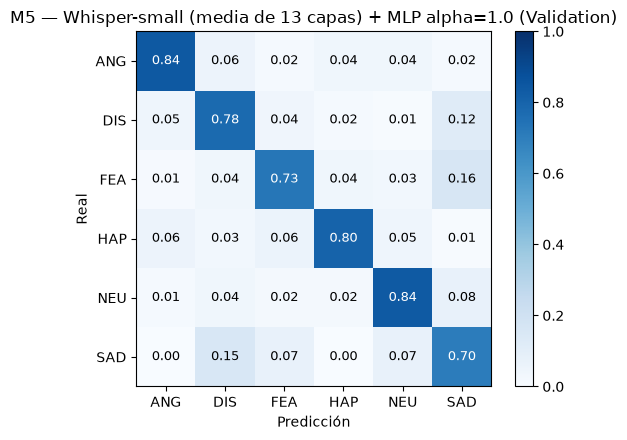

In [211]:
import json, joblib
import matplotlib.pyplot as plt

final_mlp = mlp_by_alpha[BEST_ALPHA]                    # the final M5 classifier (trained once, on train)

# Validation probabilities of the final model: (1148 audios, 6 emotions), each row sums to 1.
val_probs = U.reorder_proba(final_mlp.predict_proba(X_val), final_mlp.classes_)
val_metrics = U.metrics_from_probs(y_val, val_probs)
print({name: round(value, 4) for name, value in val_metrics.items()})

# Rows = true emotion, columns = predicted emotion. Normalized by row: the diagonal is the
# recall of each emotion, and off-diagonal cells show which emotions get confused.
U.plot_confusion_matrix(y_val, val_probs.argmax(axis=1),
                        title=f'M5 — Whisper-small (media de 13 capas) + MLP alpha={BEST_ALPHA} (Validation)')
plt.show()

In [212]:
# Validation probabilities for the ensemble analyses (Soft Voting, LOMO, 26 combinations...).
# save_probs checks: shape (N, 6), rows summing to 1, sample_ids equal to the val partition,
# and labels matching splits.csv. Output: probs/val/probs_val_M5.csv
U.save_probs(splits.loc[val, 'sample_id'], splits.loc[val, 'emotion'], val_probs, 'M5', 'val', splits)

# Everything needed to predict a new audio later without retraining:
# the scaler (train mean/std) and the trained MLP. config.json documents the decisions.
joblib.dump({'scaler': scaler, 'mlp': final_mlp}, M5_MODEL / 'm5.joblib')
config = {'whisper': WHISPER, 'representation': 'mean of the 13 encoder outputs',
          'pooling': 'mean over real (non-padding) frames', 'classifier': f'MLP(256) alpha={BEST_ALPHA}',
          'selection_metric': 'macro_f1 (validation)',
          'val_metrics': {name: round(value, 4) for name, value in val_metrics.items()}}
(M5_MODEL / 'config.json').write_text(json.dumps(config, indent=2, ensure_ascii=False))

config

Guardado c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\probs\val\probs_val_M5.csv  (1148 filas)  acc=0.7805  macro_f1=0.7825


{'whisper': 'openai/whisper-small',
 'representation': 'mean of the 13 encoder outputs',
 'pooling': 'mean over real (non-padding) frames',
 'classifier': 'MLP(256) alpha=1.0',
 'selection_metric': 'macro_f1 (validation)',
 'val_metrics': {'accuracy': 0.7805,
  'macro_precision': 0.7851,
  'macro_recall': 0.7819,
  'macro_f1': 0.7825,
  'weighted_f1': 0.7817}}

### 13.4 Inference on any audio file: `predict_proba_M5`

Takes the path of a `.wav` file and returns 6 probabilities in `CLASSES` order. It applies the same preprocessing as in training: resampling to 16 kHz mono, Whisper encoder, average of the 13 layers, scaler and MLP. It reads the artifacts from `models/M5/`, so it also works from the final sections of this notebook.

In [213]:
from functools import cache


@cache                                     # load the saved artifacts from disk only once
def load_m5_artifacts():
    saved = joblib.load(M5_MODEL / 'm5.joblib')
    return saved['scaler'], saved['mlp']


def predict_proba_M5(wav_path) -> np.ndarray:
    """Any .wav file -> 6 probabilities in CLASSES order. Same pipeline as in training."""
    m5_scaler, m5_mlp = load_m5_artifacts()

    waveform = load_wav(wav_path)                        # file -> (n_samples,) at 16 kHz mono
    layer_summaries = whisper_embed([waveform])[0]       # -> (13, 768): one summary per layer
    # Round to float16 and back exactly like the stored training embeddings, then average
    # the 13 layers -> (768,). This makes a single prediction match the batch results.
    audio_embedding = layer_summaries.astype(np.float16).astype(np.float32).mean(axis=0)

    standardized = m5_scaler.transform(audio_embedding[None])   # (1, 768) with TRAIN mean/std
    probs = m5_mlp.predict_proba(standardized)                  # (1, 6)
    return U.reorder_proba(probs, m5_mlp.classes_)[0]          # (6,) in CLASSES order

**Verification.** The function must (1) give the same result as the batch computation for a Validation audio file and (2) work with audio unlike CREMA-D: here, a synthetic stereo file at 44.1 kHz lasting 8 s.

In [214]:
import tempfile, soundfile as sf

# Check 1: predicting one validation audio alone must give the same result as the batch.
sample_index = 0
sample_path = AUDIO_ROOT / splits.loc[val, 'path'].iloc[sample_index]
single_probs = U.validate_predict_fn(predict_proba_M5, sample_path, 'predict_proba_M5')
assert np.allclose(single_probs, val_probs[sample_index], atol=1e-2), 'La inferencia individual no coincide con la de lote'

# Check 2: an audio unlike CREMA-D -> 8 s, 44.1 kHz, stereo (a 220 Hz tone on both channels).
# load_wav must resample it to 16 kHz and mix it to mono without errors.
odd_sample_rate = 44100
time_axis = np.linspace(0, 8, 8 * odd_sample_rate, endpoint=False)
tone = 0.1 * np.sin(2 * np.pi * 220 * time_axis)
with tempfile.TemporaryDirectory() as tmp_dir:
    odd_wav = Path(tmp_dir) / 'odd.wav'
    sf.write(odd_wav, np.stack([tone, tone], axis=1), odd_sample_rate)
    U.validate_predict_fn(predict_proba_M5, odd_wav, 'audio estéreo 44.1 kHz 8 s')

predict_proba_M5 OK -> ANG  ANG=0.99  DIS=0.00  FEA=0.00  HAP=0.00  NEU=0.00  SAD=0.00
audio estéreo 44.1 kHz 8 s OK -> SAD  ANG=0.30  DIS=0.00  FEA=0.00  HAP=0.00  NEU=0.00  SAD=0.70


### 13.5 Test probabilities (NOT run until the ensemble is frozen)

The function is defined but **not called** here. It will run in Phase 3, after the group freezes the ensemble in `results/frozen_config.json`. In addition, `U.save_probs` refuses to save Test probabilities if that file does not exist.

In [215]:
def generar_probs_test_M5():
    """Test probabilities of M5 -> probs/test/probs_test_M5.csv. Run ONLY after freezing."""
    m5_scaler, m5_mlp = load_m5_artifacts()
    # Reuse the cached test embeddings: same layer average and same TRAIN scaler, nothing is refitted.
    test_embeddings = layer_embeddings[test].astype(np.float32).mean(axis=1)    # (1142, 768)
    X_test = m5_scaler.transform(test_embeddings)
    test_probs = U.reorder_proba(m5_mlp.predict_proba(X_test), m5_mlp.classes_)
    # save_probs refuses to write test probabilities if results/frozen_config.json does not exist.
    return U.save_probs(splits.loc[test, 'sample_id'], splits.loc[test, 'emotion'], test_probs, 'M5', 'test', splits)

# generar_probs_test_M5()   # <- only in Phase 3, after the ensemble is frozen

## 14. Comparison of individual models

Everything in this section uses **Validation only**.

### 14.1 Loading each model's Validation probabilities

Each model saved a `probs/val/probs_val_M{n}.csv` file with its 6 probabilities for each of the 1148 Validation audio files. `U.load_probs` checks the format: columns in `CLASSES` order, rows summing to 1 and no invalid values.

If a model has not uploaded its file yet, a warning is printed and it is skipped; once uploaded, it appears automatically when the notebook is re-run.

It is also checked that **all models describe the same audio files in the same order**: this is required to compare them and, later, to average them row by row in the ensemble.

In [216]:
MODEL_NAMES = ['M1', 'M2', 'M3', 'M4', 'M5']

val_probs_by_model = {}                # model name -> DataFrame (1148 rows: sample_id, true_label, 6 probs)
for model_name in MODEL_NAMES:
    probs_file = U.PROBS_DIR / 'val' / f'probs_val_{model_name}.csv'
    if probs_file.exists():
        val_probs_by_model[model_name] = U.load_probs(model_name, 'val')   # validates the format
    else:
        print(f'{model_name}: todavía no hay probs_val -> se omite por ahora')

# Every model must describe exactly the same audios, in the same order, with the same labels.
reference = next(iter(val_probs_by_model.values()))
for model_name, probs_table in val_probs_by_model.items():
    assert (probs_table['sample_id'].values == reference['sample_id'].values).all(), f'{model_name}: otros audios u otro orden'
    assert (probs_table['true_label'].values == reference['true_label'].values).all(), f'{model_name}: etiquetas distintas'

print('Modelos cargados:', list(val_probs_by_model), '| audios de Validation:', len(reference))

Modelos cargados: ['M1', 'M2', 'M3', 'M4', 'M5'] | audios de Validation: 1148


### 14.2 Description of each model

The "Representation" column of the table, taken from the configuration files uploaded by each member (`models/M{n}/info.json`, `features/M{n}/config.json`, `models/M{n}/m{n}.joblib`).

In [217]:
MODEL_INFO = {
    'M1': {'responsable': 'Steve', 'representacion': 'MFCC + estadísticos (80 dims)',
           'clasificador': 'SVM RBF (C=10, gamma=0.001)'},
    'M2': {'responsable': 'Steve', 'representacion': 'eGeMAPSv02 Functionals (88 dims)',
           'clasificador': 'Random Forest (500 árboles, min_samples_leaf=10)'},
    'M3': {'responsable': 'Felipe', 'representacion': 'WavLM-base-plus, capa 6 (768 dims)',
           'clasificador': 'Regresión logística (C=0.003)'},
    'M4': {'responsable': 'Jhony', 'representacion': 'Log-Mel spectrogram (64 mels, 3 s)',
           'clasificador': 'CNN 2D from scratch (SpecAugment, temperature scaling)'},
    'M5': {'responsable': 'Kevin', 'representacion': 'Whisper-small, promedio de 13 capas (768 dims)',
           'clasificador': 'MLP (256 neuronas, alpha=1.0)'},
}

### 14.3 Metrics of each model on Validation

Metrics are computed **from the probabilities** (`probs_val`), with the same `U.metrics_from_probs` function for every model, instead of being copied from each member's `val_metrics.json`:
- **A single source of truth:** the ensemble will use these same probabilities, so the table and the ensemble cannot contradict each other.
- **The same computation for everyone:** the prediction is the emotion with the highest probability (argmax), and the 5 metrics are computed identically for every model.

Reminder: **Macro** = simple average over the 6 emotions (all weigh the same); **Weighted** = average weighted by the number of audio files of each emotion.

In [218]:
metrics_by_model = {}
for model_name, probs_table in val_probs_by_model.items():
    probs_matrix = probs_table[U.PROB_COLS].values             # (1148, 6), columns in CLASSES order
    # prediction = emotion with the highest probability; then accuracy, macro/weighted metrics
    metrics_by_model[model_name] = U.metrics_from_probs(probs_table['true_label'], probs_matrix)

pd.DataFrame(metrics_by_model).T.round(4)

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
M1,0.5618,0.5609,0.5624,0.5577,0.5581
M2,0.5497,0.5642,0.5533,0.5395,0.5395
M3,0.7413,0.7469,0.7439,0.7423,0.7412
M4,0.6986,0.7005,0.7003,0.6998,0.6988
M5,0.7805,0.7851,0.7819,0.7825,0.7817


### 14.4 Comparison table and `model_results.csv`

The description of each model is joined with its metrics, sorted from best to worst by **Macro F1** (the group's main metric) and saved to `results/model_results.csv`, one of the files required by the assignment.

In [219]:
rows = []
for model_name, metrics in metrics_by_model.items():
    info = MODEL_INFO[model_name]
    rows.append({'modelo': model_name, 'responsable': info['responsable'],
                 'representacion': info['representacion'], 'clasificador': info['clasificador'],
                 **metrics})

model_results = (pd.DataFrame(rows)
                 .sort_values('macro_f1', ascending=False)   # best model first
                 .reset_index(drop=True))
model_results.to_csv(RESULTS_DIR / 'model_results.csv', index=False)

metric_columns = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']
model_results.style.format({column: '{:.4f}' for column in metric_columns}).hide(axis='index')

modelo,responsable,representacion,clasificador,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
M5,Kevin,"Whisper-small, promedio de 13 capas (768 dims)","MLP (256 neuronas, alpha=1.0)",0.7805,0.7851,0.7819,0.7825,0.7817
M3,Felipe,"WavLM-base-plus, capa 6 (768 dims)",Regresión logística (C=0.003),0.7413,0.7469,0.7439,0.7423,0.7412
M4,Jhony,"Log-Mel spectrogram (64 mels, 3 s)","CNN 2D from scratch (SpecAugment, temperature scaling)",0.6986,0.7005,0.7003,0.6998,0.6988
M1,Steve,MFCC + estadísticos (80 dims),"SVM RBF (C=10, gamma=0.001)",0.5618,0.5609,0.5624,0.5577,0.5581
M2,Steve,eGeMAPSv02 Functionals (88 dims),"Random Forest (500 árboles, min_samples_leaf=10)",0.5497,0.5642,0.5533,0.5395,0.5395


### 14.5 Beyond the average: performance per emotion

The previous table summarizes each model in one number and answers **"which model is best on average?"**. For an ensemble, another question matters: **what does each model get right and wrong?** A model that is weak on average can be competitive on some emotion, and if its correct predictions fall on different audio files than those of the strong models, it can correct their errors.

#### 14.5.1 Recall per emotion

For each emotion: of the audio files that **truly** belong to that emotion, what proportion does each model detect? The best model in each column is highlighted.

In [220]:
from sklearn.metrics import confusion_matrix

recall_by_model = {}
for model_name, probs_table in val_probs_by_model.items():
    predicted_labels = U.idx_to_labels(probs_table[U.PROB_COLS].values.argmax(axis=1))   # argmax = prediction
    # Rows = true emotion, columns = predicted emotion, both in CLASSES order.
    counts = confusion_matrix(probs_table['true_label'], predicted_labels, labels=U.CLASSES)
    # Diagonal = correctly detected audios of each emotion; row sum = all audios of that emotion.
    recall_by_model[model_name] = counts.diagonal() / counts.sum(axis=1)

recall_per_emotion = pd.DataFrame(recall_by_model, index=U.CLASSES).T   # rows = models, columns = emotions
recall_per_emotion['macro_recall'] = recall_per_emotion[U.CLASSES].mean(axis=1)   # simple average = Macro

recall_per_emotion.style.format('{:.2f}').highlight_max(axis=0, props='font-weight: bold')

,ANG,DIS,FEA,HAP,NEU,SAD,macro_recall
M1,0.74,0.52,0.42,0.44,0.58,0.67,0.56
M2,0.78,0.38,0.30,0.50,0.70,0.65,0.55
M3,0.79,0.76,0.61,0.74,0.85,0.71,0.74
M4,0.74,0.69,0.62,0.68,0.77,0.69,0.70
M5,0.84,0.78,0.73,0.80,0.84,0.70,0.78


#### 14.5.2 Confusion matrices side by side

Rows = true emotion, columns = predicted emotion, normalized by row: the **diagonal** is the recall of each emotion and the **off-diagonal** cells show what it is confused with. Placing them together shows whether the models make the same mistakes (for example, whether they all confuse FEA with SAD) or different ones.

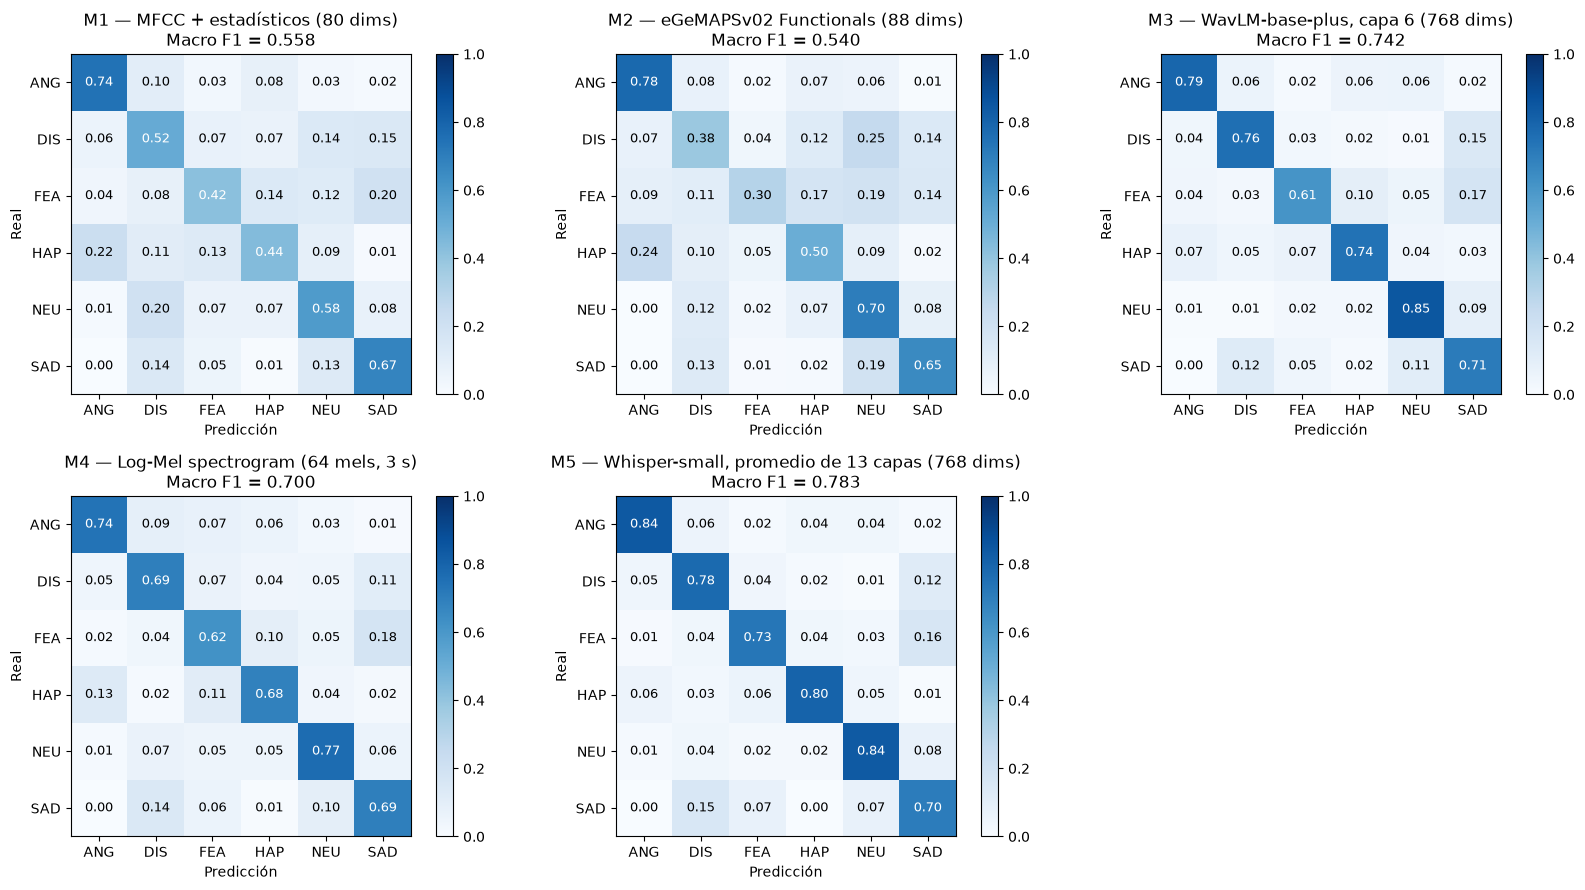

In [221]:
import matplotlib.pyplot as plt

n_models = len(val_probs_by_model)
n_columns = 3
n_rows = int(np.ceil(n_models / n_columns))
figure, axes = plt.subplots(n_rows, n_columns, figsize=(5.5 * n_columns, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, probs_table) in zip(axes, val_probs_by_model.items()):
    predicted_labels = U.idx_to_labels(probs_table[U.PROB_COLS].values.argmax(axis=1))
    title = f"{model_name} — {MODEL_INFO[model_name]['representacion']}\nMacro F1 = {metrics_by_model[model_name]['macro_f1']:.3f}"
    U.plot_confusion_matrix(probs_table['true_label'], predicted_labels, title=title, ax=ax)

for unused_ax in axes[n_models:]:      # hide empty panels (e.g. while M4 is missing)
    unused_ax.axis('off')
plt.tight_layout()
plt.show()

#### 14.5.3 Do the other models recover the errors of the best model?

Recall per emotion tells **how many** audio files each model detects, but not **which ones**. That M1 detects 42% of FEA does not tell whether those are the same files the best model already detects or different ones. For an ensemble, only the **different files** can help.

Here we count, file by file: among the audio files where **the best model fails** (highest Macro F1), how many does each of the other models **get right**? The total and the breakdown by true emotion are shown.

*This is a first look, centered on the best model. The full diversity analysis across all pairs of models is in the correlation and error-diversity sections.*

In [222]:
best_model = max(metrics_by_model, key=lambda model_name: metrics_by_model[model_name]['macro_f1'])
true_labels = reference['true_label'].values

# For every model: True where its prediction (argmax) matches the true emotion, audio by audio.
is_correct_by_model = {
    model_name: U.idx_to_labels(probs_table[U.PROB_COLS].values.argmax(axis=1)) == true_labels
    for model_name, probs_table in val_probs_by_model.items()
}
best_model_fails = ~is_correct_by_model[best_model]          # audios where the best model is wrong

recovery_rows = {f'{best_model} falla (total de errores)': {
    emotion: int((best_model_fails & (true_labels == emotion)).sum()) for emotion in U.CLASSES}}

for model_name, is_correct in is_correct_by_model.items():
    if model_name == best_model:
        continue
    recovered = best_model_fails & is_correct                 # best model wrong AND this model right
    recovery_rows[f'{model_name} acierta donde {best_model} falla'] = {
        emotion: int((recovered & (true_labels == emotion)).sum()) for emotion in U.CLASSES}

recovery_table = pd.DataFrame(recovery_rows).T
recovery_table['total'] = recovery_table[U.CLASSES].sum(axis=1)

# Audios where at least one of the other models gets right what the best model gets wrong.
any_other_correct = np.any([is_correct for model_name, is_correct in is_correct_by_model.items()
                            if model_name != best_model], axis=0)
print(f'Mejor modelo: {best_model} | falla en {best_model_fails.sum()} de {len(true_labels)} audios | '
      f'al menos otro modelo acierta en {(best_model_fails & any_other_correct).sum()} de esos errores')
recovery_table

Mejor modelo: M5 | falla en 252 de 1148 audios | al menos otro modelo acierta en 171 de esos errores


,ANG,DIS,FEA,HAP,NEU,SAD,total
M5 falla (total de errores),31,44,53,39,27,58,252
M1 acierta donde M5 falla,11,10,10,15,15,24,85
M2 acierta donde M5 falla,10,10,12,14,14,29,89
M3 acierta donde M5 falla,8,18,16,18,14,30,104
M4 acierta donde M5 falla,5,16,15,18,11,21,86


### 14.6 Discussion of the individual models

**1. The representation explains most of the difference, in three tiers.** The models built on pretrained embeddings lead (M5, Whisper: Macro F1 0.783; M3, WavLM: 0.742), the CNN that learns its own features from Log-Mel spectrograms is in the middle (M4: 0.700), and the models based on hand-crafted acoustic features are last (M1, MFCC: 0.558; M2, eGeMAPS: 0.540). The order follows how much data shaped each representation: Whisper and WavLM learned from very large amounts of speech, M4 learned from the 5152 Train clips only (63 actors), and MFCC/eGeMAPS are fixed formulas that learn nothing. The classifier seems to matter less than the representation: M3 uses logistic regression, the simplest classifier of the five, and still outperforms M4's CNN and M1's SVM. The difference between M1 and M2 (less than 2 points) is comparable to the sampling noise of a 1148-file set, so their overall performance is considered equivalent. In all five models, Macro F1 and Weighted F1 practically coincide because Validation is almost balanced (168 NEU files versus 196 for each of the other emotions).

**2. Strengths and weaknesses per emotion (sections 14.5.1 and 14.5.2).**
- **M5** is the best or equivalent to the best on every emotion. Its weakest points are SAD (0.70) and FEA (0.73).
- **M3** has a profile similar to M5, somewhat lower overall. On NEU (0.85 vs. 0.84) and SAD (0.71 vs. 0.70) both are equivalent. Its main weakness is FEA (0.61).
- **M4** has the flattest profile of the five: its recall stays between 0.62 (FEA) and 0.77 (NEU). On FEA it is at the level of M3 (0.62 vs. 0.61) despite being 4 points lower overall. Its confusion HAP→ANG (0.13) lies between the hand-crafted models and the embedding models, and it also confuses HAP with FEA (0.11).
- **M1 and M2** are only competitive on ANG (0.74 and 0.78) and get close to the stronger models on SAD (0.67 and 0.65). Their strongest confusion is HAP→ANG (0.22 and 0.24, versus 0.06–0.07 for M3 and M5). This is probably because happiness and anger share high energy and pitch, which is precisely what MFCC and eGeMAPS describe. M2 also tends to predict NEU when uncertain (DIS→NEU 0.25, SAD→NEU 0.19), which raises its NEU recall (0.70) at the expense of DIS (0.38) and FEA (0.30).

**3. Shared and non-shared errors (sections 14.5.2 and 14.5.3).**
- **FEA is the hardest emotion for every model, and all five confuse it with SAD** (between 0.14 and 0.20; 0.18 for M4). This is a shared error: of the 53 FEA files where M5 fails, the other models only get between 10 and 16 right.
- **On SAD, the errors are spread out.** M5 fails on 58 SAD files, its emotion with the most errors, and M1, M2, M3 and M4 get 24, 29, 30 and 21 of them right. Although their SAD recalls are similar (0.65–0.71), the models fail on different files.
- **Overall**, M5 fails on 252 Validation files, and at least one of the other four models gets 171 of them right. M4 alone gets 86 right, a similar amount to M1 (85) and M2 (89) despite being much stronger, and fewer than M3 (104); its recoveries concentrate on SAD (21), HAP (18) and DIS (16).

**4. Implications for the ensemble.** Average performance is not enough to discard models: even the weakest models get part of M5's errors right. The ensemble can be expected to improve on emotions such as SAD, where errors are spread across models, and to improve little on FEA, where the error is shared by all five. At the same time, M5 is right on many files where the weaker models fail, so giving them a high weight could hurt the result. Whether each model's contribution pays off is evaluated in the Weighted Soft Voting, Leave-One-Model-Out and 26-combination sections.

## 15. Storing Validation probabilities

The five `probs/val/probs_val_M{n}.csv` files are loaded into a single array `P` of shape (5 models, 1148 audio files, 6 emotions), after checking that every model describes the same files in the same order. Every ensemble analysis in sections 16–20 works on these stored probabilities: **no model is retrained**. The merged table is saved as `results/validation_probabilities.csv` (`sample_id`, `true_label` and 6 columns per model).

In [223]:
SPLIT = 'val'

def load_all_probs(model_names, split='val'):
    frames = {m: U.load_probs(m, split) for m in model_names}
    base = frames[model_names[0]]
    for m, f in frames.items():
        assert (f['sample_id'].values == base['sample_id'].values).all(), f"{m}: different audios"
    y_true = base['true_label'].values
    P = np.stack([frames[m][U.PROB_COLS].values for m in model_names])   # (M, N, 6)
    return y_true, P

MODELS = ['M1', 'M2', 'M3', 'M4', 'M5']
y_true, P = load_all_probs(MODELS, split=SPLIT)

for i, m in enumerate(MODELS):
    print(m, round(U.metrics_from_probs(y_true, P[i])['macro_f1'], 3))

# All validation probabilities in one table: 6 columns per model
ids = U.load_probs(MODELS[0], SPLIT)['sample_id'].values
val_probs_table = pd.DataFrame({'sample_id': ids, 'true_label': y_true})
for i, m in enumerate(MODELS):
    for j, c in enumerate(U.CLASSES):
        val_probs_table[f'prob_{m}_{c}'] = P[i][:, j]
val_probs_table.to_csv(RESULTS_DIR / 'validation_probabilities.csv', index=False)
print('Saved validation_probabilities.csv', val_probs_table.shape)

M1 0.558
M2 0.54
M3 0.742
M4 0.7
M5 0.783
Saved validation_probabilities.csv (1148, 32)


## 16. Uniform Soft Voting
All the models have the same weight (1/M), so the ensemble probability of each emotion is the simple average of the models' probabilities, and the prediction is the emotion with the highest average. Soft voting uses how confident each model is, not only its vote: a model that is very sure counts more than one that is doubting. The ensemble improves over the best individual model only when the models make mistakes on different audios.

In [224]:
uniform_metrics = U.metrics_from_probs(y_true, P.mean(axis=0))   # simple average of the 5 models
print('Uniform Soft Voting:', {k: round(v, 4) for k, v in uniform_metrics.items()})

Uniform Soft Voting: {'accuracy': 0.7883, 'macro_precision': 0.7922, 'macro_recall': 0.7911, 'macro_f1': 0.7893, 'weighted_f1': 0.7882}


**Results.**

| System | Macro F1 |
|---|---|
| M1 (MFCC + SVM) | 0.558 |
| M2 (eGeMAPS + RF) | 0.540 |
| M3 (WavLM + LR) | 0.742 |
| M4 (Log-Mel + CNN) | 0.700 |
| M5 (Whisper + MLP) | 0.783 |
| Uniform Soft Voting | 0.789 |
| Weighted Soft Voting | 0.813 |

The Uniform Soft Voting barely improves over the best individual model (+0.006), while the Weighted Soft Voting improves by +0.030. With uniform weights, M1 and M2 (Macro F1 around 0.55) together receive 40% of the vote and pull the result down. The weighted search reduced their share to 15% (weights: M1 0.05, M2 0.10, M3 0.40, M4 0.15, M5 0.30).

## 17. Weighted Soft Voting
Each model receives a weight, and the weights sum to 1. We search all the combinations with steps of 0.05 and keep the one with the best Macro F1 on Validation. The weights are chosen only with Validation: in Train, the models that memorize the most would get the highest weights, and using Test would adjust the weights to the exam.

On Validation, the Weighted Soft Voting can never be worse than the Uniform Soft Voting, because the uniform weights (0.2 each) are one of the options of the grid. The search can only find something equal or better. This guarantee does not hold on Test: with more than 10,000 combinations tested on only 14 actors, the selected weights may fit Validation by chance.

In [225]:
from itertools import product

def weight_grid(n_models, step=0.05):
    n_steps = round(1 / step)
    for combo in product(range(n_steps + 1), repeat=n_models - 1):
        rest = n_steps - sum(combo)
        if rest >= 0:                        # the last model gets whatever is left
            yield np.array(combo + (rest,)) / n_steps

In [226]:
def optimize_weights(y_true, P, step=0.05, metric='macro_f1'):
    n_models = P.shape[0]
    best_w, best_score = None, -1
    for w in weight_grid(n_models, step):
        P_ens = np.tensordot(w, P, axes=1)
        score = U.metrics_from_probs(y_true, P_ens)[metric]
        if score > best_score:
            best_w, best_score = w, score
    best_metrics = U.metrics_from_probs(y_true, np.tensordot(best_w, P, axes=1))
    return best_w, best_metrics

In [227]:
best_w, best_metrics = optimize_weights(y_true, P)
print("Weights:", {m:float(round(x,2)) for m, x in zip(MODELS,best_w)})
print("Macro F1:", round(best_metrics['macro_f1'], 3))

Weights: {'M1': 0.05, 'M2': 0.1, 'M3': 0.4, 'M4': 0.15, 'M5': 0.3}
Macro F1: 0.813


In [228]:
for i, m in enumerate(MODELS):
    confidence = P[i].max(axis=1).mean()          # average of the highest probability
    accuracy = U.metrics_from_probs(y_true, P[i])['accuracy']
    print(f"{m}: average confidence = {confidence:.3f}   accuracy = {accuracy:.3f}")

M1: average confidence = 0.521   accuracy = 0.562
M2: average confidence = 0.442   accuracy = 0.550
M3: average confidence = 0.659   accuracy = 0.741
M4: average confidence = 0.689   accuracy = 0.699
M5: average confidence = 0.819   accuracy = 0.780


**Why does M3 get more weight than M5?** M5 (Whisper + MLP) is the best individual model (Macro F1 0.783), but the search gave the highest weight to M3 (WavLM + LR): 0.40 vs 0.30. We compared each model's average confidence (its highest probability) with its accuracy:

| Model | Average confidence | Accuracy |
|---|---|---|
| M1 (MFCC + SVM) | 0.521 | 0.562 |
| M2 (eGeMAPS + RF) | 0.442 | 0.550 |
| M3 (WavLM + LR) | 0.659 | 0.741 |
| M4 (Log-Mel + CNN) | 0.689 | 0.699 |
| M5 (Whisper + MLP) | 0.819 | 0.780 |

M5 is slightly overconfident (its confidence is higher than its accuracy), which is common in MLPs. M3 is the opposite: it is modest, probably because its strong regularization (`C=0.003`) produces moderate probabilities. Since M5's votes are already "loud" and M3's are "quiet", the weighting balances them. Other possible explanations are that M3 makes mistakes on different audios than M5 (complementarity), and chance, since the weights were chosen among more than 10,000 combinations on only 14 actors.

## 18. Leave-One-Model-Out
We evaluate the ensemble with the five models and then removing one model at a time. In each scenario, the weights are optimized again using only Validation.

On Validation, "Without M_n" can never be better than "All", because "Without M_n" is the same as "All" with a weight of 0 for M_n, and that option is already in the grid of the five models. If removing a model improved the result, the search for "All" would find it by itself. Therefore, `delta_macro_f1` is always 0 or negative:

- **Very negative delta:** the model contributes a lot; without it, the ensemble drops.
- **Delta close to 0:** the model contributes almost nothing; the other models cover what it does.
- **A model that harms the ensemble** does not appear as a positive delta, but as a weight close to 0 in the "All" configuration.

**How to read small differences.** Validation has only 14 actors, so the results can change by chance if we used other actors. A very small delta (for example, 0.003) is not enough to say whether a model contributes or not.

**A weak model can be important.** If the model with the worst individual performance has a very negative delta, it means it is **complementary**: it gets right the audios where the other models fail. Its value is not in its individual score, but in what it adds that the others do not have.

In [229]:
configs = [('All', MODELS)] + [(f'Without {m}', [x for x in MODELS if x != m]) for m in MODELS]

lomo_rows = []
for name, subset in configs:
    idx = [MODELS.index(m) for m in subset]
    w, met = optimize_weights(y_true, P[idx])
    lomo_rows.append({
        'configuration': name,
        'models': ' + '.join(subset),
        'weights': str({m: float(round(x, 2)) for m, x in zip(subset, w)}),
        **met,
    })

lomo_df = pd.DataFrame(lomo_rows)
lomo_df['delta_macro_f1'] = lomo_df['macro_f1'] - lomo_df.loc[0, 'macro_f1']
display(lomo_df.round(3))

,configuration,models,weights,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,delta_macro_f1
0,All,M1 + M2 + M3 + M4 + M5,"{'M1': 0.05, 'M2': 0.1, 'M3': 0.4, 'M4': 0.15,...",0.812,0.815,0.814,0.813,0.812,0.000
1,Without M1,M2 + M3 + M4 + M5,"{'M2': 0.05, 'M3': 0.45, 'M4': 0.15, 'M5': 0.35}",0.811,0.815,0.813,0.812,0.812,-0.001
2,Without M2,M1 + M3 + M4 + M5,"{'M1': 0.25, 'M3': 0.35, 'M4': 0.2, 'M5': 0.2}",0.812,0.815,0.814,0.813,0.812,-0.000
3,Without M3,M1 + M2 + M4 + M5,"{'M1': 0.05, 'M2': 0.25, 'M4': 0.25, 'M5': 0.45}",0.800,0.804,0.802,0.801,0.800,-0.012
4,Without M4,M1 + M2 + M3 + M5,"{'M1': 0.1, 'M2': 0.1, 'M3': 0.45, 'M5': 0.35}",0.806,0.809,0.808,0.807,0.806,-0.006
5,Without M5,M1 + M2 + M3 + M4,"{'M1': 0.05, 'M2': 0.1, 'M3': 0.55, 'M4': 0.3}",0.787,0.792,0.789,0.787,0.786,-0.026


**Results.**

| Configuration | Macro F1 | Delta |
|---|---|---|
| All | 0.813 | — |
| Without M1 (MFCC + SVM) | 0.812 | −0.001 |
| Without M2 (eGeMAPS + RF) | 0.813 | −0.000 |
| Without M3 (WavLM + LR) | 0.801 | −0.012 |
| Without M4 (Log-Mel + CNN) | 0.807 | −0.006 |
| Without M5 (Whisper + MLP) | 0.787 | −0.026 |

M5 contributes the most to the ensemble, followed by M3 and M4. Removing M1 or M2 does not change the result: the differences are much smaller than what chance can produce with 14 validation actors.

This does not mean M1 and M2 are bad models, but that they are **redundant** in this ensemble. Their representations are weaker for emotion: MFCC were designed for speech recognition and smooth out details of the pitch, and eGeMAPS summarizes the whole audio with global statistics, losing how the voice changes over time. What they capture (energy, timbre, part of the pitch) is already captured, and better, by the learned representations (WavLM, Whisper and the CNN on Log-Mel). When M1 or M2 get an audio right, the other models usually got it right too, so they add no new information. The three models that do contribute (M3, M4 and M5) are precisely the ones with learned representations.

## 19. The 26 possible combinations
We generate all the combinations of 2 to 5 models automatically with `itertools.combinations` (10 + 10 + 5 + 1 = 26), and for each one we optimize the weights again using only Validation.

On Validation, no combination of 2, 3 or 4 models can be better than the five models, because the five-model grid already includes giving a weight of 0 to any model. The five models are the ceiling. So the question is not which combination wins, but whether a smaller ensemble gets a similar result.

**Selection criterion.** If the difference between a smaller ensemble and a larger one is very small (smaller than what chance can change with only 14 validation actors), we prefer the smaller one: it runs fewer models when predicting a new audio, and it has fewer weights to adjust, so there is less risk that the weights fit Validation by chance.

In [230]:
from itertools import combinations
import pandas as pd

all_subsets = [list(c) for k in range(2, 6) for c in combinations(MODELS, k)]
total = len(all_subsets)
print(f"Number of combinations: {total}")

combo_rows = []
for i, subset in enumerate(all_subsets, 1):
    idx = [MODELS.index(m) for m in subset]
    w, met = optimize_weights(y_true, P[idx])
    combo_rows.append({
        'n_models': len(subset),
        'models': ' + '.join(subset),
        'weights': str({m: float(round(x, 2)) for m, x in zip(subset, w)}),
        **met,
    })
    print(f"\rProgreso: {i}/{total} ({i/total*100:.1f}%)", end='', flush=True)

print()  # salto de línea final

combos_df = (pd.DataFrame(combo_rows)
             .sort_values(['n_models', 'macro_f1'], ascending=[True, False])
             .reset_index(drop=True))

best_by_size = combos_df.loc[combos_df.groupby('n_models')['macro_f1'].idxmax()]
best_global = combos_df.loc[combos_df['macro_f1'].idxmax()]
print(best_global)

Number of combinations: 26
Progreso: 26/26 (100.0%)
n_models                                                           5
models                                        M1 + M2 + M3 + M4 + M5
weights            {'M1': 0.05, 'M2': 0.1, 'M3': 0.4, 'M4': 0.15,...
accuracy                                                    0.811847
macro_precision                                             0.815371
macro_recall                                                0.814059
macro_f1                                                    0.813248
weighted_f1                                                 0.812314
Name: 25, dtype: object


## 20. Best combination by number of models

In [231]:
display(best_by_size.round(3))

,n_models,models,weights,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,2,M3 + M5,"{'M3': 0.55, 'M5': 0.45}",0.801,0.805,0.803,0.803,0.802
10,3,M3 + M4 + M5,"{'M3': 0.45, 'M4': 0.35, 'M5': 0.2}",0.811,0.815,0.813,0.812,0.811
20,4,M1 + M3 + M4 + M5,"{'M1': 0.25, 'M3': 0.35, 'M4': 0.2, 'M5': 0.2}",0.812,0.815,0.814,0.813,0.812
25,5,M1 + M2 + M3 + M4 + M5,"{'M1': 0.05, 'M2': 0.1, 'M3': 0.4, 'M4': 0.15,...",0.812,0.815,0.814,0.813,0.812


**Results.**

| Size | Best combination | Weights | Macro F1 |
|---|---|---|---|
| 2 | M3 + M5 | 0.55 / 0.45 | 0.803 |
| 3 | M3 + M4 + M5 | 0.45 / 0.35 / 0.20 | 0.812 |
| 4 | M1 + M3 + M4 + M5 | 0.25 / 0.35 / 0.20 / 0.20 | 0.813 |
| 5 | All | 0.05 / 0.10 / 0.40 / 0.15 / 0.30 | 0.813 |

**Proposed final ensemble: M3 + M4 + M5.** It gets a Macro F1 of 0.812, only 0.001 below the four- and five-model ensembles, a difference much smaller than what chance can produce with 14 validation actors. This agrees with the Leave-One-Model-Out analysis: M1 and M2 are redundant, so removing them costs nothing. A smaller ensemble also has fewer weights to adjust (3 instead of 5), so there is less risk that the weights fit Validation by chance, and it runs fewer models when predicting a new audio. Going down to two models does have a cost (0.803), so three models is the point where adding more no longer helps. The three selected models are the ones with learned representations (WavLM, Log-Mel CNN and Whisper).

**Final choice of the group.** On accuracy alone, three models is the point where adding more no longer helps, as proposed above. The group finally chose the **best 2-model ensemble (M3 + M5, Macro F1 0.803)** for production efficiency: fewer pipelines to deploy and maintain and less inference time, at a cost of about 1 point on Validation. The decision and its justification are recorded in section 23.

### 20.1 Saving the ensemble results

In [232]:
if SPLIT == 'val' and len(MODELS) == 5:
    # (validation_probabilities.csv is saved in section 15)

    # 2. Uniform and Weighted with the 5 models
    uniform_df = pd.DataFrame([{
        'system': 'Uniform Soft Voting', 'models': ' + '.join(MODELS),
        'weights': str({m: 0.2 for m in MODELS}),
        **U.metrics_from_probs(y_true, P.mean(axis=0)),
    }])
    weighted_df = lomo_df.iloc[[0]].assign(system='Weighted Soft Voting')
    uniform_df.to_csv(RESULTS_DIR / 'uniform_soft_voting.csv', index=False)
    weighted_df.to_csv(RESULTS_DIR / 'weighted_soft_voting.csv', index=False)

    # 3. LOMO and combinations
    lomo_df.to_csv(RESULTS_DIR / 'leave_one_model_out.csv', index=False)
    combos_df.to_csv(RESULTS_DIR / 'all_model_combinations.csv', index=False)
    best_by_size.to_csv(RESULTS_DIR / 'best_combination_by_size.csv', index=False)
    print("Saved 5 files in", RESULTS_DIR)
else:
    print("Simulated data: nothing saved.")

Saved 5 files in c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\results


## 21. Probability correlation

**Owner:** Person C. Everything in sections 21 and 22 uses **only the stored Validation probabilities** (`P`, shape 5 models × 1148 files × 6 emotions, loaded in section 15). No model is retrained and Test is not used.

**Why correlation?** Soft Voting averages probabilities. If two models produce almost the same probabilities, averaging them adds little: the ensemble only improves when models disagree in useful ways. The correlation matrix is a first measure of how similar the models are.

**Three ways of measuring it.**
| Method | How | What it captures | Limitation |
|---|---|---|---|
| **Flattened** (main, required) | Each model's (1148 × 6) matrix is flattened into one vector of 6888 values; Pearson correlation between models | Overall similarity of the probabilities | Inflated: every decent model puts high probability on the true class, so two models are correlated even if they make **different** errors |
| **Per class** | Correlation of the column of each emotion, then averaged over the 6 emotions | Whether models rank files the same way for each emotion | Same inflation, emotion by emotion |
| **Residual** | Correlation of the errors `P_m − one_hot(y)` | Whether models are wrong **in the same way** (both too low on the true class, both too high on the same wrong class) | Needs the labels (fine: Validation labels are allowed) |

This is why the assignment says correlation is not enough: high probability correlation is expected even between complementary models. The residual correlation and the error-diversity analysis of section 22 separate "agree because both are right" from "agree because both are wrong in the same way".

### 21.1 Analysis functions and a test with simulated probabilities
The functions are written once and reused. Before applying them to the real models, they are checked on **simulated probabilities** (Dirichlet noise plus extra mass on the true class), where the expected answer is known:
- a model and an exact copy of itself → correlation 1, 0 % disagreement;
- two independent models of the same quality → positive correlation (both favor the true class) but many disagreements.

In [233]:
from itertools import combinations
from IPython.display import Markdown
from scipy.stats import spearmanr

# Representation family of each model (used in section 22.4)
REPRESENTATION_FAMILY = {'M1': 'hand-crafted descriptors', 'M2': 'hand-crafted descriptors',
                         'M3': 'pretrained embeddings', 'M5': 'pretrained embeddings',
                         'M4': 'spectrogram learned by a CNN'}


def probability_correlation(P, model_names):
    # Pearson correlation between models after flattening each (N, 6) matrix into one vector.
    flat = P.reshape(P.shape[0], -1)                                  # (M, N*6)
    return pd.DataFrame(np.corrcoef(flat), index=model_names, columns=model_names)


def per_class_correlation(P, model_names):
    # Correlation of each emotion column between models, averaged over the 6 emotions.
    mats = [np.corrcoef(P[:, :, c]) for c in range(P.shape[2])]
    return pd.DataFrame(np.mean(mats, axis=0), index=model_names, columns=model_names)


def residual_correlation(P, y_idx, model_names):
    # Correlation of the probability errors P_m - one_hot(y): are the models wrong in the same way?
    one_hot = np.eye(P.shape[2])[y_idx]                               # (N, 6)
    residuals = (P - one_hot[None]).reshape(P.shape[0], -1)           # (M, N*6)
    return pd.DataFrame(np.corrcoef(residuals), index=model_names, columns=model_names)


def pairwise_error_diversity(P, y_idx, model_names):
    # For every pair of models: the 4 outcomes (both right / only A / only B / both wrong) and diversity measures.
    pred = P.argmax(axis=2)                                           # (M, N) predicted class
    correct = pred == y_idx[None]                                     # (M, N) True where the model is right
    n = len(y_idx)
    rows = []
    for a, b in combinations(range(len(model_names)), 2):
        ca, cb = correct[a], correct[b]
        n11, n10 = int((ca & cb).sum()), int((ca & ~cb).sum())        # both right / A right, B wrong
        n01, n00 = int((~ca & cb).sum()), int((~ca & ~cb).sum())      # A wrong, B right / both wrong
        denom = n11 * n00 + n01 * n10
        rows.append({
            'model_a': model_names[a], 'model_b': model_names[b],
            'pair': f'{model_names[a]} + {model_names[b]}',
            'accuracy_a': ca.mean(), 'accuracy_b': cb.mean(),
            'both_correct': n11, 'a_correct_b_wrong': n10, 'a_wrong_b_correct': n01, 'both_wrong': n00,
            'pct_both_correct': 100 * n11 / n, 'pct_a_correct_b_wrong': 100 * n10 / n,
            'pct_a_wrong_b_correct': 100 * n01 / n, 'pct_both_wrong': 100 * n00 / n,
            # % of files where the two models predict a different emotion (the assignment's disagreement)
            'prediction_disagreement_pct': 100 * (pred[a] != pred[b]).mean(),
            # % of files where exactly one of the two is right (Kuncheva's disagreement measure)
            'correctness_disagreement_pct': 100 * (n10 + n01) / n,
            'double_fault_pct': 100 * n00 / n,                        # both wrong: errors no vote can fix
            'yule_q': (n11 * n00 - n01 * n10) / denom if denom else np.nan,   # +1 same errors, 0 independent, <0 complementary
            'oracle_accuracy': (n - n00) / n,                         # at least one of the two is right
        })
    return pd.DataFrame(rows)


def pair_matrix(diversity, column, model_names, diagonal=np.nan):
    # Turn one column of the pairwise table into a symmetric (M, M) matrix for heatmaps.
    mat = pd.DataFrame(diagonal, index=model_names, columns=model_names, dtype=float)
    for _, r in diversity.iterrows():
        mat.loc[r['model_a'], r['model_b']] = mat.loc[r['model_b'], r['model_a']] = r[column]
    return mat


def plot_matrix(ax, mat, title, fmt='{:.2f}', cmap='viridis', vmin=None, vmax=None):
    # Annotated heatmap with matplotlib only (no extra dependency).
    values = mat.values.astype(float)
    im = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(mat.columns)), mat.columns)
    ax.set_yticks(range(len(mat.index)), mat.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                r, g, b, _ = im.cmap(im.norm(values[i, j]))          # cell color -> readable text color
                ax.text(j, i, fmt.format(values[i, j]), ha='center', va='center', fontsize=9,
                        color='black' if 0.299 * r + 0.587 * g + 0.114 * b > 0.5 else 'white')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)


def upper_pairs(mat, name):
    # Off-diagonal values of a symmetric matrix as a (pair -> value) column.
    return pd.DataFrame([{'pair': f'{a} + {b}', name: mat.loc[a, b]}
                         for a, b in combinations(mat.index, 2)]).set_index('pair')

In [234]:
# Test of the functions with simulated probabilities (the expected answer is known)
rng = np.random.default_rng(U.SEED)
N_SIM = 1000
y_sim = rng.integers(0, 6, N_SIM)

def simulated_model(skill):
    # Random Dirichlet probabilities plus `skill` extra mass on the true class: higher skill -> more accurate.
    p = rng.dirichlet(np.ones(6), size=N_SIM)
    p[np.arange(N_SIM), y_sim] += skill
    return p / p.sum(axis=1, keepdims=True)

sim_a = simulated_model(0.5)
P_sim = np.stack([sim_a, sim_a.copy(), simulated_model(0.5)])     # A, an exact copy of A, an independent model
sim_names = ['A', 'A_copy', 'B_indep']

sim_corr = probability_correlation(P_sim, sim_names)
sim_div = pairwise_error_diversity(P_sim, y_sim, sim_names).set_index('pair')

assert np.isclose(sim_corr.loc['A', 'A_copy'], 1.0)
assert sim_div.loc['A + A_copy', 'prediction_disagreement_pct'] == 0
assert sim_div.loc['A + A_copy', 'a_correct_b_wrong'] == sim_div.loc['A + A_copy', 'a_wrong_b_correct'] == 0
outcome_cols = ['both_correct', 'a_correct_b_wrong', 'a_wrong_b_correct', 'both_wrong']
assert (sim_div[outcome_cols].sum(axis=1) == N_SIM).all()          # the 4 outcomes cover every file once

display(sim_corr.round(3))
display(sim_div[['accuracy_a', 'accuracy_b', 'prediction_disagreement_pct', 'yule_q']].round(3))
print('OK: the functions behave as expected on simulated data.')

,A,A_copy,B_indep
A,1.000,1.000,0.632
A_copy,1.000,1.000,0.632
B_indep,0.632,0.632,1.000


,accuracy_a,accuracy_b,prediction_disagreement_pct,yule_q
pair,,,,
A + A_copy,0.911,0.911,0.0,1.00
A + B_indep,0.911,0.915,16.3,0.17
A_copy + B_indep,0.911,0.915,16.3,0.17


OK: the functions behave as expected on simulated data.


The independent model `B_indep` has a clearly **positive** probability correlation with `A`, even though its errors are unrelated (Yule's Q close to 0). This is the inflation described above, and the reason section 22 is needed.

### 21.2 Correlation of the five models

In [235]:
y_idx = U.labels_to_idx(y_true)                     # true labels as indices in CLASSES order
assert P.shape == (len(MODELS), len(y_idx), len(U.CLASSES))

corr_flat = probability_correlation(P, MODELS)        # required matrix
corr_class = per_class_correlation(P, MODELS)
corr_resid = residual_correlation(P, y_idx, MODELS)

# Required file: the 5x5 flattened correlation matrix
corr_flat.round(4).to_csv(RESULTS_DIR / 'probability_correlation.csv')
# Extra file: the three methods together, for reproducibility
pd.concat({'flattened': corr_flat, 'per_class_mean': corr_class, 'residual': corr_resid}
          ).round(4).to_csv(RESULTS_DIR / 'probability_correlation_all_methods.csv')
print('Saved probability_correlation.csv and probability_correlation_all_methods.csv')
display(corr_flat.round(3))

Saved probability_correlation.csv and probability_correlation_all_methods.csv


,M1,M2,M3,M4,M5
M1,1.000,0.771,0.669,0.730,0.633
M2,0.771,1.000,0.633,0.672,0.584
M3,0.669,0.633,1.000,0.777,0.841
M4,0.730,0.672,0.777,1.000,0.788
M5,0.633,0.584,0.841,0.788,1.000


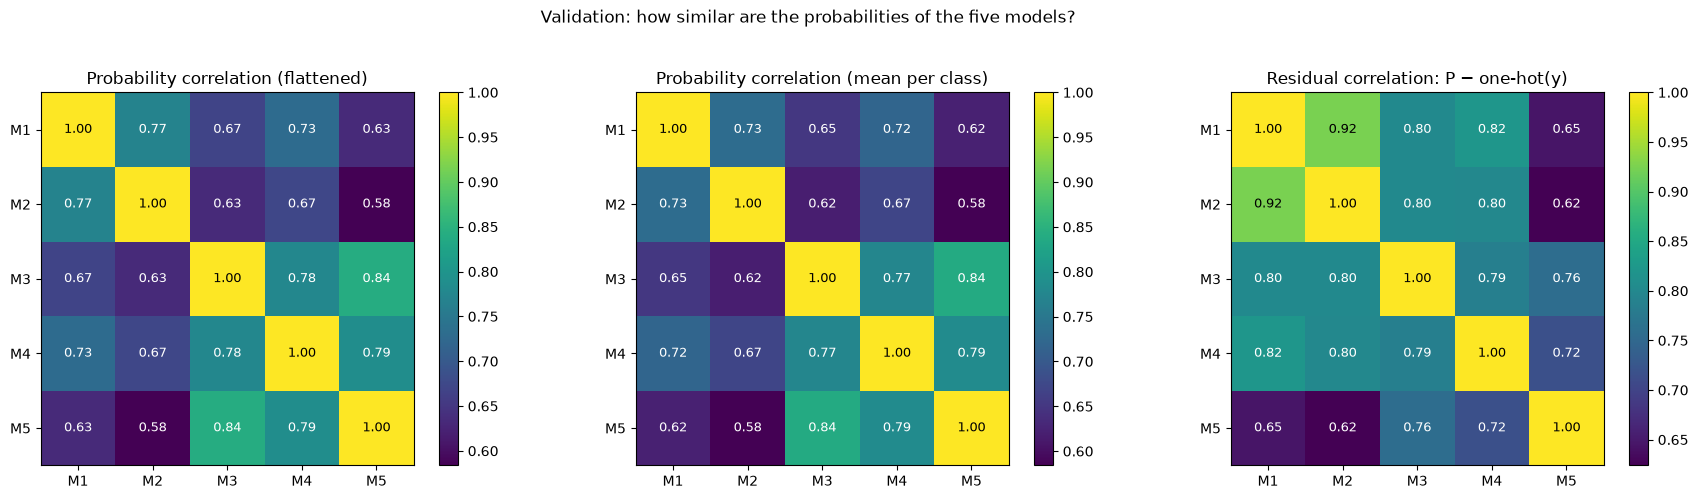

,flattened,per_class_mean,residual
pair,,,
M3 + M5,0.841,0.838,0.758
M4 + M5,0.788,0.785,0.716
M3 + M4,0.777,0.774,0.787
M1 + M2,0.771,0.732,0.925
M1 + M4,0.730,0.719,0.822
M2 + M4,0.672,0.671,0.799
M1 + M3,0.669,0.651,0.803
M1 + M5,0.633,0.623,0.645
M2 + M3,0.633,0.619,0.803


In [236]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plot_matrix(axes[0], corr_flat, 'Probability correlation (flattened)')
plot_matrix(axes[1], corr_class, 'Probability correlation (mean per class)')
plot_matrix(axes[2], corr_resid, 'Residual correlation: P − one-hot(y)')
plt.suptitle('Validation: how similar are the probabilities of the five models?', y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'probability_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# The 10 pairs, from most to least similar (flattened correlation)
pair_corr = pd.concat([upper_pairs(corr_flat, 'flattened'), upper_pairs(corr_class, 'per_class_mean'),
                       upper_pairs(corr_resid, 'residual')], axis=1).sort_values('flattened', ascending=False)
display(pair_corr.round(3))

**How to read these matrices.** Values close to 1 mean the two models produce almost the same probabilities; lower values mean more different outputs, which is what an ensemble needs. Compare the left and right panels: the flattened correlation is high for every pair because all models favor the true class, while the **residual** correlation keeps only the part where models are wrong together, so it separates the pairs more clearly. The pairs with the lowest residual correlation are the best candidates to complement each other. The automatic summary in section 22.5 names the most and least similar pairs.

## 22. Error diversity

**Owner:** Person C. Correlation looks at probabilities; here we look at **decisions**. For every pair of models (A, B) and every Validation file, there are four possible outcomes:

| | B right | B wrong |
|---|---|---|
| **A right** | both right (`both_correct`) | A corrects B (`a_correct_b_wrong`) |
| **A wrong** | B corrects A (`a_wrong_b_correct`) | both wrong (`both_wrong`) |

From these counts we compute:
- **Prediction disagreement (%)**: files where A and B predict a different emotion (the measure requested by the assignment).
- **Correctness disagreement (%)**: files where exactly one of the two is right. Only these files can be fixed by combining the pair.
- **Double fault (%)**: files where both are wrong. Ensembles of that pair can rarely fix them.
- **Yule's Q** (from −1 to +1): +1 = the models fail on exactly the same files, 0 = independent errors, negative = they fail on different files. Unlike the disagreement, Q is less affected by how accurate each model is, so it allows a fairer comparison between strong and weak pairs.
- **Oracle accuracy**: proportion of files where at least one of the two is right, the upper limit any combination of the pair could reach.

### 22.1 Pairwise table (`error_diversity.csv`)

In [237]:
diversity = pairwise_error_diversity(P, y_idx, MODELS)
diversity.round(4).to_csv(RESULTS_DIR / 'error_diversity.csv', index=False)
print('Saved error_diversity.csv', diversity.shape)

show_cols = ['pair', 'both_correct', 'a_correct_b_wrong', 'a_wrong_b_correct', 'both_wrong',
             'prediction_disagreement_pct', 'correctness_disagreement_pct', 'double_fault_pct',
             'yule_q', 'oracle_accuracy']
display(diversity[show_cols].sort_values('yule_q').round(3).reset_index(drop=True))

Saved error_diversity.csv (10, 18)


,pair,both_correct,a_correct_b_wrong,a_wrong_b_correct,both_wrong,prediction_disagreement_pct,correctness_disagreement_pct,double_fault_pct,yule_q,oracle_accuracy
0,M2 + M5,542,89,354,163,45.906,38.589,14.199,0.474,0.858
1,M1 + M5,560,85,336,167,42.596,36.672,14.547,0.532,0.855
2,M1 + M3,545,100,306,197,43.206,35.366,17.160,0.556,0.828
3,M2 + M3,539,92,312,205,43.815,35.192,17.857,0.588,0.821
4,M3 + M4,670,181,132,165,32.230,27.265,14.373,0.645,0.856
5,M1 + M4,545,100,257,246,39.460,31.098,21.429,0.678,0.786
6,M2 + M4,538,93,264,253,39.983,31.098,22.038,0.694,0.780
7,M3 + M5,747,104,149,148,25.000,22.038,12.892,0.754,0.871
8,M1 + M2,486,159,145,358,37.369,26.481,31.185,0.766,0.688
9,M4 + M5,716,86,180,166,27.787,23.171,14.460,0.770,0.855


### 22.2 Visualizations
The stacked bars show, for every pair, how the 1148 Validation files are distributed among the four outcomes. The green part is where the pair already agrees and is right; the two middle parts are the files an ensemble of the pair *could* fix; the red part (both wrong) is out of reach for that pair.

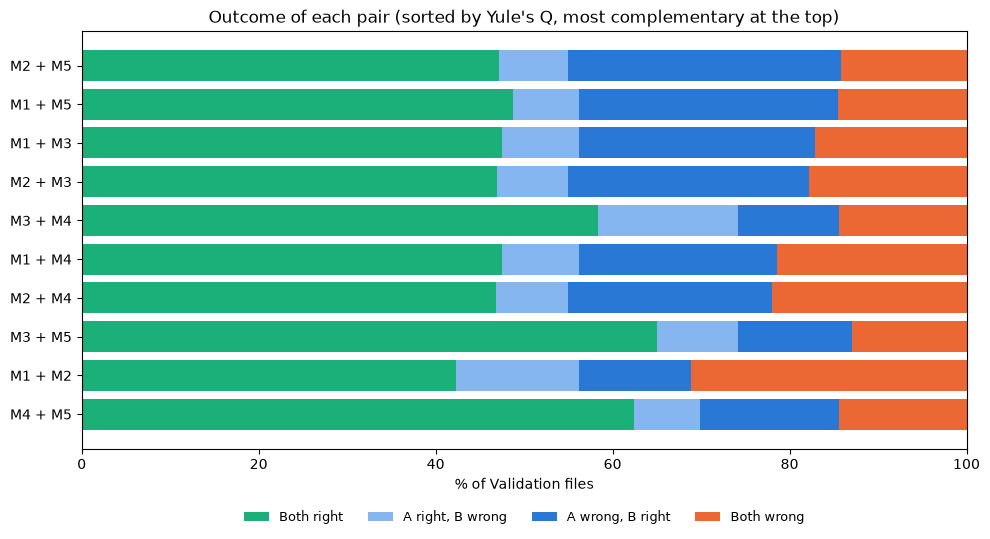

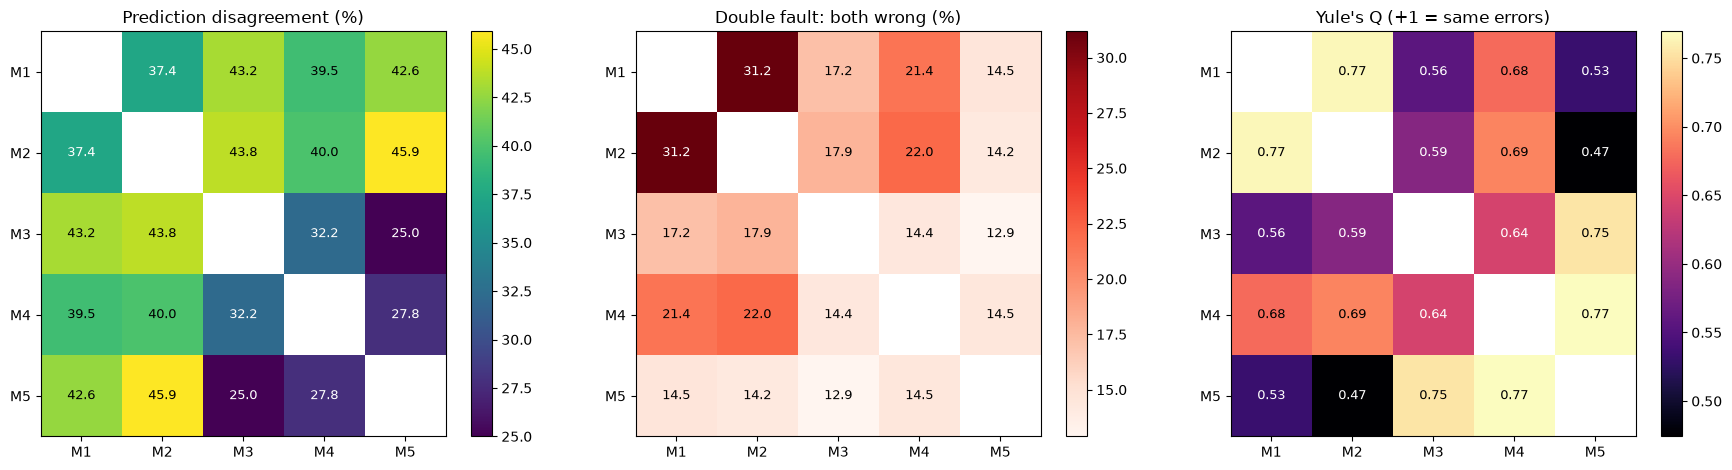

In [238]:
order = diversity.sort_values('yule_q')['pair'].tolist()          # most complementary pair at the top
stack = diversity.set_index('pair').loc[order, ['pct_both_correct', 'pct_a_correct_b_wrong',
                                                 'pct_a_wrong_b_correct', 'pct_both_wrong']]
fig, ax = plt.subplots(figsize=(10, 5.5))
left = np.zeros(len(stack))
for col, color, label in zip(stack.columns, ['#1baf7a', '#86b6ef', '#2a78d6', '#eb6834'],
                             ['Both right', 'A right, B wrong', 'A wrong, B right', 'Both wrong']):
    ax.barh(stack.index, stack[col], left=left, color=color, label=label)
    left += stack[col].values
ax.invert_yaxis()
ax.set_xlabel('% of Validation files'); ax.set_xlim(0, 100)
ax.set_title("Outcome of each pair (sorted by Yule's Q, most complementary at the top)")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_diversity_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plot_matrix(axes[0], pair_matrix(diversity, 'prediction_disagreement_pct', MODELS), 'Prediction disagreement (%)', fmt='{:.1f}')
plot_matrix(axes[1], pair_matrix(diversity, 'double_fault_pct', MODELS), 'Double fault: both wrong (%)', fmt='{:.1f}', cmap='Reds')
plot_matrix(axes[2], pair_matrix(diversity, 'yule_q', MODELS), "Yule's Q (+1 = same errors)", cmap='magma')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_diversity_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 22.3 Does a weaker model correct a stronger one?
Cell (row R, column C) = number of Validation files where **model R is right and model C is wrong**. Models are sorted from strongest to weakest (Macro F1), so the cells **below the diagonal** are the cases where a *weaker* model corrects a *stronger* one. The second table shows the same counts as a percentage of the column model's errors.

Macro F1: {'M5': 0.783, 'M3': 0.742, 'M4': 0.7, 'M1': 0.558, 'M2': 0.54}
Errors per model: {'M5': 252, 'M3': 297, 'M4': 346, 'M1': 503, 'M2': 517}


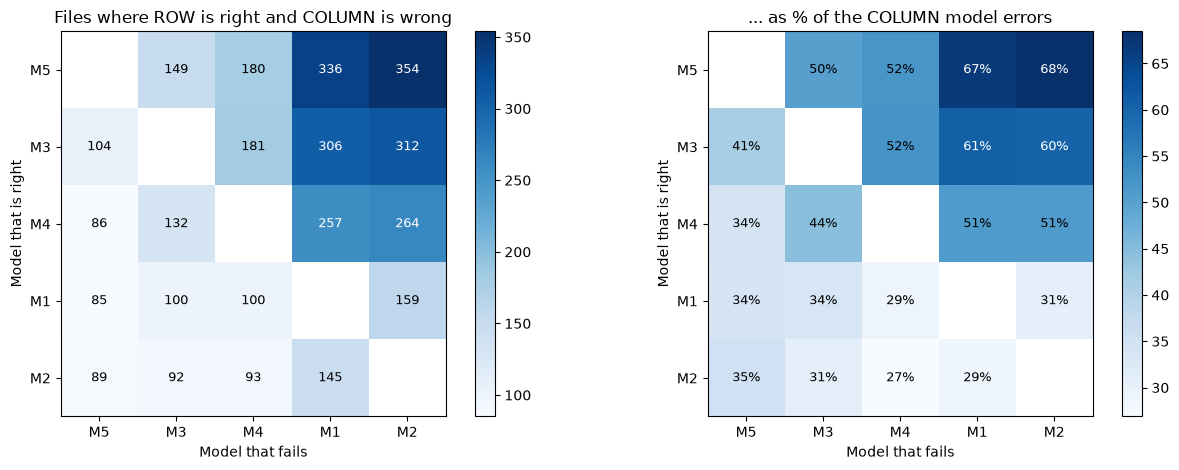

In [239]:
individual_f1 = {m: U.metrics_from_probs(y_true, P[i])['macro_f1'] for i, m in enumerate(MODELS)}
by_strength = sorted(MODELS, key=individual_f1.get, reverse=True)       # strongest first

correct = P.argmax(axis=2) == y_idx[None]                               # (M, N)
pos = {m: i for i, m in enumerate(MODELS)}
fixes = pd.DataFrame([[int((correct[pos[r]] & ~correct[pos[c]]).sum()) if r != c else np.nan
                       for c in by_strength] for r in by_strength], index=by_strength, columns=by_strength)
errors = pd.Series({m: int((~correct[pos[m]]).sum()) for m in by_strength})
fixes_pct = 100 * fixes / errors[by_strength].values[None, :]

print('Macro F1:', {m: round(individual_f1[m], 3) for m in by_strength})
print('Errors per model:', errors.to_dict())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_matrix(axes[0], fixes, 'Files where ROW is right and COLUMN is wrong', fmt='{:.0f}', cmap='Blues')
plot_matrix(axes[1], fixes_pct, '... as % of the COLUMN model errors', fmt='{:.0f}%', cmap='Blues')
for ax in axes:
    ax.set_xlabel('Model that fails'); ax.set_ylabel('Model that is right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_corrections_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 22.4 Do different audio representations produce different errors?
Each pair is labeled as **same family** (both hand-crafted descriptors: M1 + M2; both pretrained embeddings: M3 + M5) or **different family**. Caveat: accuracy is a confounder, because two weak models disagree more simply because they make more errors. That is why Yule's Q and the residual correlation (less dependent on accuracy) are reported next to the disagreement, and why the comparison between **strong** pairs (M3 + M5 against M3 + M4 and M4 + M5) is the most informative.

In [240]:
diversity['family_a'] = diversity['model_a'].map(REPRESENTATION_FAMILY)
diversity['family_b'] = diversity['model_b'].map(REPRESENTATION_FAMILY)
diversity['pair_type'] = np.where(diversity['family_a'] == diversity['family_b'], 'same family', 'different family')
diversity['residual_corr'] = [corr_resid.loc[a, b] for a, b in zip(diversity['model_a'], diversity['model_b'])]

family_cols = ['pair', 'pair_type', 'prediction_disagreement_pct', 'yule_q', 'residual_corr', 'oracle_accuracy']
display(diversity[family_cols].sort_values(['pair_type', 'yule_q']).round(3).reset_index(drop=True))
display(diversity.groupby('pair_type')[['prediction_disagreement_pct', 'yule_q', 'residual_corr']].mean().round(3))

strong_pairs = ['M3 + M5', 'M3 + M4', 'M4 + M5']
print('Strong pairs only (similar accuracy level):')
display(diversity.set_index('pair').loc[strong_pairs, ['pair_type', 'prediction_disagreement_pct',
                                                        'yule_q', 'residual_corr', 'oracle_accuracy']].round(3))

,pair,pair_type,prediction_disagreement_pct,yule_q,residual_corr,oracle_accuracy
0,M2 + M5,different family,45.906,0.474,0.624,0.858
1,M1 + M5,different family,42.596,0.532,0.645,0.855
2,M1 + M3,different family,43.206,0.556,0.803,0.828
3,M2 + M3,different family,43.815,0.588,0.803,0.821
4,M3 + M4,different family,32.230,0.645,0.787,0.856
5,M1 + M4,different family,39.460,0.678,0.822,0.786
6,M2 + M4,different family,39.983,0.694,0.799,0.780
7,M4 + M5,different family,27.787,0.770,0.716,0.855
8,M3 + M5,same family,25.000,0.754,0.758,0.871
9,M1 + M2,same family,37.369,0.766,0.925,0.688


,prediction_disagreement_pct,yule_q,residual_corr
pair_type,,,
different family,39.373,0.617,0.750
same family,31.185,0.760,0.841


Strong pairs only (similar accuracy level):


,pair_type,prediction_disagreement_pct,yule_q,residual_corr,oracle_accuracy
pair,,,,,
M3 + M5,same family,25.000,0.754,0.758,0.871
M3 + M4,different family,32.230,0.645,0.787,0.856
M4 + M5,different family,27.787,0.770,0.716,0.855


### 22.5 Does diversity explain the ensemble improvement?
Two links with the results of sections 18–19 (read from memory or, if the notebook is run from here, from the saved CSV files):
1. **Pairs:** for each 2-model ensemble, the **gain** = its Macro F1 (weights optimized on Validation, section 19) minus the Macro F1 of its best member. If diversity helps, more complementary pairs (lower Yule's Q / residual correlation) should gain more.
2. **Models:** each model's Leave-One-Model-Out loss (section 18) and its weight in the 5-model ensemble, next to how different it is, on average, from the other four.

With only 10 pairs and 14 Validation actors, these relations are descriptive, not statistical proof.

,pair,weights,pair_macro_f1,best_member_f1,gain,yule_q,residual_corr
0,M3 + M4,"{'M3': 0.6, 'M4': 0.4}",0.782,0.742,0.040,0.645,0.787
1,M1 + M2,"{'M1': 0.55, 'M2': 0.45}",0.582,0.558,0.024,0.766,0.925
2,M3 + M5,"{'M3': 0.55, 'M5': 0.45}",0.803,0.783,0.020,0.754,0.758
3,M4 + M5,"{'M4': 0.45, 'M5': 0.55}",0.797,0.783,0.014,0.770,0.716
4,M2 + M5,"{'M2': 0.5, 'M5': 0.5}",0.794,0.783,0.012,0.474,0.624
5,M1 + M3,"{'M1': 0.2, 'M3': 0.8}",0.754,0.742,0.012,0.556,0.803
6,M2 + M3,"{'M2': 0.4, 'M3': 0.6}",0.752,0.742,0.009,0.588,0.803
7,M2 + M4,"{'M2': 0.4, 'M4': 0.6}",0.708,0.700,0.008,0.694,0.799
8,M1 + M5,"{'M1': 0.3, 'M5': 0.7}",0.790,0.783,0.007,0.532,0.645
9,M1 + M4,"{'M1': 0.05, 'M4': 0.95}",0.703,0.700,0.004,0.678,0.822


Spearman(Yule's Q, gain) = 0.37 (p = 0.293) | Spearman(residual corr, gain) = -0.07 (p = 0.855)


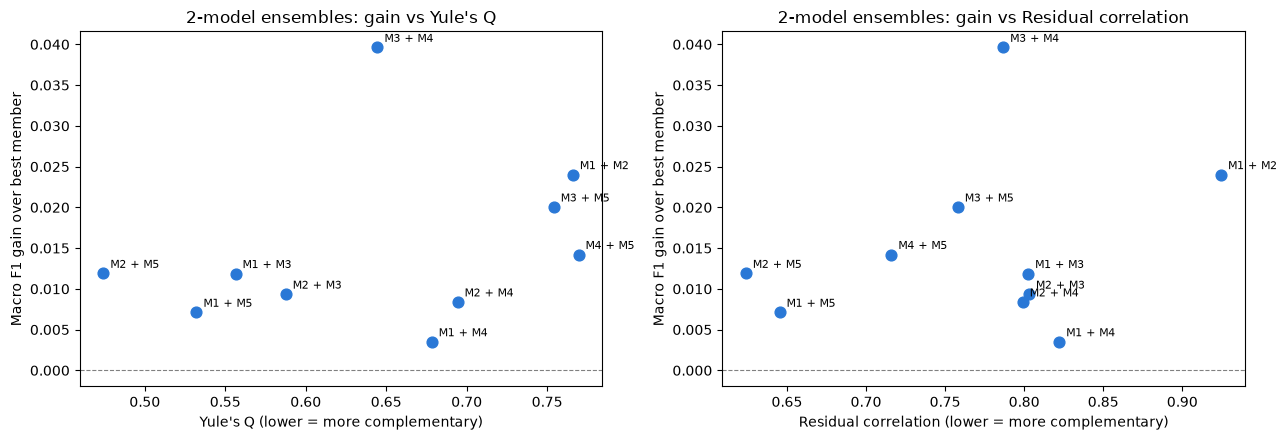

,macro_f1,weight_5_models,lomo_delta_macro_f1,mean_yule_q_with_others,mean_residual_corr_with_others,files_fixed_for_best_model
M1,0.558,0.05,-0.001,0.633,0.799,85.0
M2,0.540,0.10,-0.000,0.631,0.788,89.0
M3,0.742,0.40,-0.012,0.636,0.788,104.0
M4,0.700,0.15,-0.006,0.697,0.781,86.0
M5,0.783,0.30,-0.026,0.633,0.686,NaN


In [241]:
import ast

# Ensemble results from sections 18-19 (re-read from disk if this section is run on its own)
combos = combos_df if 'combos_df' in globals() else pd.read_csv(RESULTS_DIR / 'all_model_combinations.csv')
lomo = lomo_df if 'lomo_df' in globals() else pd.read_csv(RESULTS_DIR / 'leave_one_model_out.csv')

# 1) Pairs: ensemble gain over the best member vs diversity
pairs = combos[combos['n_models'] == 2][['models', 'weights', 'macro_f1']].rename(
    columns={'models': 'pair', 'macro_f1': 'pair_macro_f1'})
pairs = pairs.merge(diversity[['pair', 'model_a', 'model_b', 'yule_q', 'residual_corr',
                               'prediction_disagreement_pct', 'oracle_accuracy']], on='pair')
pairs['best_member_f1'] = [max(individual_f1[a], individual_f1[b]) for a, b in zip(pairs['model_a'], pairs['model_b'])]
pairs['gain'] = pairs['pair_macro_f1'] - pairs['best_member_f1']
display(pairs[['pair', 'weights', 'pair_macro_f1', 'best_member_f1', 'gain', 'yule_q', 'residual_corr']]
        .sort_values('gain', ascending=False).round(3).reset_index(drop=True))

rho_q, p_q = spearmanr(pairs['yule_q'], pairs['gain'])
rho_r, p_r = spearmanr(pairs['residual_corr'], pairs['gain'])
print(f"Spearman(Yule's Q, gain) = {rho_q:.2f} (p = {p_q:.3f}) | Spearman(residual corr, gain) = {rho_r:.2f} (p = {p_r:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, label in zip(axes, ['yule_q', 'residual_corr'], ["Yule's Q", 'Residual correlation']):
    ax.scatter(pairs[col], pairs['gain'], s=60, color='#2a78d6')
    for _, r in pairs.iterrows():
        ax.annotate(r['pair'], (r[col], r['gain']), textcoords='offset points', xytext=(5, 4), fontsize=8)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel(f'{label} (lower = more complementary)'); ax.set_ylabel('Macro F1 gain over best member')
    ax.set_title(f'2-model ensembles: gain vs {label}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'diversity_vs_ensemble_gain.png', dpi=150, bbox_inches='tight')
plt.show()

# 2) Models: LOMO contribution and 5-model weight vs average diversity with the other four
five_weights = ast.literal_eval(lomo.loc[lomo['configuration'] == 'All', 'weights'].iloc[0])
per_model = pd.DataFrame({
    'macro_f1': pd.Series(individual_f1),
    'weight_5_models': pd.Series(five_weights),
    'lomo_delta_macro_f1': lomo.set_index('configuration')['delta_macro_f1']
                               .rename(lambda c: c.replace('Without ', '')).reindex(MODELS),
    'mean_yule_q_with_others': pd.Series({m: pair_matrix(diversity, 'yule_q', MODELS).loc[m].mean() for m in MODELS}),
    'mean_residual_corr_with_others': pd.Series({m: corr_resid.loc[m].drop(m).mean() for m in MODELS}),
    'files_fixed_for_best_model': pd.Series({m: (fixes.loc[m, by_strength[0]] if m != by_strength[0] else np.nan)
                                             for m in MODELS}),
}).loc[MODELS]
display(per_model.round(3))

### 22.6 Automatic summary of the findings
The following text is **generated from the numbers above**, so it always matches the current results.

In [242]:
def fmt_pair(row, col, f='{:.3f}'):
    return f"**{row['pair']}** ({f.format(row[col])})"

d = diversity.copy()
q_sorted = d.sort_values('yule_q')
most_similar_q, most_compl_q = q_sorted.iloc[-1], q_sorted.iloc[0]
res_sorted = d.sort_values('residual_corr')
most_similar_res, least_similar_res = res_sorted.iloc[-1], res_sorted.iloc[0]
flat_pairs = upper_pairs(corr_flat, 'flattened').sort_values('flattened')
best_oracle = d.sort_values('oracle_accuracy').iloc[-1]
same_mean = d.groupby('pair_type')[['yule_q', 'residual_corr', 'prediction_disagreement_pct']].mean()

strongest = by_strength[0]
fix_lines = '; '.join(f"{m} fixes {int(fixes.loc[m, strongest])} ({fixes_pct.loc[m, strongest]:.0f}%)"
                      for m in by_strength[1:])
best_gain = pairs.sort_values('gain').iloc[-1]

summary = f'''
**1. Which models make similar errors?** The highest Yule's Q is {fmt_pair(most_similar_q, 'yule_q')} and the highest
residual correlation is {fmt_pair(most_similar_res, 'residual_corr')}: these models tend to fail on the same files.
By flattened probability correlation, the most similar pair is **{flat_pairs.index[-1]}** ({flat_pairs.iloc[-1, 0]:.3f})
and the least similar is **{flat_pairs.index[0]}** ({flat_pairs.iloc[0, 0]:.3f}).

**2. Which models are most complementary?** The lowest Yule's Q is {fmt_pair(most_compl_q, 'yule_q')} and the lowest
residual correlation is {fmt_pair(least_similar_res, 'residual_corr')}. The pair with the highest oracle accuracy
(at least one of the two right) is {fmt_pair(best_oracle, 'oracle_accuracy')}.

**3. Does a weaker model correct a stronger one?** {'Yes' if fixes[strongest].drop(strongest).sum() > 0 else 'No'}. The strongest model, {strongest}, makes {int(errors[strongest])}
errors on Validation; among them: {fix_lines}.

**4. Different representations, different errors?** Mean Yule's Q: same family = {same_mean.loc['same family', 'yule_q']:.3f},
different family = {same_mean.loc['different family', 'yule_q']:.3f}. Mean residual correlation: same family =
{same_mean.loc['same family', 'residual_corr']:.3f}, different family = {same_mean.loc['different family', 'residual_corr']:.3f}.

**5. Does diversity explain the ensemble gain?** The 2-model ensemble with the largest gain over its best member is
**{best_gain['pair']}** (+{best_gain['gain']:.3f} Macro F1). Across the 10 pairs, Spearman(Yule's Q, gain) = {rho_q:.2f}
and Spearman(residual correlation, gain) = {rho_r:.2f} (negative = more complementary pairs gain more).
'''
display(Markdown(summary))


**1. Which models make similar errors?** The highest Yule's Q is **M4 + M5** (0.770) and the highest
residual correlation is **M1 + M2** (0.925): these models tend to fail on the same files.
By flattened probability correlation, the most similar pair is **M3 + M5** (0.841)
and the least similar is **M2 + M5** (0.584).

**2. Which models are most complementary?** The lowest Yule's Q is **M2 + M5** (0.474) and the lowest
residual correlation is **M2 + M5** (0.624). The pair with the highest oracle accuracy
(at least one of the two right) is **M3 + M5** (0.871).

**3. Does a weaker model correct a stronger one?** Yes. The strongest model, M5, makes 252
errors on Validation; among them: M3 fixes 104 (41%); M4 fixes 86 (34%); M1 fixes 85 (34%); M2 fixes 89 (35%).

**4. Different representations, different errors?** Mean Yule's Q: same family = 0.760,
different family = 0.617. Mean residual correlation: same family =
0.841, different family = 0.750.

**5. Does diversity explain the ensemble gain?** The 2-model ensemble with the largest gain over its best member is
**M3 + M4** (+0.040 Macro F1). Across the 10 pairs, Spearman(Yule's Q, gain) = 0.37
and Spearman(residual correlation, gain) = -0.07 (negative = more complementary pairs gain more).


### 22.7 Discussion

**Probability correlation alone is misleading.** The simulation in 21.1 showed that two models with *independent* errors still have a clearly positive probability correlation, because both put most of their probability on the true class. For the real models, compare the flattened and the residual panels of 21.2: the residual correlation, Yule's Q and the four-outcome counts are the measures that separate "agree because both are right" from "agree because both are wrong". Conclusions about complementarity are therefore based on section 22, not on the raw correlation alone.

**Similar and complementary errors.** The automatic summary (22.6) names the pairs that fail on the same files and the most complementary ones. Two caveats when reading them: the disagreement and the double fault depend on accuracy (weak pairs disagree more because they simply err more), so Yule's Q and the residual correlation are the fairer measures; and the FEA → SAD confusion is shared by all five models (section 14.5), so part of the double fault is an error that no combination of these models can fix.

**Weak models do correct strong ones, but that is not enough.** Every model, including M1 and M2, gets right some files where the strongest model fails (22.3; section 14.5.3 already showed that M1–M4 recover between 85 and 104 of M5's 252 errors). Whether this helps depends on how many of the strong model's correct answers the weak model would *break* when given weight. Leave-One-Model-Out shows the net effect: removing M1 or M2 costs nothing (−0.001 and −0.000), while removing M4 costs −0.006, M3 −0.012 and M5 −0.026. M1 and M2 fix some errors, but the stronger models already cover what they add.

**Representation and diversity.** The table in 22.4 compares pairs of the same family with pairs of different families. The most relevant comparison is between strong models: M3 and M5 are both pretrained transformers, while M4 learns its own features from the spectrogram. The ensemble results point in the same direction: in the best 3-model ensemble (M3 + M4 + M5) M4 receives a weight of 0.35, higher than M5 (0.20), even though M4 is the weakest of the three individually; the weight search rewards the model that brings different information, not only the most accurate one.

**Does diversity explain the gain?** Section 22.5 relates each pair's gain to its diversity, and each model's LOMO contribution to its average difference with the others. A useful model for the ensemble needs **both** reasonable accuracy and errors that differ from the other members: M1 and M2 fix some of the strong models' errors but are too weak, so giving them weight breaks almost as many correct answers as it fixes (their LOMO deltas are ≈ 0); M4 combines medium accuracy with a different representation, which is why it is the third most useful model. With only 14 Validation actors, these differences (a few thousandths of Macro F1) are small, so they support the group's decision (section 23) to prefer a small ensemble: the M3 + M5 pair captures most of the gain, and M4 is the natural third member if more accuracy were needed.

## 23. Selection of the final ensemble

**Freezing** = writing down, **before touching Test**, every ensemble decision: which models are included, with which weights, which strategy, and the criterion used to choose them. It is saved to `results/frozen_config.json`. From that moment on:
- models, weights and configurations no longer change;
- `U.save_probs` allows Test probabilities to be generated (before, it blocks them);
- §24 (Test) and §25 (new audio) read the decisions from that file instead of writing them by hand.

**Decision of the group:** Weighted Soft Voting with **M3 + M5** (weights 0.55 / 0.45), the best 2-model combination on Validation (Macro F1 0.8026).

**Why not the best ensemble on Validation?** Section 20 shows that adding M4 (0.8121) or using all five models (0.8132) scores about 1 point more, a gain comparable to the sampling noise of 14 Validation actors. The group prioritized **production efficiency**: every additional model is one more pipeline to deploy and maintain (M4 needs its own Log-Mel preprocessing, normalization statistics, temperature and checkpoint) and adds inference time. Two models was judged the best balance between accuracy and operational cost. The full justification is recorded with the decision below.

In [243]:
def combine_probs(probs_by_model, weights):
    """Weighted Soft Voting: P_ensemble = sum over models of weight_m * P_m.

    probs_by_model: model name -> probabilities in CLASSES order, (N, 6) for many audios or (6,) for one.
    weights: model name -> weight; weights are >= 0 and sum to 1 (uniform voting = all weights equal).
    """
    return sum(weight * np.asarray(probs_by_model[model_name]) for model_name, weight in weights.items())

In [244]:
# ------------------------------------------------------------------------------------------
# DECISION OF THE GROUP (taken on Validation results only, from B's all_model_combinations.csv)
# ------------------------------------------------------------------------------------------
ENSEMBLE_DECISION = {
    'strategy': 'weighted_soft_voting',
    'weights': {'M3': 0.55, 'M5': 0.45},        # best 2-model combination (grid search, step 0.05)
    'selection_metric': 'macro_f1 (validation)',
    'justification': (
        'Production efficiency. M3 (WavLM + logistic regression) and M5 (Whisper + MLP) are the best '
        '2-model combination on Validation (Macro F1 0.8026). The best 3-model ensemble (adding M4) reaches '
        '0.8121 and all 5 models 0.8132: about 1 point more, comparable to the sampling noise of 1148 '
        'Validation files. Each extra model is a separate pipeline to deploy and maintain (M4 needs its own '
        'Log-Mel preprocessing, normalization statistics, temperature and PyTorch checkpoint) and adds '
        'inference time, so the group chose two models and accepted the ~1-point cost. Leave-One-Model-Out '
        'shows that M1 and M2 contribute less than 0.1 point. Both chosen models rely on different '
        'pretrained representations (self-supervised WavLM and supervised Whisper).'
    ),
}
FREEZE_NOW = True       # FROZEN: the decision above is final (results/frozen_config.json)

ensemble_weights = ENSEMBLE_DECISION['weights']

# Sanity checks: every model has validation probabilities, weights are valid.
missing_models = set(ensemble_weights) - set(val_probs_by_model)
assert not missing_models, f'No probs_val for: {missing_models}'
assert all(weight >= 0 for weight in ensemble_weights.values()), 'Negative weights'
assert np.isclose(sum(ensemble_weights.values()), 1.0), 'Weights must sum to 1'

# Validation metrics of the chosen ensemble, recomputed here from the same probs_val
# (they should match the value reported by B for this combination).
val_matrices = {model_name: val_probs_by_model[model_name][U.PROB_COLS].values for model_name in ensemble_weights}
ensemble_val_probs = combine_probs(val_matrices, ensemble_weights)                 # (1148, 6)
ensemble_val_metrics = U.metrics_from_probs(true_labels, ensemble_val_probs)
print('Ensemble:', ensemble_weights)
print('Validation:', {name: round(value, 4) for name, value in ensemble_val_metrics.items()})

Ensemble: {'M3': 0.55, 'M5': 0.45}
Validation: {'accuracy': 0.8014, 'macro_precision': 0.8048, 'macro_recall': 0.8033, 'macro_f1': 0.8026, 'weighted_f1': 0.8018}


In [245]:
import json
from datetime import datetime

frozen_config = {
    **ENSEMBLE_DECISION,
    'models': sorted(ensemble_weights),
    'val_metrics': {name: round(value, 4) for name, value in ensemble_val_metrics.items()},
    'frozen_at': datetime.now().isoformat(timespec='seconds'),
}

if FREEZE_NOW:
    if U.FROZEN_CONFIG_PATH.exists():
        # Already frozen (e.g. the notebook is being re-run): the file is never overwritten.
        already_frozen = json.loads(U.FROZEN_CONFIG_PATH.read_text())
        same_decision = all(already_frozen[key] == frozen_config[key] for key in ('strategy', 'weights', 'models'))
        if not same_decision:
            raise RuntimeError('frozen_config.json already exists with a DIFFERENT decision: '
                               'the ensemble cannot change after freezing.')
        frozen_config = already_frozen
        print('Ensemble already frozen at', frozen_config['frozen_at'], '-> same decision, file kept as is.')
    else:
        U.FROZEN_CONFIG_PATH.write_text(json.dumps(frozen_config, indent=2, ensure_ascii=False))
        print('Ensemble FROZEN in', U.FROZEN_CONFIG_PATH.name)
else:
    print('Preview (FREEZE_NOW = False): frozen_config.json is NOT written.')
frozen_config

Ensemble already frozen at 2026-10-05T23:43:45 -> same decision, file kept as is.


{'strategy': 'weighted_soft_voting',
 'weights': {'M3': 0.55, 'M5': 0.45},
 'selection_metric': 'macro_f1 (validation)',
 'justification': 'Production efficiency. M3 (WavLM + logistic regression) and M5 (Whisper + MLP) are the best 2-model combination on Validation (Macro F1 0.8026). The best 3-model ensemble (adding M4) reaches 0.8121 and all 5 models 0.8132: about 1 point more, comparable to the sampling noise of 1148 Validation files. Each extra model is a separate pipeline to deploy and maintain (M4 needs its own Log-Mel preprocessing, normalization statistics, temperature and PyTorch checkpoint) and adds inference time, so the group chose two models and accepted the ~1-point cost. Leave-One-Model-Out shows that M1 and M2 contribute less than 0.1 point. Both chosen models rely on different pretrained representations (self-supervised WavLM and supervised Whisper).',
 'models': ['M3', 'M5'],
 'val_metrics': {'accuracy': 0.8014,
  'macro_precision': 0.8048,
  'macro_recall': 0.8033,
 

## 24. Final evaluation on Test

Once the final ensemble has been selected and **frozen** (section 23), it is evaluated **a single time** on Test. This score is the honest estimate of how the system performs on new speakers: no decision was taken by looking at these audio files.

Test is **not** used afterwards to modify:
- the weights;
- the combination of models;
- the hyperparameters;
- the architecture;
- the preprocessing;
- any other experimental decision.

**Procedure:**
1. Read the frozen decisions from `results/frozen_config.json` (models, weights, strategy).
2. Generate the Test probabilities of each model in the ensemble with its `generar_probs_test_M{n}()` function. The models are **not retrained**: the trained artifacts only predict the Test audio files.
3. Combine them with the **same frozen weights** (`combine_probs`, section 23). Nothing is optimized here.
4. Report the final metrics and the confusion matrix.
5. Save `results/final_test_results.csv` and `results/final_comparison.csv`.

**Safeguards:**
- Every cell of this section does nothing until `frozen_config.json` exists, so the notebook can run end to end before freezing.
- Test probabilities are generated only if they do not exist yet (they are never regenerated).
- `final_test_results.csv` records which frozen configuration it belongs to; if the configuration changes after the Test evaluation, the notebook stops with an error.

### 24.1 Frozen configuration

In [246]:
from datetime import datetime

FINAL_TEST_RESULTS_PATH = RESULTS_DIR / 'final_test_results.csv'
FINAL_COMPARISON_PATH = RESULTS_DIR / 'final_comparison.csv'

# Section 24 only runs once the ensemble is frozen.
TEST_READY = U.FROZEN_CONFIG_PATH.exists()
if TEST_READY:
    final_config = json.loads(U.FROZEN_CONFIG_PATH.read_text())
    final_weights = final_config['weights']                 # model name -> frozen weight
    print('Frozen ensemble:', final_weights)
    print('Strategy:', final_config['strategy'], '| frozen at:', final_config['frozen_at'])
else:
    print('The ensemble is not frozen yet (results/frozen_config.json does not exist): section 24 is skipped.')

Frozen ensemble: {'M3': 0.55, 'M5': 0.45}
Strategy: weighted_soft_voting | frozen at: 2026-10-05T23:43:45


### 24.2 Test probabilities of each model in the ensemble

Each model's `generar_probs_test_M{n}()` was defined in its own section. It loads the trained artifacts and the cached Test features, predicts, and saves `probs/test/probs_test_M{n}.csv` through `U.save_probs`, which refuses to write Test probabilities if the ensemble is not frozen.

In [247]:
# Model name -> function that generates its Test probabilities (defined in sections 9, 10 and 13).
TEST_PROB_GENERATORS = {'M1': generar_probs_test_M1, 'M2': generar_probs_test_M2, 'M3': generar_probs_test_M3,
                        'M4': generar_probs_test_M4, 'M5': generar_probs_test_M5}

if TEST_READY:
    for model_name in final_weights:
        test_probs_file = U.PROBS_DIR / 'test' / f'probs_test_{model_name}.csv'
        if test_probs_file.exists():
            print(f'{model_name}: Test probabilities already exist -> reused, not regenerated')
        elif model_name in TEST_PROB_GENERATORS:
            TEST_PROB_GENERATORS[model_name]()
        else:
            raise RuntimeError(f'{model_name} is in the frozen ensemble but generar_probs_test_{model_name} is not available')

M3: Test probabilities already exist -> reused, not regenerated
M5: Test probabilities already exist -> reused, not regenerated


### 24.3 Final metrics and confusion matrix

The ensemble Test probabilities are the weighted average of the models' Test probabilities, with the frozen weights. The Validation metrics recorded at freezing time are shown next to the Test metrics: a moderate drop is expected, because every decision was chosen as the best on Validation, which makes its Validation score somewhat optimistic.

,Validation (at freezing),Test (final)
accuracy,0.8014,0.7548
macro_precision,0.8048,0.7630
macro_recall,0.8033,0.7570
macro_f1,0.8026,0.7582
weighted_f1,0.8018,0.7567


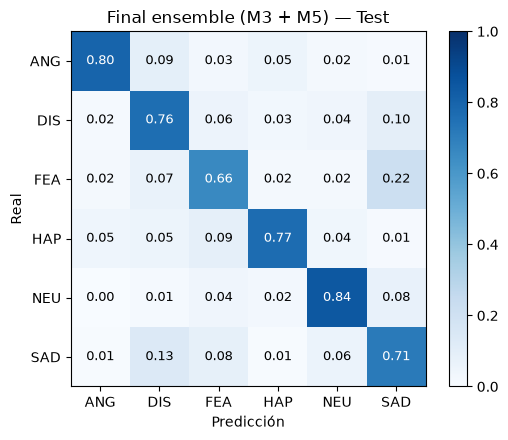

In [248]:
if TEST_READY:
    test_probs_by_model = {model_name: U.load_probs(model_name, 'test') for model_name in final_weights}

    # Every model must describe exactly the Test audio files, in the same order, with the same labels.
    test_reference = next(iter(test_probs_by_model.values()))
    assert set(test_reference['sample_id']) == set(U.get_split(splits, 'test')['sample_id']), 'Not the Test partition'
    for model_name, test_table in test_probs_by_model.items():
        assert (test_table['sample_id'].values == test_reference['sample_id'].values).all(), f'{model_name}: other files or order'
        assert (test_table['true_label'].values == test_reference['true_label'].values).all(), f'{model_name}: different labels'
    test_true_labels = test_reference['true_label'].values

    # Weighted Soft Voting with the FROZEN weights: nothing is fitted or optimized on Test.
    test_matrices = {model_name: test_table[U.PROB_COLS].values for model_name, test_table in test_probs_by_model.items()}
    ensemble_test_probs = combine_probs(test_matrices, final_weights)                 # (1142, 6)
    ensemble_test_metrics = U.metrics_from_probs(test_true_labels, ensemble_test_probs)

    display(pd.DataFrame({'Validation (at freezing)': final_config['val_metrics'],
                          'Test (final)': ensemble_test_metrics}).round(4))

    U.plot_confusion_matrix(test_true_labels, ensemble_test_probs.argmax(axis=1),
                            title=f"Final ensemble ({' + '.join(sorted(final_weights))}) — Test")
    plt.show()

### 24.4 Saving `final_test_results.csv`

The Test result is saved together with the frozen configuration it belongs to. If the file already exists, it is **not** overwritten: the notebook checks that it belongs to the same frozen configuration and that re-running gives the same score (the computation is deterministic).

In [249]:
if TEST_READY:
    final_test_results = pd.DataFrame([{
        'system': 'Final ensemble',
        'strategy': final_config['strategy'],
        'models': ' + '.join(sorted(final_weights)),
        'weights': json.dumps(final_weights),
        'frozen_at': final_config['frozen_at'],
        'evaluated_at': datetime.now().isoformat(timespec='seconds'),
        **ensemble_test_metrics,
    }])

    if FINAL_TEST_RESULTS_PATH.exists():
        recorded = pd.read_csv(FINAL_TEST_RESULTS_PATH)
        assert recorded['frozen_at'].iloc[0] == final_config['frozen_at'], \
            'final_test_results.csv belongs to another frozen configuration: Test was already used.'
        assert np.isclose(recorded['macro_f1'].iloc[0], ensemble_test_metrics['macro_f1']), \
            'Same frozen configuration but a different Test score: something changed after freezing.'
        print('Test evaluation already recorded for this frozen configuration -> file kept as is.')
    else:
        final_test_results.to_csv(FINAL_TEST_RESULTS_PATH, index=False)
        print('Saved', FINAL_TEST_RESULTS_PATH.name)
    display(final_test_results)

Test evaluation already recorded for this frozen configuration -> file kept as is.


,system,strategy,models,weights,frozen_at,evaluated_at,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Final ensemble,weighted_soft_voting,M3 + M5,"{""M3"": 0.55, ""M5"": 0.45}",2026-10-05T23:43:45,2026-10-07T11:42:36,0.754816,0.763041,0.756958,0.758243,0.756676


### 24.5 Final comparison (`final_comparison.csv`)

Validation and Test metrics of each individual model and of the final ensemble. The individual Test scores are reported **for reference only**, after freezing: no decision is taken from them.

*Rows for Uniform Soft Voting, Weighted Soft Voting with 5 models and the best combinations of 2, 3 and 4 models (Validation) are added from sections 16–20 when they are complete.*

In [250]:
if TEST_READY:
    comparison_rows = []
    for model_name in MODEL_NAMES:
        test_probs_file = U.PROBS_DIR / 'test' / f'probs_test_{model_name}.csv'
        if model_name not in metrics_by_model or not test_probs_file.exists():
            continue                                    # model without validation or test probabilities
        test_table = U.load_probs(model_name, 'test')
        model_test_metrics = U.metrics_from_probs(test_table['true_label'], test_table[U.PROB_COLS].values)
        comparison_rows.append({'system': model_name,
                                **{f'val_{name}': value for name, value in metrics_by_model[model_name].items()},
                                **{f'test_{name}': value for name, value in model_test_metrics.items()}})

    comparison_rows.append({'system': f"Final ensemble ({' + '.join(sorted(final_weights))})",
                            **{f'val_{name}': value for name, value in final_config['val_metrics'].items()},
                            **{f'test_{name}': value for name, value in ensemble_test_metrics.items()}})

    final_comparison = pd.DataFrame(comparison_rows)
    final_comparison['macro_f1_drop'] = final_comparison['val_macro_f1'] - final_comparison['test_macro_f1']
    final_comparison.to_csv(FINAL_COMPARISON_PATH, index=False)
    display(final_comparison[['system', 'val_macro_f1', 'test_macro_f1', 'macro_f1_drop',
                              'test_accuracy', 'test_weighted_f1']].round(4))

,system,val_macro_f1,test_macro_f1,macro_f1_drop,test_accuracy,test_weighted_f1
0,M3,0.7423,0.7128,0.0295,0.7084,0.7107
1,M5,0.7825,0.7630,0.0195,0.7592,0.7617
2,Final ensemble (M3 + M5),0.8026,0.7582,0.0444,0.7548,0.7567


### 24.6 Reading of the Test results

**1. Every system drops from Validation to Test, and the ensemble drops the most.** The frozen ensemble goes from Macro F1 0.8026 on Validation to **0.7582 on Test** (−4.4 points). Its two members drop less: M3 from 0.7423 to 0.7128 (−3.0) and M5 from 0.7825 to 0.7630 (−2.0). A drop was expected, because every decision was taken as the best option on Validation; the question is why the ensemble lost more than its parts.

**2. On Test, the ensemble does not beat its best member.** M5 alone reaches 0.7630 and the ensemble 0.7582: a difference of 0.5 points, comparable to the sampling noise of 1142 Test files from 14 actors. In practice, the ensemble and M5 are equivalent on new speakers, and the +2-point gain observed on Validation (0.8026 vs. 0.7825) **did not generalize**.

**3. Most likely cause: selection optimism on a small Validation set.** The same 14 Validation actors were used for many decisions: M3's layer and `C` (about 64 configurations), M5's `alpha`, the 26 combinations and, for each one, thousands of weight options. Each choice keeps whatever scored best on those actors, partly by chance, so the Validation score of the final system accumulates optimism. This also fits the per-model drops: M3, which went through the largest hyperparameter search, dropped more than M5. In addition, the complementarity between M3 and M5 measured on Validation (section 14.5.3) may partly depend on those specific speakers.

**4. Per-emotion behavior (confusion matrix above).** NEU (0.84) and ANG (0.80) are the best recognized emotions. **FEA remains the hardest (0.66) and is confused with SAD in 22% of cases**: the error shared by all models in section 14.6, which the ensemble cannot correct because both members make it. SAD (0.71) is mostly confused with DIS (0.13).

**5. Conclusion and what we would do differently.** The honest estimate of the system on new speakers is a **Macro F1 of about 0.76**. With hindsight, M5 alone would have performed the same at a lower cost, but this observation comes from Test, so the frozen decision is **not** changed: doing so would turn Test into a second Validation set. The main lesson is that 14 Validation actors are not enough to reliably distinguish differences of 1–2 points. With more time, speaker-grouped cross-validation (rotating which actors are used for validation) would give more stable estimates for choosing hyperparameters, combinations and weights.

## 25. Test with a New Audio

Lets the system be tested with **any audio file**, of any length: a single file (`AUDIO_PATH`, section 25.4) or every file placed in the `new_audio/` folder of the project (section 25.5), locally or in Google Drive.

For each audio file:
1. every model applies its own preprocessing and returns its probabilities;
2. only the models of the **frozen ensemble** are combined, **with their frozen weights** (read from `results/frozen_config.json`);
3. the final probabilities, the predicted emotion and a bar chart are shown; for long audio, also how the emotion changes over time.

**Audio length.** The models were trained on CREMA-D clips of 1–5 s with one emotion each, and several of them cannot take long audio as it is: Whisper (M5) only reads the first 30 s, the CNN (M4) only the central 3 s, and WavLM (M3) runs out of memory on several minutes. Long audio is therefore split into **3-second windows** (section 25.2), each window is classified like a CREMA-D clip, and the probabilities are averaged over time.

This section is a **demonstration**, not a measurement: no metrics are computed (the system's score is the Test one in section 24). The models always pick some emotion, even if the audio is not speech.

### 25.1 Inference functions of each model

Each `predict_proba_M{n}(wav_path)` was defined in its model's section: it takes the path of a `.wav` file, applies **its own preprocessing** and returns 6 probabilities in `CLASSES` order.

In [251]:
# Model name -> inference function (defined in sections 9, 10 and 13).
PREDICTORS = {'M1': predict_proba_M1, 'M2': predict_proba_M2, 'M3': predict_proba_M3,
              'M4': predict_proba_M4, 'M5': predict_proba_M5}
print('Funciones de inferencia disponibles:', list(PREDICTORS))

Funciones de inferencia disponibles: ['M1', 'M2', 'M3', 'M4', 'M5']


### 25.2 Handling audio of any length

| Audio length | Strategy | Why |
|---|---|---|
| < 0.25 s | Rejected with a clear message | Too short to contain a word; some feature extractors fail |
| 0.25 s – 5 s | **Single pass**: the whole audio is classified once | It looks like a CREMA-D clip (1–5 s); clips shorter than 3 s are padded internally by M4 and M5, exactly as in training. Below 1 s the result is flagged as unreliable. |
| > 5 s | **Sliding windows** of 3 s with a 1.5 s hop (50% overlap) | Each window has the typical length of a CREMA-D clip (median 2.5 s, 3 s for M4); the overlap avoids cutting words at the borders; the last window is aligned with the end so no audio is lost |

**Silence.** Windows whose energy is more than 30 dB below the loudest window are skipped: a silent window has no emotion, and the models would still pick one.

**Aggregation.** In each window the frozen ensemble combines its models with the frozen weights; the final probabilities are the **average over the speech windows** (the same Soft Voting idea, applied over time instead of over models). Each model's own result is also averaged over the same windows.

Nothing in the frozen system changes: same models, same weights. Only the way the audio is fed to them changes, so long audio looks like the clips the models were trained on.

In [252]:
import tempfile

WINDOW_SECONDS = 3.0            # length of each window (typical CREMA-D clip; M4 uses 3 s)
HOP_SECONDS = 1.5               # step between windows -> 50% overlap
SINGLE_PASS_MAX_SECONDS = 5.0   # up to the longest CREMA-D clip, the audio is classified in one pass
MIN_SECONDS = 0.25              # shorter audio is rejected
UNRELIABLE_SECONDS = 1.0        # shorter audio is classified but flagged as unreliable
SILENCE_DB = 30                 # windows this many dB below the loudest window are skipped as silence

EMOTION_NAMES = {'ANG': 'Anger', 'DIS': 'Disgust', 'FEA': 'Fear', 'HAP': 'Happy', 'NEU': 'Neutral', 'SAD': 'Sad'}

# Frozen decisions (section 23): the file if it exists, otherwise the preview of section 23.
if U.FROZEN_CONFIG_PATH.exists():
    active_config, is_preview = json.loads(U.FROZEN_CONFIG_PATH.read_text()), False
else:
    active_config, is_preview = frozen_config, True
active_weights = active_config['weights']
missing_predictors = [model_name for model_name in active_weights if model_name not in PREDICTORS]
assert not missing_predictors, f'No inference function for ensemble models: {missing_predictors}'


def window_starts(duration):
    """Start times (s) of 3-second windows every 1.5 s; the last one is aligned with the end of the audio."""
    starts = list(np.arange(0.0, duration - WINDOW_SECONDS + 1e-9, HOP_SECONDS))
    if starts[-1] + WINDOW_SECONDS < duration:
        starts.append(duration - WINDOW_SECONDS)
    return np.array(starts)


def predict_audio_any_length(audio_path, predictors=PREDICTORS, weights=active_weights):
    """Classify an audio file of any length with every model and with the frozen ensemble."""
    waveform, _ = librosa.load(audio_path, sr=U.SR, mono=True)      # any format/rate -> 16 kHz mono
    duration = len(waveform) / U.SR
    if duration < MIN_SECONDS:
        raise ValueError(f'audio too short ({duration:.2f} s < {MIN_SECONDS} s)')

    if duration <= SINGLE_PASS_MAX_SECONDS:
        mode, starts, segments = 'single pass', np.array([0.0]), [waveform]
    else:
        mode = 'sliding windows'
        all_starts = window_starts(duration)
        all_segments = [waveform[int(s * U.SR): int(s * U.SR) + int(WINDOW_SECONDS * U.SR)] for s in all_starts]
        energy_db = np.array([20 * np.log10(np.sqrt(np.mean(seg ** 2)) + 1e-10) for seg in all_segments])
        is_speech = energy_db >= energy_db.max() - SILENCE_DB
        starts = all_starts[is_speech]
        segments = [seg for seg, keep in zip(all_segments, is_speech) if keep]

    # Every model predicts every segment. The inference functions take a file path,
    # so each segment is written to a temporary .wav file.
    window_probs_by_model = {model_name: [] for model_name in predictors}
    with tempfile.TemporaryDirectory() as tmp_dir:
        for k, segment in enumerate(tqdm(segments, desc=Path(audio_path).name, leave=False, disable=len(segments) == 1)):
            segment_path = Path(tmp_dir) / f'segment_{k}.wav'
            sf.write(segment_path, segment, U.SR)
            for model_name, predict in predictors.items():
                window_probs_by_model[model_name].append(predict(segment_path))
    window_probs_by_model = {m: np.array(p) for m, p in window_probs_by_model.items()}   # (n_windows, 6)

    # Frozen ensemble in each window, then average over windows.
    ensemble_window_probs = combine_probs(window_probs_by_model, weights)               # (n_windows, 6)
    final_probs = ensemble_window_probs.mean(axis=0)
    return {
        'name': Path(audio_path).name, 'duration': duration, 'mode': mode,
        'n_windows_total': 1 if mode == 'single pass' else len(all_starts), 'window_starts': starts,
        'probs_by_model': {m: p.mean(axis=0) for m, p in window_probs_by_model.items()},
        'ensemble_window_probs': ensemble_window_probs,
        'final_probs': final_probs, 'final_emotion': U.CLASSES[final_probs.argmax()],
    }


# Check of the window logic: a 10 s audio -> windows at 0, 1.5, ..., 6 and a last one ending at 10 s.
assert np.allclose(window_starts(10.0), [0, 1.5, 3, 4.5, 6, 7])

### 25.3 Showing a prediction

Prints each model's prediction, the frozen ensemble's probabilities and the final emotion, with a bar chart. For audio processed with sliding windows, a second chart shows the ensemble probabilities of each window over time.

In [253]:
BAR_COLOR, PREDICTED_COLOR = '#86b6ef', '#2a78d6'
TEXT_PRIMARY, TEXT_SECONDARY, GRID_COLOR = '#0b0b0b', '#52514e', '#e6e5e0'
# Categorical palette in fixed order, one hue per emotion (CLASSES order)
EMOTION_COLORS = dict(zip(U.CLASSES, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']))


def show_prediction(result):
    print(f"Audio: {result['name']}  |  {result['duration']:.1f} s  |  {result['mode']}", end='')
    if result['mode'] == 'sliding windows':
        print(f"  |  {len(result['window_starts'])} speech windows of {result['n_windows_total']}")
    else:
        print()
    if result['duration'] < UNRELIABLE_SECONDS:
        print(f"⚠ Very short audio (< {UNRELIABLE_SECONDS} s): the prediction is unreliable.")

    print()
    for model_name in MODEL_NAMES:
        if model_name in result['probs_by_model']:
            probs = result['probs_by_model'][model_name]
            print(f"Model {model_name} → {EMOTION_NAMES[U.CLASSES[probs.argmax()]]} ({probs.max():.2f})")
        else:
            print(f'Model {model_name} → (no inference function)')

    weights_text = ' + '.join(f'{m} {w:.2f}' for m, w in active_weights.items())
    print(f"\nWeighted Soft Voting ({weights_text}){' — preview' if is_preview else ''}\n")
    for emotion, probability in zip(U.CLASSES, result['final_probs']):
        print(f'{EMOTION_NAMES[emotion]:<10} {probability:.2f}')
    print(f"\nFinal prediction: {EMOTION_NAMES[result['final_emotion']].upper()}")

    # Bar chart of the final probabilities (one series: the predicted emotion in a darker step)
    labels = [EMOTION_NAMES[e] for e in U.CLASSES]
    colors = [PREDICTED_COLOR if e == result['final_emotion'] else BAR_COLOR for e in U.CLASSES]
    figure, ax = plt.subplots(figsize=(7, 3.2))
    bars = ax.barh(labels, result['final_probs'], color=colors, height=0.6)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.bar_label(bars, labels=[f'{p:.2f}' for p in result['final_probs']], padding=4, color=TEXT_PRIMARY, fontsize=9)
    ax.set_xlabel('Ensemble probability', color=TEXT_SECONDARY)
    ax.set_title(f"{result['name']} → {EMOTION_NAMES[result['final_emotion']]}", color=TEXT_PRIMARY, loc='left')
    ax.tick_params(colors=TEXT_SECONDARY)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

### 25.4 Test with a single audio file

Replace `AUDIO_PATH` with the path of any audio file. By default it uses a **Validation** file only to check that everything works; Test files are **not** used.

Audio: clip_004.wav  |  2.3 s  |  single pass

Model M1 → Anger (0.68)
Model M2 → Anger (0.49)
Model M3 → Anger (0.37)
Model M4 → Sad (0.35)
Model M5 → Happy (0.53)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.23
Disgust    0.35
Fear       0.02
Happy      0.39
Neutral    0.00
Sad        0.00

Final prediction: HAPPY


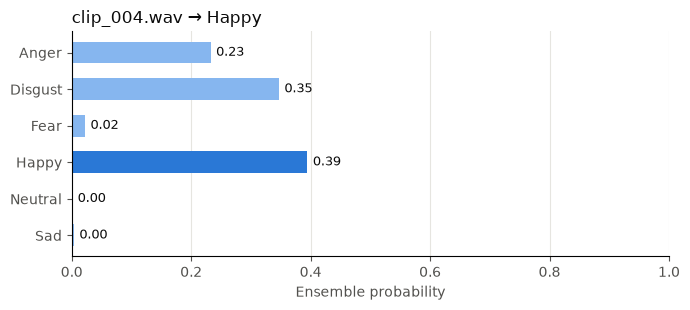

In [262]:
default_audio = DATA_ROOT / U.get_split(U.load_splits(), 'val')['path'].iloc[0]

#AUDIO_PATH = default_audio          # <- e.g. AUDIO_PATH = Path('my_recording.wav')

AUDIO_PATH = Path(r'C:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\classmates_audios\clip_004.wav')

show_prediction(predict_audio_any_length(AUDIO_PATH))

### 25.5 Folder of new audio files (`new_audio/`)

Upload audio files of any length to the **`new_audio/`** folder of the project (`CREMA-D_Grupo/new_audio/`, the same path locally and in Google Drive) and run this cell: every file is classified and a summary table is saved to `results/new_audio_predictions.csv`. Supported formats: `.wav`, `.flac`, `.ogg`, `.mp3` (`.m4a` needs `ffmpeg`, which Colab includes). A file that cannot be processed is reported and skipped.

Long files take longer: a 5-minute recording is about 200 windows, each one classified by the five models (around a minute on a GPU).

5 audio file(s) in c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\emsemble_learning_CREMA-D\CREMA-D_Grupo\new_audio



Audio: 35_horas_del_dia.mp3  |  15.1 s  |  sliding windows  |  10 speech windows of 10

Model M1 → Fear (0.54)
Model M2 → Anger (0.36)
Model M3 → Happy (0.36)
Model M4 → Happy (0.59)
Model M5 → Fear (0.68)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.04
Disgust    0.07
Fear       0.48
Happy      0.27
Neutral    0.09
Sad        0.05

Final prediction: FEAR


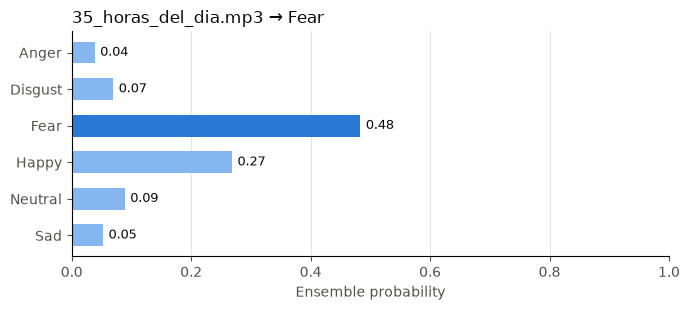

Audio: cuidado_me_vas_a_tocar.mp3  |  9.5 s  |  sliding windows  |  6 speech windows of 6

Model M1 → Fear (0.35)
Model M2 → Anger (0.36)
Model M3 → Happy (0.41)
Model M4 → Disgust (0.54)
Model M5 → Disgust (0.69)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.09
Disgust    0.52
Fear       0.03
Happy      0.29
Neutral    0.03
Sad        0.04

Final prediction: DISGUST


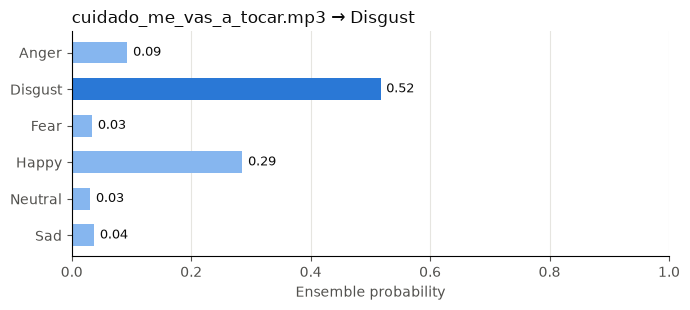

Audio: me_la_saco_jose_delgado.mp3  |  17.3 s  |  sliding windows  |  11 speech windows of 11

Model M1 → Fear (0.51)
Model M2 → Anger (0.80)
Model M3 → Happy (0.44)
Model M4 → Sad (0.33)
Model M5 → Happy (0.37)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.26
Disgust    0.12
Fear       0.14
Happy      0.41
Neutral    0.06
Sad        0.02

Final prediction: HAPPY


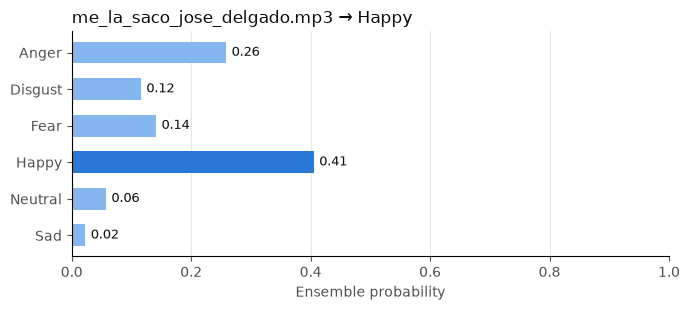

Audio: psicologicamente_quebrada_la_man.mp3  |  6.1 s  |  sliding windows  |  4 speech windows of 4

Model M1 → Fear (0.80)
Model M2 → Anger (0.50)
Model M3 → Disgust (0.30)
Model M4 → Happy (0.46)
Model M5 → Fear (0.57)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.13
Disgust    0.24
Fear       0.42
Happy      0.20
Neutral    0.00
Sad        0.02

Final prediction: FEAR


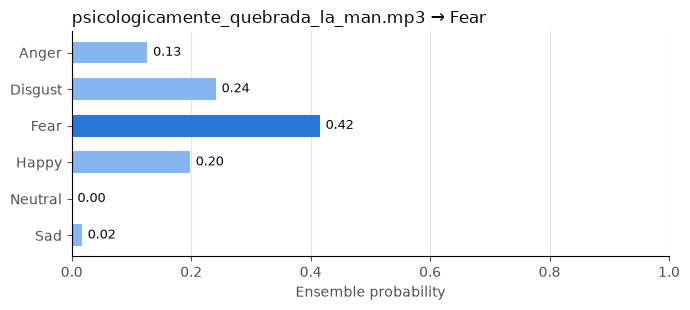

Audio: Si_cultivas_pollos_por_ejemplo.mp3  |  15.0 s  |  sliding windows  |  10 speech windows of 10

Model M1 → Anger (0.34)
Model M2 → Happy (0.35)
Model M3 → Fear (0.51)
Model M4 → Happy (0.52)
Model M5 → Fear (0.68)

Weighted Soft Voting (M3 0.55 + M5 0.45)

Anger      0.16
Disgust    0.03
Fear       0.59
Happy      0.20
Neutral    0.01
Sad        0.01

Final prediction: FEAR


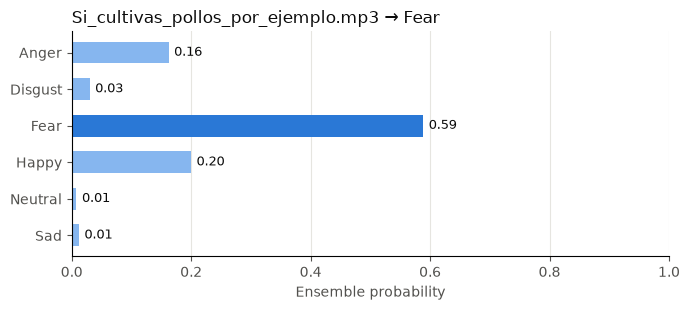

,file,duration_s,mode,speech_windows,final_emotion,confidence
0,35_horas_del_dia.mp3,15.1,sliding windows,10,Fear,0.483
1,cuidado_me_vas_a_tocar.mp3,9.5,sliding windows,6,Disgust,0.517
2,me_la_saco_jose_delgado.mp3,17.3,sliding windows,11,Happy,0.405
3,psicologicamente_quebrada_la_man.mp3,6.1,sliding windows,4,Fear,0.416
4,Si_cultivas_pollos_por_ejemplo.mp3,15.0,sliding windows,10,Fear,0.588


In [263]:
NEW_AUDIO_DIR = PROJECT / 'new_audio'
NEW_AUDIO_DIR.mkdir(exist_ok=True)
SUPPORTED_EXTENSIONS = {'.wav', '.flac', '.ogg', '.mp3', '.m4a'}

audio_files = sorted(p for p in NEW_AUDIO_DIR.iterdir() if p.suffix.lower() in SUPPORTED_EXTENSIONS)
print(f'{len(audio_files)} audio file(s) in {NEW_AUDIO_DIR}')
if not audio_files:
    print('Upload audio files to this folder and run the cell again.')

summary_rows = []
for audio_file in audio_files:
    print('\n' + '=' * 90)
    try:
        result = predict_audio_any_length(audio_file)
    except Exception as error:                     # one bad file must not stop the others
        print(f'{audio_file.name}: could not be processed ({error})')
        continue
    show_prediction(result)
    summary_rows.append({'file': result['name'], 'duration_s': round(result['duration'], 1), 'mode': result['mode'],
                         'speech_windows': len(result['window_starts']),
                         'final_emotion': EMOTION_NAMES[result['final_emotion']],
                         'confidence': round(float(result['final_probs'].max()), 3),
                         **{f'prob_{e}': round(float(p), 3) for e, p in zip(U.CLASSES, result['final_probs'])}})

if summary_rows:
    new_audio_summary = pd.DataFrame(summary_rows)
    new_audio_summary.to_csv(RESULTS_DIR / 'new_audio_predictions.csv', index=False)
    display(new_audio_summary[['file', 'duration_s', 'mode', 'speech_windows', 'final_emotion', 'confidence']])

## 26. Discussion

### 26.1 Audio representation matters more than the classifier
The five models fall into three clear tiers, and the tier depends on how much data shaped the representation, not on the classifier:
|Tier|Models| Validation Macro F1
|------|-------|---------|
|Pretrained speech representations|M5 (Whisper + MLP), M3 (WavLM + Logistic Regression)| 0.783, 0.742|
|Features learned from the spectogram| M4 (Log-Mel +2D CNN)|0.700|
|Hand crafted acoustic descriptors|M1 (MFCC + SVM), M2 (eGeMAPS + Random Forest)|0.558,0,540|

The clearest evidence is the classifier M3, a logistic regression which is the simplest classifier of the five, outperforms the CNN of M4 and the SVM of M1.

The handcrafted models are limited by the information they keep, not the classifiers. M1 reaches only 0.59 Macro F1 even on Train with its best configuration: its 80 statistics discard the temporal order and most of the pitch information. M2 shows a related effect of the speaker-disjoint; its permutation importance indicates that it relies on how the voice changes, which is relative to each speaker, while the formant descriptors, which mostly reflect each speaker vocal-tract anatomy, have a negative total importance. They help to recognize the 63 train actors but not the new ones.

### 26.2 Shared and complementary errors

Arousal is easy, valence and fear are hard. All models separate high and low emotions well.  The hand crafted models confuse HAP with ANG much more than the pretrained ones (0.22 and 0.24 for M1 and M2, against 0.06–0.07 for M3 and M5). FEA is the hardest emotion for every model and all five confuse it with SAD (0.14–0.20 on Validation, 22% for the final ensemble on Test) Because this error is shared, no combination of these models can fix it.

Other errors are present across models. M5, the best model, fails on 252 Validation audios, and at least one of the other four models gest 171 of them right. On SAD, M5's emotion with the most errors (58), the other models recover between 21 and 30 files each.

**Probability correlation alone is misleading.** The flattened correlation is high for every pair simply because every reasonable puts most of its probability on the true clas; the simulation in section 21.1 showed this inflation even for  models with independent errors.

**Diversity alone does not predict the ensemble gain.** Across the 10 pairs, the relation between diversity and the gain over the best member is weak and not significant (Spearman 0.37 with Yule's Q, −0.07 with the residual correlation). The pair with the largest gain is M3 + M4 (+0.040), which combines two strong models with different representations. A useful ensemble member needs both reasonable accuracy and errors that differ from the other members.

### 26.3 What the ensemble experiments showed on validation

Uniform vs. Weighted Soft Voting. Uniform Soft Voting barely improves on M5 (0.789 against 0.783), because the two weakest models together receive 40% of the vote. Weighted Soft Voting reaches 0.813 (+0.030 over M5), with weights M1 0.05, M2 0.10, M3 0.40, M4 0.15 and M5 0.30.

The weights also compensate for calibration. M3 receives more weight than M5 although it is weaker. The calibration check (section 17) explains part of this: M5 is overconfident (average confidence 0.819 against accuracy 0.780), while M3 is underconfident (0.659 against 0.741), so their raw probabilities have different "volumes". M4, calibrated with temperature scaling, is the best calibrated model (0.689 against 0.699). The weight of a model therefore mixes three things: how accurate it is, how calibrated its probabilities are, and how complementary its errors are.

Leave-One-Model-Out. Removing M5 costs 0.026 Macro F1, M3 0.012 and M4 0.006, while removing M1 or M2 costs practically nothing (0.001 and 0.000). M1 and M2 do correct some of M5's errors (85 and 89 files), but giving them weight also breaks correct answers of the strong models, so their net contribution is zero. They are not useless models, but they are redundant next to the learned representations.

The 26 combinations. Every pair beats its best member, but the gains saturate quickly: the best ensemble reaches 0.803 with two models (M3 + M5), 0.812 with three (M3 + M4 + M5) and 0.813 with four or five. In the best 3-model ensemble, M4 receives a weight of 0.35, higher than M5 (0.20), which shows that the weight search rewards a model that brings different information, not only the most accurate one.

### 26.4 Final ensemble and Test results

We froze M3 + M5 (weights 0.55 / 0.45) before using Test. The best 3- and 5-model ensembles scored about one point more on Validation, a difference comparable to the sampling noise of 14 actors, and each additional model is one more pipeline to deploy and maintain. We accepted that cost for production efficiency.

On Test, the frozen ensemble reaches Macro F1 0.758 (accuracy 0.755), 4.4 points below its Validation score. Its members drop less: M3 from 0.742 to 0.713 and M5 from 0.783 to 0.763. On new speakers, the ensemble does not beat M5 alone (0.758 against 0.763, a difference within sampling noise): the 2-point gain observed on Validation did not generalize.

The most likely cause is selection optimism on a small Validation set. The same 14 actors were used for many decisions: M3's layer and regularization (about 64 configurations), M5's regularization, M4's early stopping and temperature, the 26 combinations and, for each of them, thousands of weight options. Each choice keeps what worked best on those actors, partly by chance, and the optimism accumulates in the final system. This is consistent with the per-model drops (M3, which had the largest search, dropped more than M5), and the complementarity between M3 and M5 measured on Validation may partly depend on those specific speakers. The speaker-disjoint split is what made this visible: with a random split, the same actors would appear in all partitions and the optimism would have gone unnoticed. The frozen decision was not changed after seeing Test, because doing so would have turned Test into a second Validation set.

Per emotion on Test, NEU (0.84) and ANG (0.80) are the best recognized, while FEA remains the hardest (0.66), confused with SAD in 22% of cases, and SAD (0.71) is mostly confused with DIS (0.13).

### 26.5 Behaviour on new audio

The system was tested with five Spanish recordings of 6–17 s, processed with 3-second sliding windows (section 25).

Low confidence: the final probabilities of the predicted emotion range from 0.41 to 0.59, far from typical in-domain predictions (for example, 0.93 for the Validation clip in section 25.4).
Strong disagreement between models: the two ensemble members disagree on three of the five files (for example, M3 predicts Happy and M5 Fear for 35_horas_del_dia.mp3), and for me_la_saco_jose_delgado.mp3 the five models predict four different emotions.
A bias toward Fear: three of the five files are classified as Fear.

These recordings differ from CREMA-D in almost every respect: language (Spanish instead of English), spontaneous instead of acted speech, longer utterances that may contain more than one emotion, and different recording conditions. The behaviour is therefore a clear example of domain shift: the system is reliable only for audio similar to its training data.

### 26.6 Limitations

- A single, small Validation set. With 14 actors, differences of one or two points cannot be distinguished from chance, and every decision taken on Validation adds optimism.

- Validation used inside some models. Early stopping, checkpoint selection, layer selection and temperature scaling also used Validation, so the individual Validation scores are slightly optimistic.



## 27. Conclusions

- The audio representation is the decisive factor. Pretrained speech representations (Whisper 0.783, WavLM 0.742 Validation Macro F1) clearly outperform a CNN trained from scratch on Log-Mel spectrograms (0.700) and hand-crafted descriptors (MFCC 0.558, eGeMAPS 0.540), and a simple logistic regression on good embeddings beats more complex classifiers on weaker representations.

- Weighted Soft Voting outperforms Uniform Soft Voting on Validation (0.813 against 0.789). With equal weights, the weak models dilute the ensemble, which barely improves on the best single model (+0.006). The optimized weights reflect not only accuracy but also calibration and complementarity.

- A model's contribution depends on both accuracy and complementarity. Leave-One-Model-Out shows that M5, M3 and M4 contribute, while M1 and M2 are redundant despite correcting some of M5's errors. Models from different representation families make more different errors, but diversity measures alone did not predict which pairs gain the most.

- The gains of ensembling saturate quickly. Three models (M3 + M4 + M5) achieve practically the same Validation score as all five (0.812 against 0.813). For deployment efficiency, the group chose two models (M3 + M5, 0.803).

- Some errors cannot be fixed by combining these models. The confusion between FEA and SAD is shared by all five models and persists on Test; reducing it requires new information, not a different combination.

- The system does not transfer reliably outside its domain. On Spanish, spontaneous recordings, the predictions have low confidence and the models disagree strongly.